# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [98]:
# Your code goes here
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports & Global Config

In [110]:
# Libraries
from pathlib import Path
import os
import random
from typing import Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [111]:
# Base project paths
PROJECT_DIR = Path("/content/drive/MyDrive/Deep Learning Project")
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"

# Dataset-specific paths
NASDAQ_DATA_DIR = RAW_DATA_DIR / "nasdaq"

In [156]:
# Nasdaq selection
# Set PREFERRED_NASDAQ_TICKER to a symbol such as "AMD" only when you intentionally
# want a fixed-company experiment. The default selects the longest-history ticker.
PREFERRED_NASDAQ_TICKER: str | None = None
NASDAQ_SELECTION_STRATEGY = "longest_history"
NASDAQ_TICKER: str | None = None
NASDAQ_TICKER: str | None = None

DATE_COLUMN = "Date"
TARGET_COLUMN = "Adjusted Close"

REQUIRED_PRICE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adjusted Close",
    "Volume",
]

FEATURE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adjusted Close",
    "Volume",
    "Log Return",
    "MA10",
    "MA20",
    "Volatility10",
]

LOOKBACK_DAYS = 30
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
MIN_HISTORY_POINTS = 120

MODEL_TYPE = "gru"
DROPOUT_RATE = 0.3
RECURRENT_DROPOUT_RATE = 0.00
LEARNING_RATE = 3e-4
PATIENCE = 8
BATCH_SIZE = 32
EPOCHS = 40
CV_EPOCHS = 20

K_TH_DAY = 3
K_CONSECUTIVE_DAYS = 3

RANDOM_SEED = 42

In [113]:
def set_global_seed(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def count_csv_files(data_dir: Path) -> int:
    if not data_dir.exists():
        return 0

    return len(list(data_dir.glob("*.csv")))


def print_path_status(label: str, data_path: Path) -> None:
    status = "exists" if data_path.exists() else "missing"
    csv_count = count_csv_files(data_path)
    print(f"{label}: {data_path} [{status}, csv_files={csv_count}]")


set_global_seed(RANDOM_SEED)

## Reusable Functionality

### Check Available Ticker

In [114]:
from pathlib import Path

def list_available_tickers(data_dir: Path, limit: int = 20) -> list[str]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Data directory does not exist: {data_dir}")

    csv_files = sorted(data_dir.glob("*.csv"))
    if limit > 0:
        csv_files = csv_files[:limit]
    return [csv_file.stem.upper() for csv_file in csv_files]

def validate_required_columns(data: pd.DataFrame, required_columns: list[str]) -> None:
    missing_columns = [column for column in required_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

def make_unique_columns(columns: list[str]) -> list[str]:
    return list(dict.fromkeys(columns))

def resolve_price_data_dir(primary_dir: Path, fallback_dir: Path | None = None) -> Path:
    if primary_dir.exists() and any(primary_dir.glob("*.csv")):
        return primary_dir
    if fallback_dir is not None and fallback_dir.exists() and any(fallback_dir.glob("*.csv")):
        return fallback_dir
    return primary_dir

def load_stock_price_data(data_dir: Path, ticker: str, date_column: str = "Date") -> pd.DataFrame:
    ticker = ticker.upper()
    file_path = data_dir / f"{ticker}.csv"
    if not file_path.exists():
        available_tickers = list_available_tickers(data_dir)
        raise FileNotFoundError(f"Missing file: {file_path}. Available examples: {available_tickers[:20]}")
    data = pd.read_csv(file_path)
    validate_required_columns(data, [date_column])
    data[date_column] = pd.to_datetime(data[date_column], errors="coerce")
    data = data.dropna(subset=[date_column])
    data = data.sort_values(date_column).reset_index(drop=True)
    return data

def parse_stock_dates(date_series: pd.Series) -> pd.Series:
    date_text = date_series.astype(str).str.strip()

    if date_text.empty:
        return pd.to_datetime(date_series, errors="coerce")

    first_valid = date_text[date_text.ne("")].iloc[0] if date_text.ne("").any() else ""

    if re.fullmatch(r"\d{4}-\d{1,2}-\d{1,2}", first_valid):
        return pd.to_datetime(date_text, format="%Y-%m-%d", errors="coerce")

    if re.fullmatch(r"\d{1,2}-\d{1,2}-\d{4}", first_valid):
        return pd.to_datetime(date_text, format="%d-%m-%Y", errors="coerce")

    if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{4}", first_valid):
        return pd.to_datetime(date_text, dayfirst=True, errors="coerce")

    return pd.to_datetime(date_series, errors="coerce")

def compute_ticker_quality_metrics(
    data: pd.DataFrame,
    ticker: str,
    date_column: str = "Date",
    close_column: str = "Close",
    adjusted_close_column: str = "Adjusted Close",
    volume_column: str = "Volume",
    spike_threshold: float = 0.08,
) -> dict[str, object]:
    required_columns = [
        date_column,
        close_column,
        adjusted_close_column,
        volume_column,
    ]
    validate_required_columns(data, required_columns)

    quality_data = data[required_columns].copy()
    quality_data[date_column] = parse_stock_dates(quality_data[date_column])

    for column in [close_column, adjusted_close_column, volume_column]:
        quality_data[column] = pd.to_numeric(quality_data[column], errors="coerce")

    quality_data = quality_data.dropna(subset=required_columns)
    quality_data = quality_data.sort_values(date_column).reset_index(drop=True)

    close_return = quality_data[close_column].pct_change(fill_method=None)
    adjusted_return = quality_data[adjusted_close_column].pct_change(fill_method=None)

    close_return = close_return.replace([np.inf, -np.inf], np.nan)
    adjusted_return = adjusted_return.replace([np.inf, -np.inf], np.nan)

    flat_close_rate = quality_data[close_column].diff().eq(0).mean()
    nonzero_volume_rate = quality_data[volume_column].gt(0).mean()
    median_volume = quality_data[volume_column].median()
    median_dollar_volume = (
        quality_data[close_column] * quality_data[volume_column]
    ).median()

    close_return_std = close_return.std()
    close_mean_abs_return = close_return.abs().mean()
    close_spike_rate = (close_return.abs() > spike_threshold).mean()
    close_max_abs_return = close_return.abs().max()

    adjusted_spike_rate = (adjusted_return.abs() > spike_threshold).mean()
    adjusted_max_abs_return = adjusted_return.abs().max()

    stability_score = (
        10.0 * float(close_return_std if pd.notna(close_return_std) else 999)
        + 5.0 * float(close_mean_abs_return if pd.notna(close_mean_abs_return) else 999)
        + 3.0 * float(close_spike_rate if pd.notna(close_spike_rate) else 999)
        + 1.0 * float(close_max_abs_return if pd.notna(close_max_abs_return) else 999)
        + 2.0 * float(flat_close_rate)
        - 0.05 * np.log1p(float(median_dollar_volume if pd.notna(median_dollar_volume) else 0))
    )

    return {
        "Ticker": ticker.upper(),
        "Rows": len(quality_data),
        "Start Date": quality_data[date_column].min(),
        "End Date": quality_data[date_column].max(),
        "Close Return Std": float(close_return_std) if pd.notna(close_return_std) else np.nan,
        "Close Mean Abs Return": float(close_mean_abs_return) if pd.notna(close_mean_abs_return) else np.nan,
        "Close Spike Rate": float(close_spike_rate) if pd.notna(close_spike_rate) else np.nan,
        "Close Max Abs Return": float(close_max_abs_return) if pd.notna(close_max_abs_return) else np.nan,
        "Adjusted Close Spike Rate": float(adjusted_spike_rate) if pd.notna(adjusted_spike_rate) else np.nan,
        "Adjusted Close Max Abs Return": float(adjusted_max_abs_return) if pd.notna(adjusted_max_abs_return) else np.nan,
        "Flat Close Rate": float(flat_close_rate),
        "Nonzero Volume Rate": float(nonzero_volume_rate),
        "Median Volume": float(median_volume),
        "Median Dollar Volume": float(median_dollar_volume),
        "Stability Score": float(stability_score),
        "Spike Threshold": spike_threshold,
    }

def filter_valid_tickers(
    data_dir: Path,
    required_columns: list[str],
    min_history_points: int = 120,
    date_column: str = "Date",
    close_column: str = "Close",
    adjusted_close_column: str = "Adjusted Close",
    volume_column: str = "Volume",
    spike_threshold: float = 0.08,
    max_spike_rate: float = 0.08,
    max_flat_close_rate: float = 0.15,
    min_nonzero_volume_rate: float = 0.90,
    min_median_volume: float = 10_000,
    include_ineligible: bool = False,
) -> pd.DataFrame:
    if not data_dir.exists():
        raise FileNotFoundError(f"Data directory does not exist: {data_dir}")

    ticker_rows = []
    needed_columns = make_unique_columns(
        required_columns
        + [date_column, close_column, adjusted_close_column, volume_column]
    )

    for csv_file in sorted(data_dir.glob("*.csv")):
        ticker = csv_file.stem.upper()

        try:
            sample_data = pd.read_csv(csv_file, nrows=5)
            has_required_columns = all(
                column in sample_data.columns for column in needed_columns
            )

            if not has_required_columns:
                if include_ineligible:
                    ticker_rows.append(
                        {
                            "Ticker": ticker,
                            "Rows": 0,
                            "Eligible": False,
                            "Reason": "Missing required columns",
                        }
                    )
                continue

            data = pd.read_csv(csv_file, usecols=needed_columns)

            metrics = compute_ticker_quality_metrics(
                data=data,
                ticker=ticker,
                date_column=date_column,
                close_column=close_column,
                adjusted_close_column=adjusted_close_column,
                volume_column=volume_column,
                spike_threshold=spike_threshold,
            )

            has_enough_history = metrics["Rows"] >= min_history_points
            has_low_spikes = metrics["Close Spike Rate"] <= max_spike_rate
            has_not_too_many_flat_days = metrics["Flat Close Rate"] <= max_flat_close_rate
            has_nonzero_volume = metrics["Nonzero Volume Rate"] >= min_nonzero_volume_rate
            has_enough_volume = metrics["Median Volume"] >= min_median_volume

            is_eligible = (
                has_enough_history
                and has_low_spikes
                and has_not_too_many_flat_days
                and has_nonzero_volume
                and has_enough_volume
            )

            failed_reasons = []

            if not has_enough_history:
                failed_reasons.append(f"Rows < {min_history_points}")

            if not has_low_spikes:
                failed_reasons.append(f"Close Spike Rate > {max_spike_rate}")

            if not has_not_too_many_flat_days:
                failed_reasons.append(f"Flat Close Rate > {max_flat_close_rate}")

            if not has_nonzero_volume:
                failed_reasons.append(
                    f"Nonzero Volume Rate < {min_nonzero_volume_rate}"
                )

            if not has_enough_volume:
                failed_reasons.append(f"Median Volume < {min_median_volume}")

            metrics["Eligible"] = is_eligible
            metrics["Reason"] = "Eligible" if is_eligible else "; ".join(failed_reasons)

            if include_ineligible or is_eligible:
                ticker_rows.append(metrics)

        except Exception as error:
            if include_ineligible:
                ticker_rows.append(
                    {
                        "Ticker": ticker,
                        "Rows": 0,
                        "Eligible": False,
                        "Reason": str(error),
                    }
                )
            else:
                print(f"Skipping {ticker}: {error}")

    valid_tickers = pd.DataFrame(ticker_rows)

    if valid_tickers.empty:
        return pd.DataFrame(
            columns=[
                "Ticker",
                "Rows",
                "Start Date",
                "End Date",
                "Close Return Std",
                "Close Mean Abs Return",
                "Close Spike Rate",
                "Close Max Abs Return",
                "Adjusted Close Spike Rate",
                "Adjusted Close Max Abs Return",
                "Flat Close Rate",
                "Nonzero Volume Rate",
                "Median Volume",
                "Median Dollar Volume",
                "Stability Score",
                "Eligible",
                "Reason",
            ]
        )

    return valid_tickers.sort_values(
        by=["Eligible", "Stability Score", "Rows", "Ticker"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)

def select_ticker_from_valid_list(valid_tickers: pd.DataFrame, preferred_ticker: str | None = None, selection_strategy: str = "longest_history") -> str:
    eligible = valid_tickers[valid_tickers["Eligible"]].copy()
    if eligible.empty: raise ValueError("No eligible tickers")
    if selection_strategy == "longest_history":
        return str(eligible.sort_values("Rows", ascending=False).iloc[0]["Ticker"])
    return str(eligible.iloc[0]["Ticker"])

def display_ticker_selection_diagnostics(valid_tickers: pd.DataFrame, selected_ticker: str, top_n: int = 20) -> None:
    display(valid_tickers.head(top_n))
    print(f"Selected ticker: {selected_ticker}")

### Feature Engineering

In [115]:
def add_technical_features(
    data: pd.DataFrame,
    target_column: str,
) -> pd.DataFrame:
    featured_data = data.copy()

    featured_data.loc[featured_data[target_column] <= 0, target_column] = np.nan
    featured_data["Log Return"] = np.log(
        featured_data[target_column] / featured_data[target_column].shift(1)
    )
    featured_data["MA10"] = featured_data[target_column].rolling(window=10).mean()
    featured_data["MA20"] = featured_data[target_column].rolling(window=20).mean()
    featured_data["Volatility10"] = featured_data["Log Return"].rolling(window=10).std()

    return featured_data


def prepare_price_features(
    data: pd.DataFrame,
    date_column: str,
    required_price_columns: list[str],
    feature_columns: list[str],
    target_column: str,
    min_history_points: int = 120,
) -> pd.DataFrame:
    validate_required_columns(data, make_unique_columns([date_column] + required_price_columns + [target_column]))

    prepared_data = data.copy()
    prepared_data[date_column] = pd.to_datetime(prepared_data[date_column], errors="coerce")

    numeric_columns = list(dict.fromkeys(required_price_columns + [target_column]))
    for column in numeric_columns:
        prepared_data[column] = pd.to_numeric(prepared_data[column], errors="coerce")

    prepared_data = prepared_data.sort_values(date_column).reset_index(drop=True)
    prepared_data = add_technical_features(prepared_data, target_column=target_column)

    prepared_data = prepared_data.dropna(
        subset=make_unique_columns([date_column] + feature_columns + [target_column])
    ).reset_index(drop=True)

    if len(prepared_data) < min_history_points:
        raise ValueError(
            f"Not enough usable rows after cleaning. "
            f"Need at least {min_history_points}, got {len(prepared_data)}."
        )

    return prepared_data


def plot_stock_series(
    data: pd.DataFrame,
    date_column: str,
    value_column: str,
    title: str,
) -> None:
    plt.figure(figsize=(14, 5))
    plt.plot(data[date_column], data[value_column])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(value_column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_feature_correlation(
    data: pd.DataFrame,
    feature_columns: list[str],
    title: str,
) -> None:
    correlation = data[feature_columns].corr()

    plt.figure(figsize=(9, 7))
    image = plt.imshow(correlation, aspect="auto")
    plt.colorbar(image)
    plt.xticks(range(len(feature_columns)), feature_columns, rotation=90)
    plt.yticks(range(len(feature_columns)), feature_columns)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### Reusable Time-Series Split

In [116]:
def chronological_train_val_test_split(
    data: pd.DataFrame,
    train_ratio: float,
    val_ratio: float,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if not 0 < train_ratio < 1:
        raise ValueError("train_ratio must be between 0 and 1.")

    if not 0 < val_ratio < 1:
        raise ValueError("val_ratio must be between 0 and 1.")

    if train_ratio + val_ratio >= 1:
        raise ValueError("train_ratio + val_ratio must be less than 1.")

    row_count = len(data)
    train_end = int(row_count * train_ratio)
    val_end = int(row_count * (train_ratio + val_ratio))

    train_data = data.iloc[:train_end].copy()
    val_data = data.iloc[train_end:val_end].copy()
    test_data = data.iloc[val_end:].copy()

    return train_data, val_data, test_data


def plot_chronological_split(
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    test_data: pd.DataFrame,
    date_column: str,
    target_column: str,
    title: str,
) -> None:
    plt.figure(figsize=(14, 5))
    plt.plot(train_data[date_column], train_data[target_column], label="Train")
    plt.plot(val_data[date_column], val_data[target_column], label="Validation")
    plt.plot(test_data[date_column], test_data[target_column], label="Test")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(target_column)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Reusable Scaling & Sequence Builder

In [117]:
def fit_train_scalers(
    train_data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
) -> tuple[MinMaxScaler, MinMaxScaler]:
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    feature_scaler.fit(train_data[feature_columns])
    target_scaler.fit(train_data[[target_column]])

    return feature_scaler, target_scaler


def transform_split_with_context(
    previous_data: pd.DataFrame | None,
    current_data: pd.DataFrame,
    lookback_days: int,
    feature_columns: list[str],
    target_column: str,
    feature_scaler: MinMaxScaler,
    target_scaler: MinMaxScaler,
) -> tuple[np.ndarray, np.ndarray]:
    if previous_data is not None and len(previous_data) > 0:
        context_data = previous_data.tail(lookback_days)
        model_data = pd.concat([context_data, current_data], axis=0)
    else:
        model_data = current_data.copy()

    x_scaled = feature_scaler.transform(model_data[feature_columns])
    y_scaled = target_scaler.transform(model_data[[target_column]])

    return x_scaled, y_scaled


def make_forecast_sequences(
    x_scaled: np.ndarray,
    y_scaled: np.ndarray,
    lookback_days: int,
    forecast_horizon: int,
    multi_output: bool,
) -> tuple[np.ndarray, np.ndarray]:
    x_sequences = []
    y_sequences = []

    max_start = len(x_scaled) - lookback_days - forecast_horizon + 1

    if max_start <= 0:
        raise ValueError(
            f"Not enough rows to create sequences. "
            f"Rows={len(x_scaled)}, lookback_days={lookback_days}, "
            f"forecast_horizon={forecast_horizon}."
        )

    for start_index in range(max_start):
        input_end = start_index + lookback_days
        target_start = input_end
        target_end = input_end + forecast_horizon

        x_sequences.append(x_scaled[start_index:input_end])

        if multi_output:
            y_sequences.append(y_scaled[target_start:target_end, 0])
        else:
            y_sequences.append(y_scaled[target_end - 1, 0])

    return np.asarray(x_sequences), np.asarray(y_sequences)


def prepare_train_val_test_sequences(
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    test_data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    lookback_days: int,
    forecast_horizon: int,
    multi_output: bool,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, MinMaxScaler]:
    feature_scaler, target_scaler = fit_train_scalers(
        train_data=train_data,
        feature_columns=feature_columns,
        target_column=target_column,
    )

    x_train_scaled, y_train_scaled = transform_split_with_context(
        previous_data=None,
        current_data=train_data,
        lookback_days=lookback_days,
        feature_columns=feature_columns,
        target_column=target_column,
        feature_scaler=feature_scaler,
        target_scaler=target_scaler,
    )

    x_val_scaled, y_val_scaled = transform_split_with_context(
        previous_data=train_data,
        current_data=val_data,
        lookback_days=lookback_days,
        feature_columns=feature_columns,
        target_column=target_column,
        feature_scaler=feature_scaler,
        target_scaler=target_scaler,
    )

    train_val_data = pd.concat([train_data, val_data], axis=0)

    x_test_scaled, y_test_scaled = transform_split_with_context(
        previous_data=train_val_data,
        current_data=test_data,
        lookback_days=lookback_days,
        feature_columns=feature_columns,
        target_column=target_column,
        feature_scaler=feature_scaler,
        target_scaler=target_scaler,
    )

    x_train, y_train = make_forecast_sequences(
        x_scaled=x_train_scaled,
        y_scaled=y_train_scaled,
        lookback_days=lookback_days,
        forecast_horizon=forecast_horizon,
        multi_output=multi_output,
    )

    x_val, y_val = make_forecast_sequences(
        x_scaled=x_val_scaled,
        y_scaled=y_val_scaled,
        lookback_days=lookback_days,
        forecast_horizon=forecast_horizon,
        multi_output=multi_output,
    )

    x_test, y_test = make_forecast_sequences(
        x_scaled=x_test_scaled,
        y_scaled=y_test_scaled,
        lookback_days=lookback_days,
        forecast_horizon=forecast_horizon,
        multi_output=multi_output,
    )

    return x_train, y_train, x_val, y_val, x_test, y_test, target_scaler

### Reusable Deep Learning Models

**Reason**: GRU is the default because it is faster than LSTM. The earlier LSTM used high dropout, and a pattern where training loss is higher than validation loss can indicate over-regularization because dropout is active during training but inactive during validation.

In [118]:
def build_recurrent_forecaster(
    input_shape: tuple[int, int],
    output_dim: int,
    model_type: Literal["gru", "lstm"] = "gru",
    first_units: int = 48,
    second_units: int = 24,
    dropout_rate: float = 0.20,
    recurrent_dropout_rate: float = 0.00,
    learning_rate: float = 3e-4,
) -> keras.Model:
    recurrent_layer = layers.GRU if model_type == "gru" else layers.LSTM

    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            recurrent_layer(
                first_units,
                return_sequences=True,
                recurrent_dropout=recurrent_dropout_rate,
            ),
            layers.Dropout(dropout_rate),
            recurrent_layer(
                second_units,
                recurrent_dropout=recurrent_dropout_rate,
            ),
            layers.Dropout(dropout_rate),
            layers.Dense(output_dim),
        ],
        name=f"{model_type.upper()}_stock_forecaster",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.Huber(delta=0.5),
        metrics=["mae"],
    )

    return model


def make_training_callbacks(patience: int = 8) -> list[keras.callbacks.Callback]:
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(3, patience // 2),
            min_lr=1e-6,
            verbose=0,
        ),
    ]


def diagnose_regularization_gap(
    history: keras.callbacks.History,
    tolerance_ratio: float = 0.05,
    last_n_epochs: int = 5,
) -> None:
    train_loss = np.array(history.history["loss"][-last_n_epochs:])
    val_loss = np.array(history.history["val_loss"][-last_n_epochs:])

    avg_train_loss = float(train_loss.mean())
    avg_val_loss = float(val_loss.mean())

    print(f"Average recent train loss: {avg_train_loss:.6f}")
    print(f"Average recent validation loss: {avg_val_loss:.6f}")

    if avg_train_loss > avg_val_loss * (1 + tolerance_ratio):
        print(
            "Observation: training loss is higher than validation loss. "
            "This is expected when dropout is active during training but disabled during validation. "
            "If predictions are too smooth, reduce dropout to 0.15–0.20 and keep recurrent_dropout at 0.00."
        )
    elif avg_val_loss > avg_train_loss * (1 + tolerance_ratio):
        print(
            "Observation: validation loss is higher than training loss. "
            "This suggests possible overfitting."
        )
    else:
        print("Observation: training and validation losses are balanced.")

### Reusable Evaluation, Plotting & Experiment Runner

In [119]:
def inverse_transform_1d(values: np.ndarray, target_scaler: MinMaxScaler) -> np.ndarray:
    values_2d = np.asarray(values).reshape(-1, 1)
    return target_scaler.inverse_transform(values_2d).reshape(-1)


def inverse_transform_2d(values: np.ndarray, target_scaler: MinMaxScaler) -> np.ndarray:
    values_array = np.asarray(values)

    if values_array.ndim != 2:
        raise ValueError("Expected a 2D array for multi-output inverse transform.")

    row_count, horizon = values_array.shape
    flat_values = values_array.reshape(-1, 1)
    inverse_values = target_scaler.inverse_transform(flat_values)

    return inverse_values.reshape(row_count, horizon)


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return float(
        np.mean(
            np.abs(y_true - y_pred) / np.clip(denominator, 1e-8, None)
        )
        * 100
    )


def directional_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    true_diff = np.diff(np.asarray(y_true).reshape(-1))
    pred_diff = np.diff(np.asarray(y_pred).reshape(-1))

    if len(true_diff) == 0:
        return np.nan

    return float(np.mean(np.sign(true_diff) == np.sign(pred_diff)) * 100)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true_flat = np.asarray(y_true).reshape(-1)
    y_pred_flat = np.asarray(y_pred).reshape(-1)

    mse = mean_squared_error(y_true_flat, y_pred_flat)

    return {
        "MAE": mean_absolute_error(y_true_flat, y_pred_flat),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAPE": np.mean(
            np.abs(
                (y_true_flat - y_pred_flat)
                / np.clip(np.abs(y_true_flat), 1e-8, None)
            )
        )
        * 100,
        "sMAPE": smape(y_true_flat, y_pred_flat),
        "R2": r2_score(y_true_flat, y_pred_flat),
        "Directional Accuracy": directional_accuracy(y_true_flat, y_pred_flat),
    }


def display_metrics(metrics: dict[str, float], title: str) -> None:
    print(title)

    for metric_name, metric_value in metrics.items():
        if "MAPE" in metric_name or "Accuracy" in metric_name:
            print(f"{metric_name}: {metric_value:.2f}%")
        else:
            print(f"{metric_name}: {metric_value:.4f}")


def plot_training_history(history: keras.callbacks.History, title: str) -> None:
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_single_step_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    max_points: int = 200,
) -> None:
    points = min(len(y_true), max_points)

    plt.figure(figsize=(14, 5))
    plt.plot(y_true[:points], label="Actual")
    plt.plot(y_pred[:points], label="Predicted")
    plt.title(title)
    plt.xlabel("Test Sequence")
    plt.ylabel(TARGET_COLUMN)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_multi_step_example(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    sample_index: int = 0,
) -> None:
    horizon = y_true.shape[1]
    forecast_days = np.arange(1, horizon + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(forecast_days, y_true[sample_index], marker="o", label="Actual")
    plt.plot(forecast_days, y_pred[sample_index], marker="o", label="Predicted")
    plt.title(title)
    plt.xlabel("Days Ahead")
    plt.ylabel(TARGET_COLUMN)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_recurrent_forecast_experiment(
    experiment_name: str,
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    test_data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    lookback_days: int,
    forecast_horizon: int,
    multi_output: bool,
    model_type: Literal["gru", "lstm"] = "gru",
    epochs: int = 100,
    batch_size: int = 32,
    patience: int = 10,
    dropout_rate: float = 0.10,
    recurrent_dropout_rate: float = 0.00,
    learning_rate: float = 5e-4,
) -> dict[str, object]:
    tf.keras.backend.clear_session()

    output_dim = forecast_horizon if multi_output else 1

    (
        x_train,
        y_train,
        x_val,
        y_val,
        x_test,
        y_test,
        target_scaler,
    ) = prepare_train_val_test_sequences(
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        feature_columns=feature_columns,
        target_column=target_column,
        lookback_days=lookback_days,
        forecast_horizon=forecast_horizon,
        multi_output=multi_output,
    )

    model = build_recurrent_forecaster(
        input_shape=(lookback_days, len(feature_columns)),
        output_dim=output_dim,
        model_type=model_type,
        dropout_rate=dropout_rate,
        recurrent_dropout_rate=recurrent_dropout_rate,
        learning_rate=learning_rate,
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=make_training_callbacks(patience=patience),
        verbose=1,
        shuffle=False,
    )

    diagnose_regularization_gap(history)

    y_pred_scaled = model.predict(x_test, verbose=0)

    if multi_output:
        y_true = inverse_transform_2d(y_test, target_scaler)
        y_pred = inverse_transform_2d(y_pred_scaled, target_scaler)
    else:
        y_true = inverse_transform_1d(y_test, target_scaler)
        y_pred = inverse_transform_1d(y_pred_scaled, target_scaler)

    metrics = regression_metrics(y_true, y_pred)

    display_metrics(metrics, title=f"\n{experiment_name} Metrics")
    plot_training_history(history, title=f"{experiment_name} Training History")

    if multi_output:
        plot_multi_step_example(
            y_true=y_true,
            y_pred=y_pred,
            title=f"{experiment_name}: Example {forecast_horizon}-Day Forecast",
        )
    else:
        plot_single_step_predictions(
            y_true=y_true,
            y_pred=y_pred,
            title=f"{experiment_name}: Actual vs Predicted",
        )

    return {
        "experiment_name": experiment_name,
        "model_type": model_type,
        "model": model,
        "history": history,
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [120]:
def plot_roc_and_pr_curves(
    y_true: "np.ndarray",
    y_probability: "np.ndarray",
    best_threshold: float,
    title: str,
) -> None:
    """
    Plots ROC curve and Precision-Recall curve side-by-side.
    These are more informative than a single AUC number for imbalanced data.
    The PR curve is especially important for trading signals where
    positive class (buy/sell) is rare.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import (
        roc_curve, auc,
        precision_recall_curve, average_precision_score,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_probability)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (0.50)")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{title}\nROC Curve")
    axes[0].legend()

    # --- Precision-Recall Curve ---
    precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_true, y_probability)
    ap = average_precision_score(y_true, y_probability)
    axes[1].plot(recall_vals, precision_vals, label=f"PR AUC = {ap:.3f}")

    # Mark the chosen threshold on the PR curve
    idx = np.argmin(np.abs(thresholds_pr - best_threshold))
    axes[1].scatter(
        recall_vals[idx], precision_vals[idx],
        color="red", zorder=5,
        label=f"Threshold = {best_threshold:.2f}",
    )
    baseline_positive_rate = float(y_true.mean())
    axes[1].axhline(baseline_positive_rate, color="k", linestyle="--", alpha=0.4,
                    label=f"No-skill baseline ({baseline_positive_rate:.2f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title}\nPrecision-Recall Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### Reusable Time-Series Cross-Validation

In [121]:
def run_time_series_cross_validation(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    lookback_days: int,
    forecast_horizon: int,
    multi_output: bool,
    n_splits: int = 3,
    epochs: int = 20,
    batch_size: int = 32,
    patience: int = 5,
    model_type: Literal["gru", "lstm"] = "gru",
    dropout_rate: float = 0.10,
    recurrent_dropout_rate: float = 0.00,
    learning_rate: float = 5e-4,
) -> pd.DataFrame:
    splitter = TimeSeriesSplit(n_splits=n_splits)
    fold_results = []

    for fold_index, (train_index, val_index) in enumerate(splitter.split(data), start=1):
        fold_train_data = data.iloc[train_index].copy()
        fold_val_data = data.iloc[val_index].copy()

        if len(fold_train_data) <= lookback_days + forecast_horizon:
            continue

        feature_scaler, target_scaler = fit_train_scalers(
            train_data=fold_train_data,
            feature_columns=feature_columns,
            target_column=target_column,
        )

        x_train_scaled, y_train_scaled = transform_split_with_context(
            previous_data=None,
            current_data=fold_train_data,
            lookback_days=lookback_days,
            feature_columns=feature_columns,
            target_column=target_column,
            feature_scaler=feature_scaler,
            target_scaler=target_scaler,
        )

        x_val_scaled, y_val_scaled = transform_split_with_context(
            previous_data=fold_train_data,
            current_data=fold_val_data,
            lookback_days=lookback_days,
            feature_columns=feature_columns,
            target_column=target_column,
            feature_scaler=feature_scaler,
            target_scaler=target_scaler,
        )

        x_train, y_train = make_forecast_sequences(
            x_scaled=x_train_scaled,
            y_scaled=y_train_scaled,
            lookback_days=lookback_days,
            forecast_horizon=forecast_horizon,
            multi_output=multi_output,
        )

        x_val, y_val = make_forecast_sequences(
            x_scaled=x_val_scaled,
            y_scaled=y_val_scaled,
            lookback_days=lookback_days,
            forecast_horizon=forecast_horizon,
            multi_output=multi_output,
        )

        tf.keras.backend.clear_session()
        output_dim = forecast_horizon if multi_output else 1

        model = build_recurrent_forecaster(
            input_shape=(lookback_days, len(feature_columns)),
            output_dim=output_dim,
            model_type=model_type,
            dropout_rate=dropout_rate,
            recurrent_dropout_rate=recurrent_dropout_rate,
            learning_rate=learning_rate,
        )

        model.fit(
            x_train,
            y_train,
            validation_data=(x_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=make_training_callbacks(patience=patience),
            verbose=0,
            shuffle=False,
        )

        y_pred_scaled = model.predict(x_val, verbose=0)

        if multi_output:
            y_true = inverse_transform_2d(y_val, target_scaler)
            y_pred = inverse_transform_2d(y_pred_scaled, target_scaler)
        else:
            y_true = inverse_transform_1d(y_val, target_scaler)
            y_pred = inverse_transform_1d(y_pred_scaled, target_scaler)

        fold_metrics = regression_metrics(y_true, y_pred)
        fold_metrics["Fold"] = fold_index
        fold_metrics["Train Rows"] = len(fold_train_data)
        fold_metrics["Validation Rows"] = len(fold_val_data)
        fold_results.append(fold_metrics)

    results = pd.DataFrame(fold_results)

    if results.empty:
        return pd.DataFrame()

    ordered_columns = ["Fold", "Train Rows", "Validation Rows"] + [
        column
        for column in results.columns
        if column not in ["Fold", "Train Rows", "Validation Rows"]
    ]

    return results[ordered_columns]

### Naive Model for Baseline Comparison

In [122]:
def compute_naive_baselines(
    y_true: "np.ndarray",
    last_known_price: float,
) -> "pd.DataFrame":
    """
    Compares three trivial forecasts against the GRU:
      - Persistent: predict next = last known price (random-walk)
      - Zero-return: predict price stays flat (same as persistent)
      - Mean: predict the mean of the test true values

    All three are "dumb" baselines the GRU must outperform to be useful.
    """
    import numpy as np
    import pandas as pd
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    y_true_flat = np.asarray(y_true).reshape(-1)
    n = len(y_true_flat)

    # Persistent baseline: y_pred[i] = y_true[i-1]; first = last_known_price
    persistent_pred = np.concatenate([[last_known_price], y_true_flat[:-1]])

    # Mean baseline: always predict the training mean (approximated by test mean)
    mean_pred = np.full(n, y_true_flat.mean())

    rows = []
    for label, y_pred in [("Persistent (naive)", persistent_pred), ("Mean baseline", mean_pred)]:
        mse = mean_squared_error(y_true_flat, y_pred)
        da_true_diff = np.diff(y_true_flat)
        da_pred_diff = np.diff(y_pred)
        da = float(np.mean(np.sign(da_true_diff) == np.sign(da_pred_diff)) * 100) if len(da_true_diff) > 0 else float("nan")
        denom = (np.abs(y_true_flat) + np.abs(y_pred)) / 2
        smape = float(np.mean(np.abs(y_true_flat - y_pred) / np.clip(denom, 1e-8, None)) * 100)

        rows.append({
            "Model": label,
            "MAE": mean_absolute_error(y_true_flat, y_pred),
            "RMSE": float(np.sqrt(mse)),
            "sMAPE (%)": smape,
            "R2": r2_score(y_true_flat, y_pred),
            "Directional Accuracy (%)": da,
        })

    return pd.DataFrame(rows)


def compare_gru_vs_baselines(
    experiment_results: dict,
    last_known_price: float,
    experiment_label: str,
) -> None:
    """
    Call this right after run_recurrent_forecast_experiment.
    Pass the last price from val_data as last_known_price.

    Example:
        compare_gru_vs_baselines(
            experiment_results=task_1_1_results,
            last_known_price=float(nasdaq_val_df[TARGET_COLUMN].iloc[-1]),
            experiment_label="Task 1.1 Nasdaq",
        )
    """
    import pandas as pd

    y_true = experiment_results["y_true"].reshape(-1)
    y_pred = experiment_results["y_pred"].reshape(-1)

    gru_metrics = experiment_results["metrics"]
    mse_gru = gru_metrics["MSE"]

    import numpy as np
    from sklearn.metrics import mean_absolute_error, r2_score
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_gru = float(np.mean(np.abs(y_true - y_pred) / np.clip(denom, 1e-8, None)) * 100)

    gru_row = {
        "Model": "GRU (your model)",
        "MAE": gru_metrics["MAE"],
        "RMSE": gru_metrics["RMSE"],
        "sMAPE (%)": smape_gru,
        "R2": gru_metrics["R2"],
        "Directional Accuracy (%)": gru_metrics["Directional Accuracy"],
    }

    baseline_df = compute_naive_baselines(y_true, last_known_price)
    comparison = pd.concat([pd.DataFrame([gru_row]), baseline_df], ignore_index=True)

    print(f"\n{'='*60}")
    print(f"  {experiment_label} — GRU vs Naive Baselines")
    print(f"{'='*60}")
    display(comparison)

    gru_da = gru_metrics["Directional Accuracy"]
    persistent_da = float(comparison[comparison["Model"] == "Persistent (naive)"]["Directional Accuracy (%)"].iloc[0])
    gru_smape = smape_gru
    persistent_smape = float(comparison[comparison["Model"] == "Persistent (naive)"]["sMAPE (%)"].iloc[0])

    print("\nInterpretation:")
    if gru_da > persistent_da:
        print(f"  ✓ GRU Directional Accuracy ({gru_da:.1f}%) BEATS persistent baseline ({persistent_da:.1f}%) — model is learning real signal.")
    else:
        print(f"  ✗ GRU Directional Accuracy ({gru_da:.1f}%) does NOT beat persistent ({persistent_da:.1f}%) — try larger lookback or more epochs.")
    if gru_smape < persistent_smape:
        print(f"  ✓ GRU sMAPE ({gru_smape:.2f}%) BETTER than persistent ({persistent_smape:.2f}%).")
    else:
        print(f"  ✗ GRU sMAPE ({gru_smape:.2f}%) worse than persistent ({persistent_smape:.2f}%). Check for data leakage or scaling issues.")
    print()

## Task 1: Nasdaq stock price prediction

### Task 1.1: Nasdaq multi-feature extension

In [123]:
import re

# Debug run: keep skipped/ineligible rows visible
nasdaq_valid_tickers_debug = filter_valid_tickers(
    data_dir=NASDAQ_DATA_DIR,
    required_columns=[DATE_COLUMN] + REQUIRED_PRICE_COLUMNS,
    min_history_points=MIN_HISTORY_POINTS,
    date_column=DATE_COLUMN,
    close_column="Close",
    adjusted_close_column="Adjusted Close",
    volume_column="Volume",
    spike_threshold=0.08,
    include_ineligible=True,
)

print("Nasdaq filtering reason counts:")
display(nasdaq_valid_tickers_debug["Reason"].value_counts())

display(nasdaq_valid_tickers_debug.head(30))

nasdaq_valid_tickers = nasdaq_valid_tickers_debug[
    nasdaq_valid_tickers_debug["Eligible"]
].copy().reset_index(drop=True)

if nasdaq_valid_tickers.empty:
    raise ValueError(
        "No eligible Nasdaq tickers after filtering. "
        "Check reason counts above and relax filtering thresholds if needed."
    )

NASDAQ_TICKER = select_ticker_from_valid_list(
    valid_tickers=nasdaq_valid_tickers,
    preferred_ticker=PREFERRED_NASDAQ_TICKER,
    selection_strategy=NASDAQ_SELECTION_STRATEGY,
)

display_ticker_selection_diagnostics(
    valid_tickers=nasdaq_valid_tickers,
    selected_ticker=NASDAQ_TICKER,
    top_n=20,
)

nasdaq_raw_df = load_stock_price_data(
    data_dir=NASDAQ_DATA_DIR,
    ticker=NASDAQ_TICKER,
    date_column=DATE_COLUMN,
)

nasdaq_df = prepare_price_features(
    data=nasdaq_raw_df,
    date_column=DATE_COLUMN,
    required_price_columns=REQUIRED_PRICE_COLUMNS,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    min_history_points=MIN_HISTORY_POINTS,
)

nasdaq_preview_columns = make_unique_columns(
    [DATE_COLUMN] + FEATURE_COLUMNS + [TARGET_COLUMN]
)

print(f"{NASDAQ_TICKER} prepared shape:", nasdaq_df.shape)
display(nasdaq_df[nasdaq_preview_columns].head())
display(nasdaq_df[nasdaq_preview_columns].tail())

Nasdaq filtering reason counts:


,count
Reason,
Eligible,452
Flat Close Rate > 0.15; Nonzero Volume Rate < 0.9; Median Volume < 10000,90
Flat Close Rate > 0.15,63
Close Spike Rate > 0.08,45
Close Spike Rate > 0.08; Flat Close Rate > 0.15; Nonzero Volume Rate < 0.9; Median Volume < 10000,33
Flat Close Rate > 0.15; Nonzero Volume Rate < 0.9,23
Flat Close Rate > 0.15; Median Volume < 10000,21
Close Spike Rate > 0.08; Flat Close Rate > 0.15,21
Close Spike Rate > 0.08; Flat Close Rate > 0.15; Median Volume < 10000,21


,Ticker,Rows,Start Date,End Date,Close Return Std,Close Mean Abs Return,Close Spike Rate,Close Max Abs Return,Adjusted Close Spike Rate,Adjusted Close Max Abs Return,Flat Close Rate,Nonzero Volume Rate,Median Volume,Median Dollar Volume,Stability Score,Spike Threshold,Eligible,Reason
0,CHTR,3258,2010-01-05,2022-12-12,0.017904,0.012326,0.003683,0.143288,0.003683,0.143288,0.018723,0.994475,973550.0,3.074073e+08,-0.544732,0.08,True,Eligible
1,CBOE,3147,2010-06-15,2022-12-12,0.016059,0.011239,0.002224,0.143325,0.002224,0.143325,0.006991,1.000000,604400.0,4.589103e+07,-0.501326,0.08,True,Eligible
2,CDW,2383,2013-06-27,2022-12-12,0.017998,0.012321,0.004616,0.141461,0.004616,0.141461,0.007134,1.000000,749200.0,6.071157e+07,-0.484924,0.08,True,Eligible
3,CME,5039,2002-12-06,2022-12-12,0.021807,0.014047,0.010716,0.197995,0.010716,0.197995,0.003771,1.000000,1908300.0,1.957354e+08,-0.428624,0.08,True,Eligible
4,MSFT,9264,1986-03-13,2022-12-12,0.021363,0.014717,0.006693,0.301159,0.006585,0.301159,0.022668,1.000000,51468600.0,1.383270e+09,-0.398595,0.08,True,Eligible
5,VOD,8595,1988-11-02,2022-12-12,0.020886,0.014572,0.007446,0.154015,0.007213,0.154015,0.028156,1.000000,2919763.0,6.797513e+07,-0.387350,0.08,True,Eligible
6,WBA,10778,1980-03-17,2022-12-12,0.018142,0.012830,0.003062,0.166355,0.003155,0.166355,0.050288,1.000000,2790500.0,7.719010e+07,-0.386406,0.08,True,Eligible
7,MAR,6224,1998-03-23,2022-12-12,0.022074,0.015081,0.006909,0.210526,0.006909,0.210526,0.008837,1.000000,2269300.0,1.082170e+08,-0.379909,0.08,True,Eligible
8,AMX,5494,2001-02-12,2022-12-12,0.021479,0.015244,0.006189,0.195975,0.006189,0.195975,0.013469,1.000000,5308500.0,6.948275e+07,-0.370338,0.08,True,Eligible
9,CHRW,6331,1997-10-16,2022-12-12,0.020531,0.013805,0.007424,0.215722,0.007424,0.215722,0.012952,1.000000,1111400.0,6.910208e+07,-0.364322,0.08,True,Eligible


,Ticker,Rows,Start Date,End Date,Close Return Std,Close Mean Abs Return,Close Spike Rate,Close Max Abs Return,Adjusted Close Spike Rate,Adjusted Close Max Abs Return,Flat Close Rate,Nonzero Volume Rate,Median Volume,Median Dollar Volume,Stability Score,Spike Threshold,Eligible,Reason
0,CHTR,3258,2010-01-05,2022-12-12,0.017904,0.012326,0.003683,0.143288,0.003683,0.143288,0.018723,0.994475,973550.0,3.074073e+08,-0.544732,0.08,True,Eligible
1,CBOE,3147,2010-06-15,2022-12-12,0.016059,0.011239,0.002224,0.143325,0.002224,0.143325,0.006991,1.000000,604400.0,4.589103e+07,-0.501326,0.08,True,Eligible
2,CDW,2383,2013-06-27,2022-12-12,0.017998,0.012321,0.004616,0.141461,0.004616,0.141461,0.007134,1.000000,749200.0,6.071157e+07,-0.484924,0.08,True,Eligible
3,CME,5039,2002-12-06,2022-12-12,0.021807,0.014047,0.010716,0.197995,0.010716,0.197995,0.003771,1.000000,1908300.0,1.957354e+08,-0.428624,0.08,True,Eligible
4,MSFT,9264,1986-03-13,2022-12-12,0.021363,0.014717,0.006693,0.301159,0.006585,0.301159,0.022668,1.000000,51468600.0,1.383270e+09,-0.398595,0.08,True,Eligible
5,VOD,8595,1988-11-02,2022-12-12,0.020886,0.014572,0.007446,0.154015,0.007213,0.154015,0.028156,1.000000,2919763.0,6.797513e+07,-0.387350,0.08,True,Eligible
6,WBA,10778,1980-03-17,2022-12-12,0.018142,0.012830,0.003062,0.166355,0.003155,0.166355,0.050288,1.000000,2790500.0,7.719010e+07,-0.386406,0.08,True,Eligible
7,MAR,6224,1998-03-23,2022-12-12,0.022074,0.015081,0.006909,0.210526,0.006909,0.210526,0.008837,1.000000,2269300.0,1.082170e+08,-0.379909,0.08,True,Eligible
8,AMX,5494,2001-02-12,2022-12-12,0.021479,0.015244,0.006189,0.195975,0.006189,0.195975,0.013469,1.000000,5308500.0,6.948275e+07,-0.370338,0.08,True,Eligible
9,CHRW,6331,1997-10-16,2022-12-12,0.020531,0.013805,0.007424,0.215722,0.007424,0.215722,0.012952,1.000000,1111400.0,6.910208e+07,-0.364322,0.08,True,Eligible


Selected ticker: GT
GT prepared shape: (5252, 11)


,Date,Open,High,Low,Close,Adjusted Close,Volume,Log Return,MA10,MA20,Volatility10
0,1970-03-04,13.5625,13.6875,13.375,13.6875,2.979624,67400,-0.040275,2.997948,2.977603,0.067224
1,1970-03-06,12.3750,12.6875,12.125,12.5000,2.746007,131000,-0.081649,2.977307,2.966602,0.071571
2,1970-03-08,12.6250,12.8125,12.625,12.6875,2.787198,19800,0.014889,2.984172,2.979430,0.066647
3,1970-03-09,13.5000,13.8125,13.500,13.6875,3.031835,74400,0.084131,3.005889,2.998527,0.070991
4,1970-03-11,13.6250,13.8750,13.625,13.8750,3.073370,35400,0.013606,3.018349,3.011462,0.069727


,Date,Open,High,Low,Close,Adjusted Close,Volume,Log Return,MA10,MA20,Volatility10
5247,2022-12-07,10.72,11.240,10.700,10.950,10.950,3488200,-0.021681,13.0310,13.78750,0.328486
5248,2022-12-08,14.66,15.200,14.460,15.190,15.190,6520700,0.327298,13.2370,13.46000,0.346258
5249,2022-12-09,14.20,14.470,14.020,14.340,14.340,3102800,-0.057584,13.5450,13.52450,0.342384
5250,2022-12-10,11.06,11.270,10.870,11.080,11.080,2951400,-0.257911,13.5800,13.49150,0.353550
5251,2022-12-12,10.51,10.615,10.485,10.595,10.595,640687,-0.044759,13.1875,13.41025,0.337582


In [124]:
# Most suitable ticker and strategy
NASDAQ_TICKER = select_ticker_from_valid_list(
    valid_tickers=nasdaq_valid_tickers,
    preferred_ticker=PREFERRED_NASDAQ_TICKER,
    selection_strategy=NASDAQ_SELECTION_STRATEGY,
)

selected_ticker_rows = int(
    nasdaq_valid_tickers.loc[
        nasdaq_valid_tickers["Ticker"].astype(str).str.upper() == NASDAQ_TICKER,
        "Rows",
    ].iloc[0]
)

print(f"Selected Nasdaq ticker: {NASDAQ_TICKER}")
print(f"Selection strategy: {NASDAQ_SELECTION_STRATEGY}")
print(f"Historical rows before feature engineering: {selected_ticker_rows}")

Selected Nasdaq ticker: GT
Selection strategy: longest_history
Historical rows before feature engineering: 13356


In [125]:
# Preview of dataset
nasdaq_raw_df = load_stock_price_data(
    data_dir=NASDAQ_DATA_DIR,
    ticker=NASDAQ_TICKER,
    date_column=DATE_COLUMN,
)

nasdaq_df = prepare_price_features(
    data=nasdaq_raw_df,
    date_column=DATE_COLUMN,
    required_price_columns=REQUIRED_PRICE_COLUMNS,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    min_history_points=MIN_HISTORY_POINTS,
)

nasdaq_preview_columns = make_unique_columns([DATE_COLUMN] + FEATURE_COLUMNS + [TARGET_COLUMN])

print(f"{NASDAQ_TICKER} prepared shape:", nasdaq_df.shape)
display(nasdaq_df[nasdaq_preview_columns].head())
display(nasdaq_df[nasdaq_preview_columns].tail())

GT prepared shape: (5252, 11)


,Date,Open,High,Low,Close,Adjusted Close,Volume,Log Return,MA10,MA20,Volatility10
0,1970-03-04,13.5625,13.6875,13.375,13.6875,2.979624,67400,-0.040275,2.997948,2.977603,0.067224
1,1970-03-06,12.3750,12.6875,12.125,12.5000,2.746007,131000,-0.081649,2.977307,2.966602,0.071571
2,1970-03-08,12.6250,12.8125,12.625,12.6875,2.787198,19800,0.014889,2.984172,2.979430,0.066647
3,1970-03-09,13.5000,13.8125,13.500,13.6875,3.031835,74400,0.084131,3.005889,2.998527,0.070991
4,1970-03-11,13.6250,13.8750,13.625,13.8750,3.073370,35400,0.013606,3.018349,3.011462,0.069727


,Date,Open,High,Low,Close,Adjusted Close,Volume,Log Return,MA10,MA20,Volatility10
5247,2022-12-07,10.72,11.240,10.700,10.950,10.950,3488200,-0.021681,13.0310,13.78750,0.328486
5248,2022-12-08,14.66,15.200,14.460,15.190,15.190,6520700,0.327298,13.2370,13.46000,0.346258
5249,2022-12-09,14.20,14.470,14.020,14.340,14.340,3102800,-0.057584,13.5450,13.52450,0.342384
5250,2022-12-10,11.06,11.270,10.870,11.080,11.080,2951400,-0.257911,13.5800,13.49150,0.353550
5251,2022-12-12,10.51,10.615,10.485,10.595,10.595,640687,-0.044759,13.1875,13.41025,0.337582


Missing values after cleaning:


,0
Open,0
High,0
Low,0
Close,0
Adjusted Close,0
Volume,0
Log Return,0
MA10,0
MA20,0
Volatility10,0


Feature summary:


,Open,High,Low,Close,Adjusted Close,Volume,Log Return,MA10,MA20,Volatility10
count,5252.000000,5252.000000,5252.000000,5252.000000,5252.000000,5.252000e+03,5252.000000,5252.000000,5252.000000,5252.000000
mean,21.057249,21.333563,20.757168,21.048319,15.058597,1.940235e+06,0.000234,15.050342,15.040350,0.173120
std,13.633066,13.752752,13.480549,13.619748,11.403827,2.513593e+06,0.202104,11.088000,11.062938,0.120826
min,3.350000,3.650000,3.170000,3.510000,1.580391,1.020000e+04,-1.221380,1.891577,1.911268,0.023813
25%,11.187500,11.407500,11.000000,11.215000,5.402308,2.869500e+05,-0.072348,5.522921,5.512326,0.091236
50%,15.770000,15.995000,15.562500,15.750000,12.514016,8.427000e+05,0.003268,12.865916,12.831318,0.135479
75%,27.822500,28.190001,27.424375,27.832500,22.443251,2.975000e+06,0.076830,22.256050,22.250128,0.206527
max,75.687500,76.125000,74.250000,74.750000,56.041016,5.666200e+07,1.634736,48.708347,47.825953,0.872444


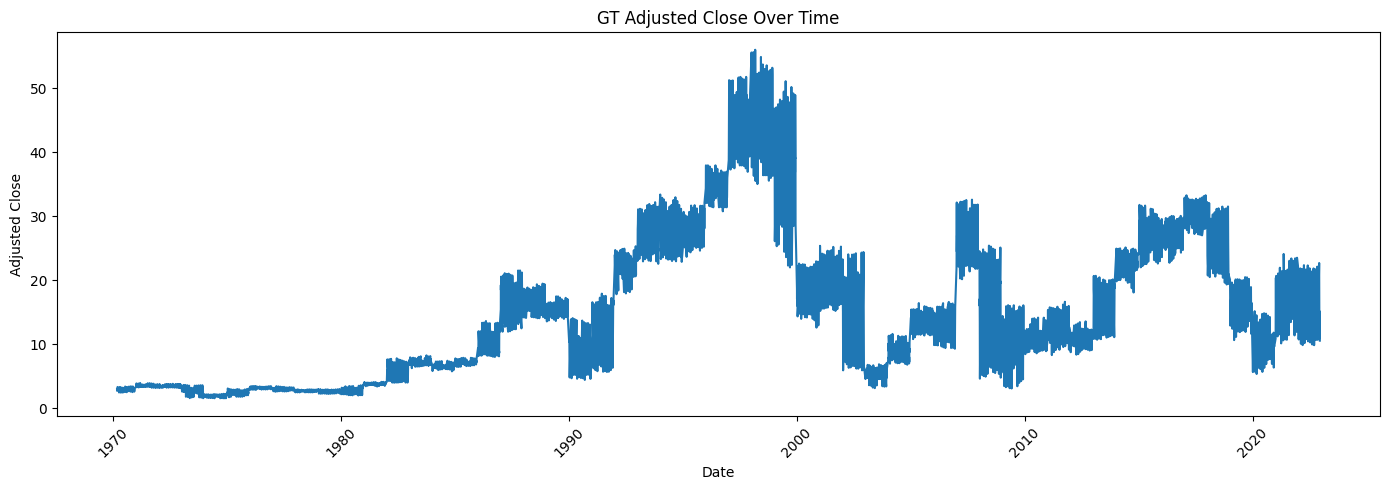

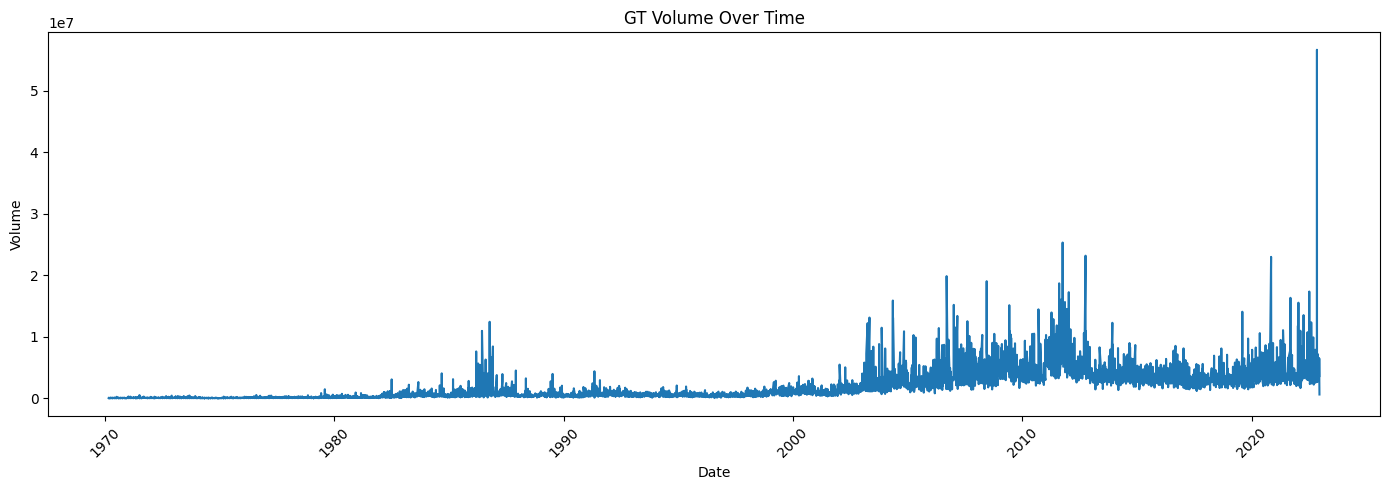

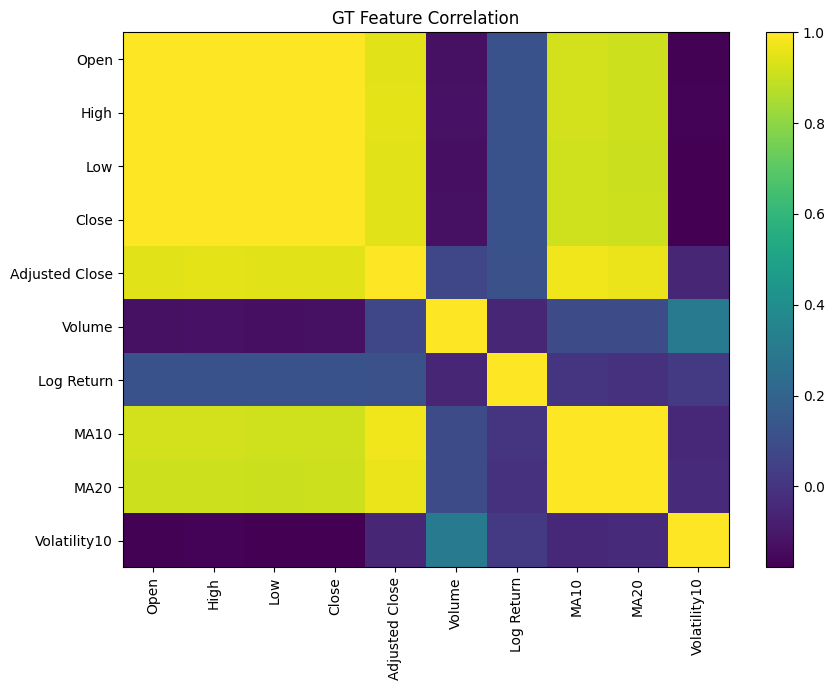

In [126]:
# Data processing
print("Missing values after cleaning:")
display(nasdaq_df[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().sum())

print("Feature summary:")
display(nasdaq_df[FEATURE_COLUMNS].describe())

plot_stock_series(
    data=nasdaq_df,
    date_column=DATE_COLUMN,
    value_column=TARGET_COLUMN,
    title=f"{NASDAQ_TICKER} {TARGET_COLUMN} Over Time",
)

plot_stock_series(
    data=nasdaq_df,
    date_column=DATE_COLUMN,
    value_column="Volume",
    title=f"{NASDAQ_TICKER} Volume Over Time",
)

plot_feature_correlation(
    data=nasdaq_df,
    feature_columns=FEATURE_COLUMNS,
    title=f"{NASDAQ_TICKER} Feature Correlation",
)

Train shape: (3676, 11)
Validation shape: (788, 11)
Test shape: (788, 11)


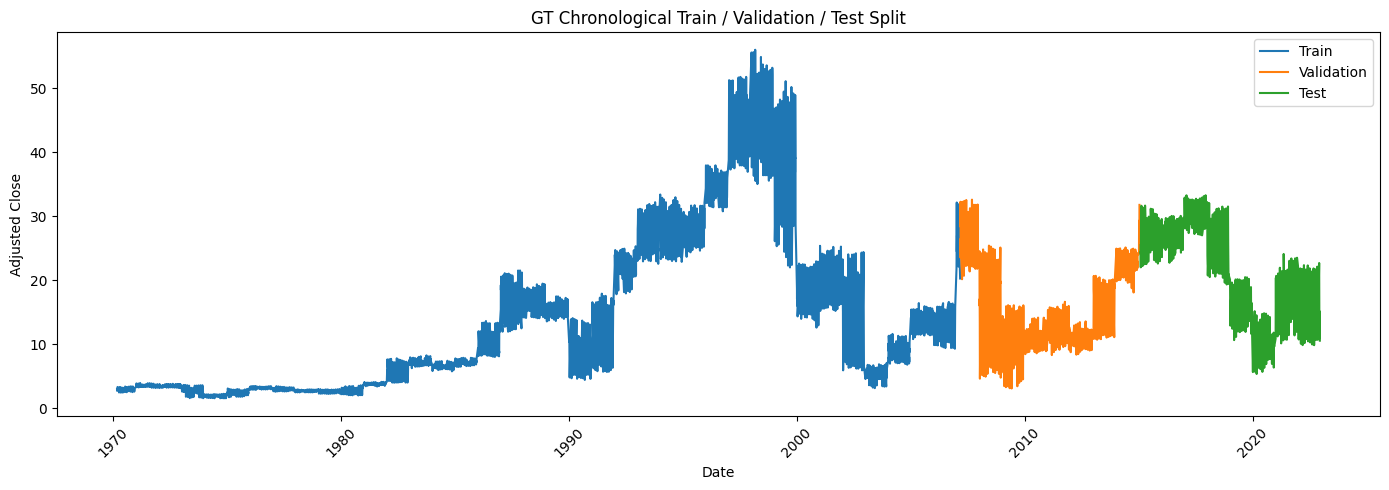

In [127]:
# Chronological Splitting
nasdaq_train_df, nasdaq_val_df, nasdaq_test_df = chronological_train_val_test_split(
    data=nasdaq_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
)

print("Train shape:", nasdaq_train_df.shape)
print("Validation shape:", nasdaq_val_df.shape)
print("Test shape:", nasdaq_test_df.shape)

plot_chronological_split(
    train_data=nasdaq_train_df,
    val_data=nasdaq_val_df,
    test_data=nasdaq_test_df,
    date_column=DATE_COLUMN,
    target_column=TARGET_COLUMN,
    title=f"{NASDAQ_TICKER} Chronological Train / Validation / Test Split",
)

In [128]:
# Time-series cross-validation validation of setup
nasdaq_cv_df = nasdaq_df.iloc[: int(len(nasdaq_df) * (TRAIN_RATIO + VAL_RATIO))].copy()

task_1_time_series_cv_results = run_time_series_cross_validation(
    data=nasdaq_cv_df,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    lookback_days=LOOKBACK_DAYS,
    forecast_horizon=1,
    multi_output=False,
    n_splits=3,
    epochs=CV_EPOCHS,
    batch_size=BATCH_SIZE,
    patience=5,
    model_type=MODEL_TYPE,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECURRENT_DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

print("Task 1 Time-Series Cross-Validation Results:")
display(task_1_time_series_cv_results)

Task 1 Time-Series Cross-Validation Results:


,Fold,Train Rows,Validation Rows,MAE,MSE,RMSE,MAPE,sMAPE,R2,Directional Accuracy
0,1,1116,1116,4.189321,34.568459,5.879495,29.865240,37.707606,-0.189866,42.690583
1,2,2232,1116,3.196073,18.545224,4.306417,15.665344,13.711034,0.878242,45.919283
2,3,3348,1116,2.455315,11.287983,3.359759,18.623312,17.650739,0.702829,45.560538


### Task 1.1: Nasdaq Multi-feature k-th Forecast

Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0064 - mae: 0.0785 - val_loss: 0.0027 - val_mae: 0.0574 - learning_rate: 3.0000e-04
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0041 - mae: 0.0653 - val_loss: 0.0034 - val_mae: 0.0637 - learning_rate: 3.0000e-04
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0037 - mae: 0.0592 - val_loss: 0.0036 - val_mae: 0.0649 - learning_rate: 3.0000e-04
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0035 - mae: 0.0574 - val_loss: 0.0035 - val_mae: 0.0637 - learning_rate: 3.0000e-04
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0031 - mae: 0.0547 - val_loss: 0.0034 - val_mae: 0.0632 - learning_rate: 3.0000e-04
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0034 - mae: 0.0576 - val_loss: 0.0027 - val_mae: 0.0558 - learning_rate: 1.5000e-04
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0031 - mae: 0.0541 - val_loss: 0.0024 - val_mae: 0.0529

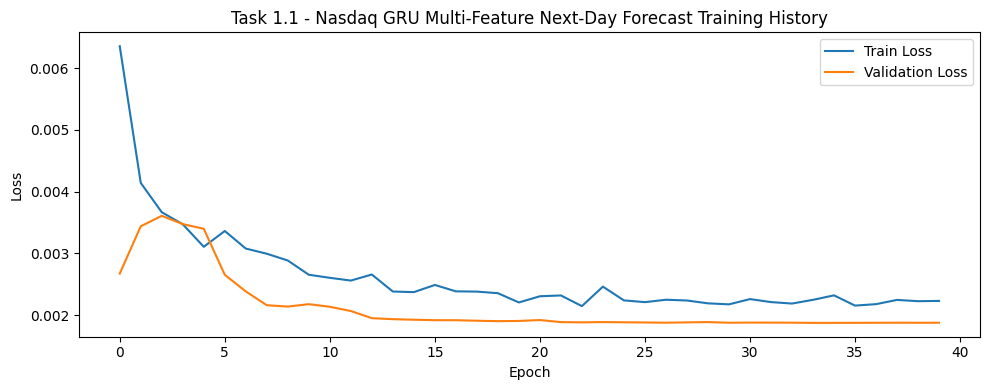

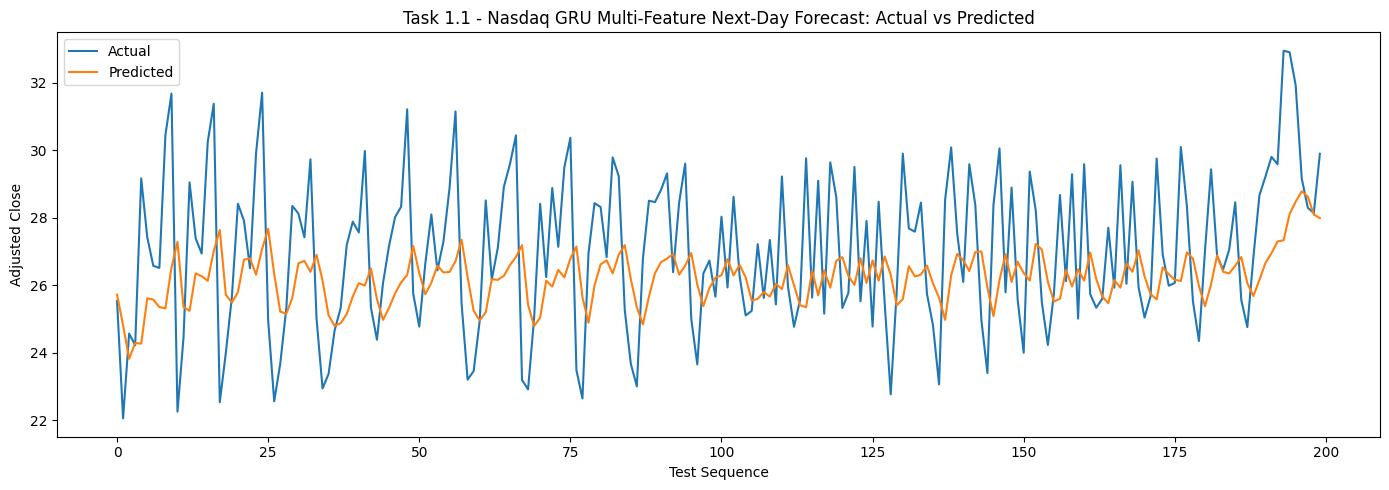

In [129]:
# Next day forecast sample
task_1_1_results = run_recurrent_forecast_experiment(
    experiment_name="Task 1.1 - Nasdaq GRU Multi-Feature Next-Day Forecast",
    train_data=nasdaq_train_df,
    val_data=nasdaq_val_df,
    test_data=nasdaq_test_df,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    lookback_days=LOOKBACK_DAYS,
    forecast_horizon=1,
    multi_output=False,
    model_type=MODEL_TYPE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECURRENT_DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

In [130]:
# Compare this model result with baseline
compare_gru_vs_baselines(
    experiment_results=task_1_1_results,
    last_known_price=float(nasdaq_val_df[TARGET_COLUMN].iloc[-1]),
    experiment_label="Task 1.1 Nasdaq",
)


  Task 1.1 Nasdaq — GRU vs Naive Baselines


,Model,MAE,RMSE,sMAPE (%),R2,Directional Accuracy (%)
0,GRU (your model),2.336081,3.034594,13.102747,0.835789,42.312579
1,Persistent (naive),2.449644,3.466587,13.575483,0.785708,46.886912
2,Mean baseline,6.557747,7.488572,33.848438,0.000000,0.000000



Interpretation:
  ✗ GRU Directional Accuracy (42.3%) does NOT beat persistent (46.9%) — try larger lookback or more epochs.
  ✓ GRU sMAPE (13.10%) BETTER than persistent (13.58%).



### Task 1.2: Nasdaq 𝑘-th day forecast

Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0069 - mae: 0.0837 - val_loss: 0.0038 - val_mae: 0.0667 - learning_rate: 3.0000e-04
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0055 - mae: 0.0744 - val_loss: 0.0047 - val_mae: 0.0745 - learning_rate: 3.0000e-04
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0047 - mae: 0.0684 - val_loss: 0.0051 - val_mae: 0.0770 - learning_rate: 3.0000e-04
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0042 - mae: 0.0645 - val_loss: 0.0051 - val_mae: 0.0756 - learning_rate: 3.0000e-04
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0036 - mae: 0.0592 - val_loss: 0.0047 - val_mae: 0.0729 - learning_rate: 3.0000e-04
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0039 - mae: 0.0621 - val_loss: 0.0030 - val_mae: 0.0587 - learning_rate: 1.5000e-04
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0038 - mae: 0.0601 - val_loss: 0.0027 - val_mae: 0.0558

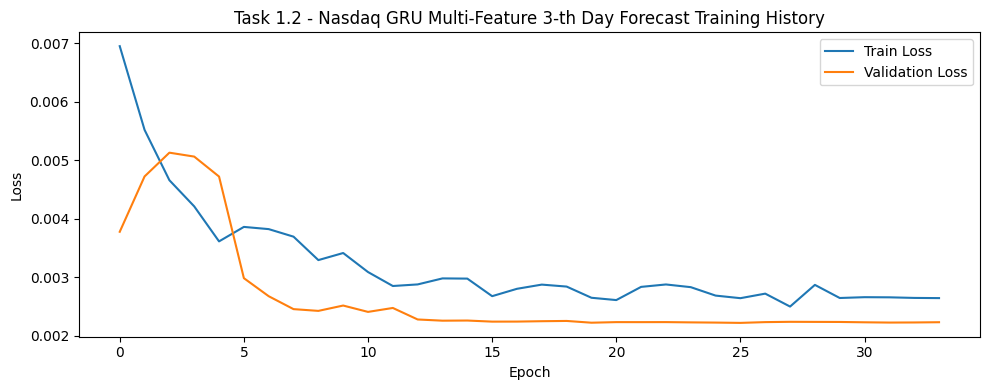

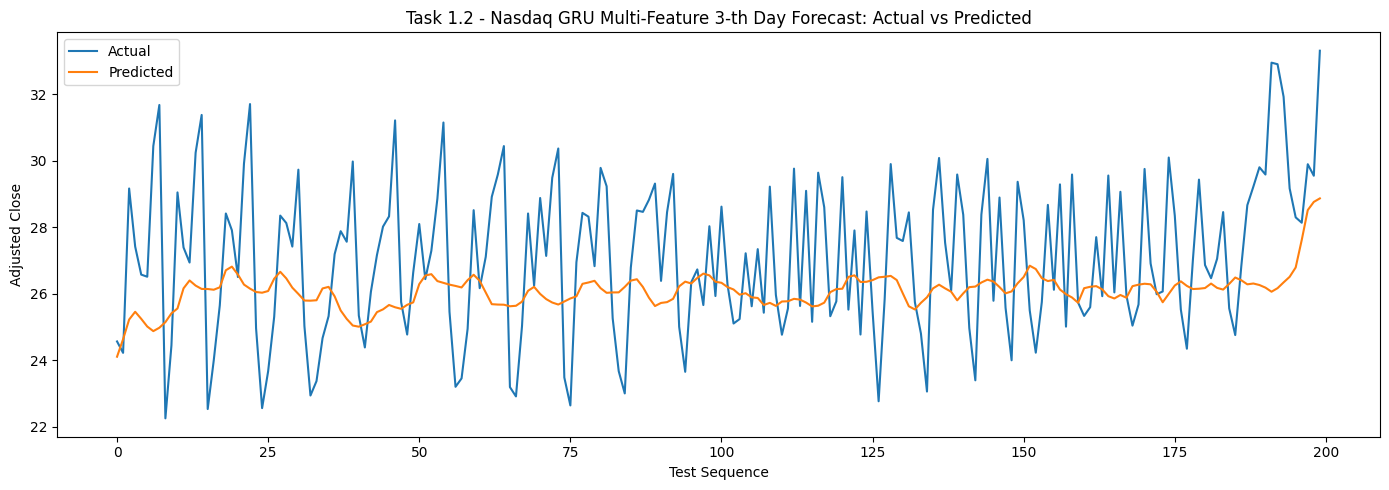

In [131]:
# k-day forecasting with k=3
task_1_2_results = run_recurrent_forecast_experiment(
    experiment_name=f"Task 1.2 - Nasdaq GRU Multi-Feature {K_TH_DAY}-th Day Forecast",
    train_data=nasdaq_train_df,
    val_data=nasdaq_val_df,
    test_data=nasdaq_test_df,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    lookback_days=LOOKBACK_DAYS,
    forecast_horizon=K_TH_DAY,
    multi_output=False,
    model_type=MODEL_TYPE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECURRENT_DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

### Task 1.3: Nasdaq 𝑘 days forecast

Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0081 - mae: 0.0907 - val_loss: 0.0061 - val_mae: 0.0834 - learning_rate: 3.0000e-04
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0061 - mae: 0.0767 - val_loss: 0.0048 - val_mae: 0.0735 - learning_rate: 3.0000e-04
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0052 - mae: 0.0696 - val_loss: 0.0043 - val_mae: 0.0700 - learning_rate: 3.0000e-04
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0049 - mae: 0.0668 - val_loss: 0.0042 - val_mae: 0.0692 - learning_rate: 3.0000e-04
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0045 - mae: 0.0636 - val_loss: 0.0039 - val_mae: 0.0671 - learning_rate: 3.0000e-04
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0044 - mae: 0.0625 - val_loss: 0.0038 - val_mae: 0.0657 - learning_rate: 3.0000e-04
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0040 - mae: 0.0597 - val_loss: 0.0037 - val_mae: 0.0652

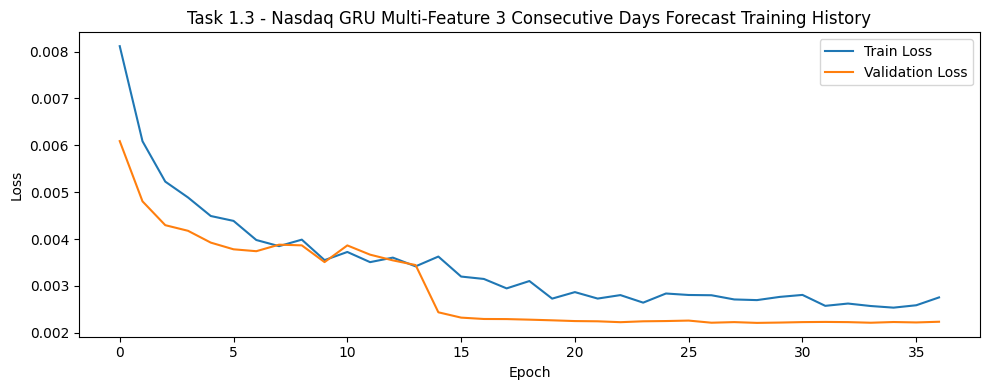

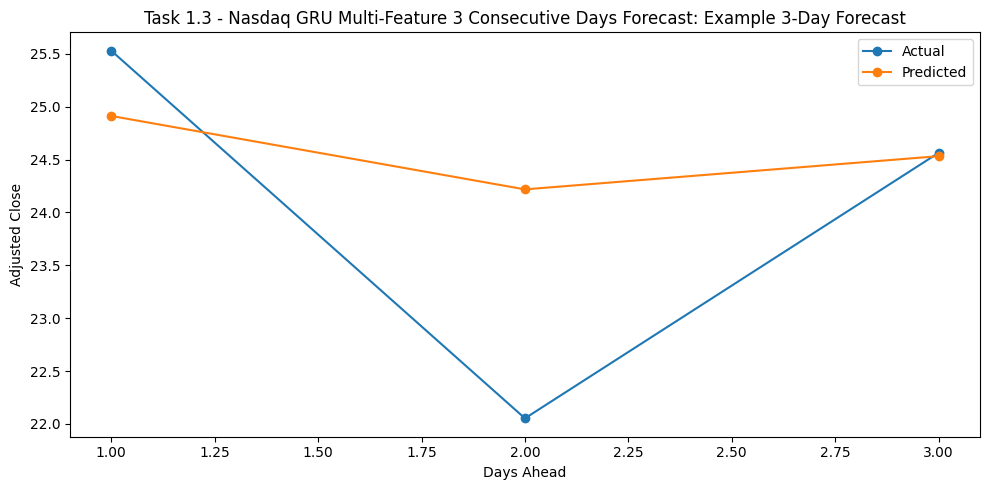

In [132]:
task_1_3_results = run_recurrent_forecast_experiment(
    experiment_name=(
        f"Task 1.3 - Nasdaq GRU Multi-Feature "
        f"{K_CONSECUTIVE_DAYS} Consecutive Days Forecast"
    ),
    train_data=nasdaq_train_df,
    val_data=nasdaq_val_df,
    test_data=nasdaq_test_df,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    lookback_days=LOOKBACK_DAYS,
    forecast_horizon=K_CONSECUTIVE_DAYS,
    multi_output=True,
    model_type=MODEL_TYPE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECURRENT_DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

### Task 1: Summary

In [133]:
# Summary of 3 models
task_1_summary = pd.DataFrame(
    [
        {
            "Task": "Task 1.1",
            "Model": task_1_1_results["model_type"].upper(),
            "Description": "Multi-feature next-day forecast",
            **task_1_1_results["metrics"],
        },
        {
            "Task": "Task 1.2",
            "Model": task_1_2_results["model_type"].upper(),
            "Description": f"Multi-feature {K_TH_DAY}-th day forecast",
            **task_1_2_results["metrics"],
        },
        {
            "Task": "Task 1.3",
            "Model": task_1_3_results["model_type"].upper(),
            "Description": f"Multi-feature {K_CONSECUTIVE_DAYS} consecutive days forecast",
            **task_1_3_results["metrics"],
        },
    ]
)

display(task_1_summary)

,Task,Model,Description,MAE,MSE,RMSE,MAPE,sMAPE,R2,Directional Accuracy
0,Task 1.1,GRU,Multi-feature next-day forecast,2.336081,9.208758,3.034594,13.547285,13.102747,0.835789,42.312579
1,Task 1.2,GRU,Multi-feature 3-th day forecast,2.479000,10.303674,3.209934,14.406667,13.899241,0.816622,50.191083
2,Task 1.3,GRU,Multi-feature 3 consecutive days forecast,2.477878,10.178839,3.190429,14.258997,13.839722,0.818482,55.112431


## Task 2: Vietnam stock price prediction

In [142]:
VIETNAM_DATASET_DIR = RAW_DATA_DIR / "vn_dataset"

VIETNAM_STOCK_DATA_DIR = VIETNAM_DATASET_DIR / "stock-historical-data"
VIETNAM_DIVIDEND_DATA_DIR = VIETNAM_DATASET_DIR / "dividend-history"
VIETNAM_FINANCIAL_RATIO_DATA_DIR = VIETNAM_DATASET_DIR / "financial-ratio"
VIETNAM_INDUSTRY_ANALYSIS_DATA_DIR = VIETNAM_DATASET_DIR / "industry-analysis"

VIETNAM_COMPANIES_FILE = VIETNAM_DATASET_DIR / "companies.csv"
VIETNAM_TICKER_OVERVIEW_FILE = VIETNAM_DATASET_DIR / "ticker-overview.csv"

In [143]:
def resolve_vietnam_price_data_dir(
    dataset_dir: Path,
    stock_data_dir: Path,
) -> Path:
    """
    The Vietnam dataset may store historical CSV files either:
    1. directly under vn_dataset/, or
    2. under vn_dataset/stock-historical-data/.

    This resolver chooses the folder that actually contains historical CSVs.
    """
    if stock_data_dir.exists() and any(stock_data_dir.rglob("*.csv")):
        return stock_data_dir

    if dataset_dir.exists() and any(dataset_dir.glob("*.csv")):
        return dataset_dir

    if dataset_dir.exists() and any(dataset_dir.rglob("*.csv")):
        return dataset_dir

    raise FileNotFoundError(
        "No Vietnam historical stock CSV files found. Checked: "
        f"{stock_data_dir} and {dataset_dir}"
    )


VIETNAM_PRICE_DATA_DIR = resolve_vietnam_price_data_dir(
    dataset_dir=VIETNAM_DATASET_DIR,
    stock_data_dir=VIETNAM_STOCK_DATA_DIR,
)

print("Vietnam dataset directory:", VIETNAM_DATASET_DIR)
print("Vietnam stock-historical-data directory:", VIETNAM_STOCK_DATA_DIR)
print("Resolved Vietnam price data directory:", VIETNAM_PRICE_DATA_DIR)
print("Vietnam price data directory exists:", VIETNAM_PRICE_DATA_DIR.exists())

print("Vietnam supplemental directories:")
print("Dividend history:", VIETNAM_DIVIDEND_DATA_DIR.exists(), VIETNAM_DIVIDEND_DATA_DIR)
print("Financial ratio:", VIETNAM_FINANCIAL_RATIO_DATA_DIR.exists(), VIETNAM_FINANCIAL_RATIO_DATA_DIR)
print("Industry analysis:", VIETNAM_INDUSTRY_ANALYSIS_DATA_DIR.exists(), VIETNAM_INDUSTRY_ANALYSIS_DATA_DIR)

Vietnam dataset directory: /content/drive/MyDrive/Deep Learning Project/data/raw/vn_dataset
Vietnam stock-historical-data directory: /content/drive/MyDrive/Deep Learning Project/data/raw/vn_dataset/stock-historical-data
Resolved Vietnam price data directory: /content/drive/MyDrive/Deep Learning Project/data/raw/vn_dataset
Vietnam price data directory exists: True
Vietnam supplemental directories:
Dividend history: True /content/drive/MyDrive/Deep Learning Project/data/raw/vn_dataset/dividend-history
Financial ratio: True /content/drive/MyDrive/Deep Learning Project/data/raw/vn_dataset/financial-ratio
Industry analysis: True /content/drive/MyDrive/Deep Learning Project/data/raw/vn_dataset/industry-analysis


In [157]:
# ============================================================
# Vietnam Stock Data Helper Utilities
# Supports files like:
# - ACB-VNINDEX-History.csv
# - BCB-UpcomIndex-History.csv
# - A32-UpcomIndex-History.csv
# ============================================================
VIETNAM_SELECTION_STRATEGY = "stable_active"
VIETNAM_PREFERRED_TICKER: str | None = None

VIETNAM_DATE_COLUMN = "Date"
VIETNAM_TARGET_COLUMN = "Close"

VIETNAM_REQUIRED_PRICE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
]

VIETNAM_FEATURE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Log Return",
    "MA10",
    "MA20",
    "Volatility10",
]

VIETNAM_MIN_HISTORY_POINTS = 120
VIETNAM_SPIKE_THRESHOLD = 0.08
VIETNAM_MIN_NONZERO_VOLUME_RATE = 0.50
VIETNAM_MIN_MEDIAN_VOLUME = 1_000
VIETNAM_MAX_FLAT_CLOSE_RATE = 0.50
VIETNAM_MIN_UNIQUE_CLOSE_VALUES = 30
VIETNAM_MIN_CLOSE_RETURN_STD = 0.001
VIETNAM_MAX_CLOSE_SPIKE_RATE = 0.15

VIETNAM_LOOKBACK_DAYS = LOOKBACK_DAYS
VIETNAM_TRAIN_RATIO = TRAIN_RATIO
VIETNAM_VAL_RATIO = VAL_RATIO

VIETNAM_MODEL_TYPE = MODEL_TYPE
VIETNAM_DROPOUT_RATE = DROPOUT_RATE - 0.05
VIETNAM_RECURRENT_DROPOUT_RATE = 0.01
VIETNAM_LEARNING_RATE = LEARNING_RATE
VIETNAM_PATIENCE = PATIENCE
VIETNAM_BATCH_SIZE = BATCH_SIZE
VIETNAM_EPOCHS = EPOCHS
VIETNAM_CV_EPOCHS = CV_EPOCHS

VIETNAM_K_TH_DAY = K_TH_DAY
VIETNAM_K_CONSECUTIVE_DAYS = K_CONSECUTIVE_DAYS

In [145]:
# ============================================================
# Vietnam Stock Data Helper Utilities
# Supports files like:
# - ACB-VNINDEX-History.csv
# - BCB-UpcomIndex-History.csv
# - A32-UpcomIndex-History.csv
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd

def extract_vietnam_ticker_from_filename(file_path: Path) -> str:
    return file_path.stem.split("-")[0].upper()


def extract_vietnam_market_from_filename(file_path: Path) -> str:
    parts = file_path.stem.split("-")

    if len(parts) >= 2:
        return parts[1].upper()

    return "UNKNOWN"


def list_available_vietnam_tickers(data_dir: Path) -> list[str]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Vietnam data directory does not exist: {data_dir}")

    return sorted(
        {
            extract_vietnam_ticker_from_filename(csv_file)
            for csv_file in data_dir.rglob("*.csv")
        }
    )


def find_vietnam_ticker_file(data_dir: Path, ticker: str) -> Path:
    ticker = ticker.upper()

    matched_files = [
        csv_file
        for csv_file in sorted(data_dir.rglob("*.csv"))
        if extract_vietnam_ticker_from_filename(csv_file) == ticker
    ]

    if matched_files:
        return matched_files[0]

    available_tickers = list_available_vietnam_tickers(data_dir)

    raise FileNotFoundError(
        f"Missing Vietnam ticker file for {ticker}. "
        f"Available examples: {available_tickers[:30]}"
    )


def parse_vietnam_numeric_column(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )


def read_vietnam_history_csv(file_path: Path) -> pd.DataFrame:
    data = pd.read_csv(file_path)
    data.columns = [str(column).strip() for column in data.columns]

    rename_map = {
        "TradingDate": "Date",
        "tradingDate": "Date",
        "date": "Date",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
    }

    data = data.rename(columns=rename_map)

    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])

    required_columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
    validate_required_columns(data, required_columns)

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

    for column in ["Open", "High", "Low", "Close", "Volume"]:
        data[column] = parse_vietnam_numeric_column(data[column])

    data = data.dropna(subset=required_columns)
    data = data.sort_values("Date").reset_index(drop=True)

    data["Ticker"] = extract_vietnam_ticker_from_filename(file_path)
    data["Market"] = extract_vietnam_market_from_filename(file_path)
    data["Source File"] = file_path.name

    return data


def load_vietnam_stock_price_data(
    data_dir: Path,
    ticker: str,
) -> pd.DataFrame:
    ticker_file = find_vietnam_ticker_file(
        data_dir=data_dir,
        ticker=ticker,
    )

    return read_vietnam_history_csv(ticker_file)


def compute_vietnam_price_quality_metrics(
    data: pd.DataFrame,
    ticker: str,
    market: str,
    source_file: str,
    spike_threshold: float = 0.08,
) -> dict[str, object]:
    quality_data = data.copy().sort_values("Date").reset_index(drop=True)

    close_return = quality_data["Close"].pct_change(fill_method=None)
    close_return = close_return.replace([np.inf, -np.inf], np.nan)

    flat_close_rate = quality_data["Close"].diff().eq(0).mean()
    nonzero_volume_rate = quality_data["Volume"].gt(0).mean()
    median_volume = quality_data["Volume"].median()
    median_dollar_volume = (quality_data["Close"] * quality_data["Volume"]).median()
    unique_close_values = quality_data["Close"].nunique()

    close_return_std = close_return.std()
    close_mean_abs_return = close_return.abs().mean()
    close_spike_rate = (close_return.abs() > spike_threshold).mean()
    close_max_abs_return = close_return.abs().max()

    active_stability_score = (
        10.0 * float(close_return_std if pd.notna(close_return_std) else 999)
        + 5.0 * float(close_mean_abs_return if pd.notna(close_mean_abs_return) else 999)
        + 3.0 * float(close_spike_rate if pd.notna(close_spike_rate) else 999)
        + 2.0 * float(flat_close_rate)
        - 0.05 * np.log1p(float(median_dollar_volume if pd.notna(median_dollar_volume) else 0))
    )

    return {
        "Ticker": ticker.upper(),
        "Market": market,
        "Rows": len(quality_data),
        "Start Date": quality_data["Date"].min(),
        "End Date": quality_data["Date"].max(),
        "Close Return Std": float(close_return_std) if pd.notna(close_return_std) else np.nan,
        "Close Mean Abs Return": float(close_mean_abs_return) if pd.notna(close_mean_abs_return) else np.nan,
        "Close Spike Rate": float(close_spike_rate) if pd.notna(close_spike_rate) else np.nan,
        "Close Max Abs Return": float(close_max_abs_return) if pd.notna(close_max_abs_return) else np.nan,
        "Flat Close Rate": float(flat_close_rate),
        "Nonzero Volume Rate": float(nonzero_volume_rate),
        "Median Volume": float(median_volume),
        "Median Dollar Volume": float(median_dollar_volume),
        "Unique Close Values": int(unique_close_values),
        "Active Stability Score": float(active_stability_score),
        "Spike Threshold": spike_threshold,
        "File": source_file,
    }


def filter_valid_vietnam_tickers(
    data_dir: Path,
    min_history_points: int = 120,
    spike_threshold: float = 0.08,
    min_nonzero_volume_rate: float = 0.50,
    min_median_volume: float = 1_000,
    max_flat_close_rate: float = 0.50,
    min_unique_close_values: int = 30,
    min_close_return_std: float = 0.001,
    max_close_spike_rate: float = 0.15,
    include_ineligible: bool = False,
) -> pd.DataFrame:
    if not data_dir.exists():
        raise FileNotFoundError(f"Vietnam data directory does not exist: {data_dir}")

    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No Vietnam CSV files found under: {data_dir}")

    ticker_rows = []

    for csv_file in csv_files:
        ticker = extract_vietnam_ticker_from_filename(csv_file)
        market = extract_vietnam_market_from_filename(csv_file)

        try:
            data = read_vietnam_history_csv(csv_file)

            metrics = compute_vietnam_price_quality_metrics(
                data=data,
                ticker=ticker,
                market=market,
                source_file=csv_file.name,
                spike_threshold=spike_threshold,
            )

            has_enough_history = metrics["Rows"] >= min_history_points
            has_enough_active_volume = metrics["Nonzero Volume Rate"] >= min_nonzero_volume_rate
            has_enough_median_volume = metrics["Median Volume"] >= min_median_volume
            has_not_too_many_flat_days = metrics["Flat Close Rate"] <= max_flat_close_rate
            has_enough_unique_prices = metrics["Unique Close Values"] >= min_unique_close_values
            has_real_movement = metrics["Close Return Std"] >= min_close_return_std
            has_not_too_many_spikes = metrics["Close Spike Rate"] <= max_close_spike_rate

            is_eligible = (
                has_enough_history
                and has_enough_active_volume
                and has_enough_median_volume
                and has_not_too_many_flat_days
                and has_enough_unique_prices
                and has_real_movement
                and has_not_too_many_spikes
            )

            failed_reasons = []

            if not has_enough_history:
                failed_reasons.append(f"Rows < {min_history_points}")

            if not has_enough_active_volume:
                failed_reasons.append(f"Nonzero Volume Rate < {min_nonzero_volume_rate}")

            if not has_enough_median_volume:
                failed_reasons.append(f"Median Volume < {min_median_volume}")

            if not has_not_too_many_flat_days:
                failed_reasons.append(f"Flat Close Rate > {max_flat_close_rate}")

            if not has_enough_unique_prices:
                failed_reasons.append(f"Unique Close Values < {min_unique_close_values}")

            if not has_real_movement:
                failed_reasons.append(f"Close Return Std < {min_close_return_std}")

            if not has_not_too_many_spikes:
                failed_reasons.append(f"Close Spike Rate > {max_close_spike_rate}")

            metrics["Eligible"] = is_eligible
            metrics["Reason"] = "Eligible" if is_eligible else "; ".join(failed_reasons)

            if include_ineligible or is_eligible:
                ticker_rows.append(metrics)

        except Exception as error:
            if include_ineligible:
                ticker_rows.append(
                    {
                        "Ticker": ticker,
                        "Market": market,
                        "Rows": 0,
                        "Eligible": False,
                        "Reason": str(error),
                        "File": csv_file.name,
                    }
                )
            else:
                print(f"Skipping {csv_file.name}: {error}")

    result = pd.DataFrame(ticker_rows)

    if result.empty:
        return pd.DataFrame(
            columns=[
                "Ticker",
                "Market",
                "Rows",
                "Start Date",
                "End Date",
                "Close Return Std",
                "Close Mean Abs Return",
                "Close Spike Rate",
                "Close Max Abs Return",
                "Flat Close Rate",
                "Nonzero Volume Rate",
                "Median Volume",
                "Median Dollar Volume",
                "Unique Close Values",
                "Active Stability Score",
                "Eligible",
                "Reason",
                "File",
            ]
        )

    return result.sort_values(
        by=["Eligible", "Active Stability Score", "Rows", "Ticker"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)


def rank_vietnam_tickers_by_stable_active_behavior(
    valid_tickers: pd.DataFrame,
) -> pd.DataFrame:
    eligible_tickers = valid_tickers[valid_tickers["Eligible"]].copy()

    if eligible_tickers.empty:
        return eligible_tickers

    return eligible_tickers.sort_values(
        by=[
            "Active Stability Score",
            "Close Return Std",
            "Close Spike Rate",
            "Flat Close Rate",
            "Median Dollar Volume",
            "Rows",
            "Ticker",
        ],
        ascending=[True, True, True, True, False, False, True],
    ).reset_index(drop=True)


def select_vietnam_ticker_from_valid_list(
    valid_tickers: pd.DataFrame,
    preferred_ticker: str | None = None,
    selection_strategy: str = "stable_active",
) -> str:
    if valid_tickers.empty:
        raise ValueError("No eligible Vietnam tickers found after filtering.")

    eligible_tickers = valid_tickers[valid_tickers["Eligible"]].copy()

    if eligible_tickers.empty:
        raise ValueError("No Vietnam ticker remains after applying the Eligible filter.")

    eligible_tickers["Ticker"] = eligible_tickers["Ticker"].astype(str).str.upper()

    if selection_strategy == "preferred":
        if preferred_ticker is not None:
            preferred_ticker = preferred_ticker.upper()
            preferred_matches = eligible_tickers["Ticker"] == preferred_ticker

            if preferred_matches.any():
                return preferred_ticker

            print(
                f"Preferred Vietnam ticker {preferred_ticker} was not eligible. "
                "Falling back to stable-active selection."
            )

        ranked_tickers = rank_vietnam_tickers_by_stable_active_behavior(eligible_tickers)
        return str(ranked_tickers.iloc[0]["Ticker"])

    if selection_strategy == "stable_active":
        ranked_tickers = rank_vietnam_tickers_by_stable_active_behavior(eligible_tickers)
        return str(ranked_tickers.iloc[0]["Ticker"])

    if selection_strategy == "longest_history":
        ranked_tickers = eligible_tickers.sort_values(
            by=["Rows", "Ticker"],
            ascending=[False, True],
        ).reset_index(drop=True)

        return str(ranked_tickers.iloc[0]["Ticker"])

    if selection_strategy == "first":
        return str(eligible_tickers.iloc[0]["Ticker"])

    raise ValueError(
        "selection_strategy must be one of: "
        "'preferred', 'stable_active', 'longest_history', or 'first'."
    )


def select_vietnam_ticker_safely(
    valid_tickers: pd.DataFrame,
    data_dir: Path,
    preferred_ticker: str | None = None,
    selection_strategy: str = "stable_active",
) -> str:
    available_tickers = set(list_available_vietnam_tickers(data_dir))

    if preferred_ticker is not None:
        preferred_ticker = preferred_ticker.upper()

        if preferred_ticker not in available_tickers:
            print(
                f"Preferred ticker {preferred_ticker} does not exist in the Vietnam folder. "
                "Falling back to automatic selection."
            )
            preferred_ticker = None

    return select_vietnam_ticker_from_valid_list(
        valid_tickers=valid_tickers,
        preferred_ticker=preferred_ticker,
        selection_strategy="preferred" if preferred_ticker is not None else selection_strategy,
    )


def display_vietnam_ticker_selection_diagnostics(
    valid_tickers: pd.DataFrame,
    selected_ticker: str,
    top_n: int = 20,
) -> None:
    selected_ticker = selected_ticker.upper()

    display_columns = [
        "Ticker",
        "Market",
        "Rows",
        "Start Date",
        "End Date",
        "Active Stability Score",
        "Close Return Std",
        "Close Mean Abs Return",
        "Close Spike Rate",
        "Close Max Abs Return",
        "Flat Close Rate",
        "Nonzero Volume Rate",
        "Median Volume",
        "Median Dollar Volume",
        "Unique Close Values",
        "Eligible",
        "Reason",
        "File",
    ]

    display_columns = [
        column for column in display_columns
        if column in valid_tickers.columns
    ]

    print("Vietnam eligible tickers sorted by stable-active behavior:")
    display(
        rank_vietnam_tickers_by_stable_active_behavior(valid_tickers)[
            display_columns
        ].head(top_n)
    )

    print(f"Selected Vietnam ticker: {selected_ticker}")

    selected_row = valid_tickers[
        valid_tickers["Ticker"].astype(str).str.upper() == selected_ticker
    ]

    if not selected_row.empty:
        display(selected_row[display_columns])

In [146]:
# ============================================================
# Task 2 Load & Filter Vietnam Stock Data
# Use VIETNAM_PRICE_DATA_DIR everywhere.
# ============================================================

vietnam_valid_tickers_debug = filter_valid_vietnam_tickers(
    data_dir=VIETNAM_PRICE_DATA_DIR,
    min_history_points=VIETNAM_MIN_HISTORY_POINTS,
    spike_threshold=VIETNAM_SPIKE_THRESHOLD,
    min_nonzero_volume_rate=VIETNAM_MIN_NONZERO_VOLUME_RATE,
    min_median_volume=VIETNAM_MIN_MEDIAN_VOLUME,
    max_flat_close_rate=VIETNAM_MAX_FLAT_CLOSE_RATE,
    min_unique_close_values=VIETNAM_MIN_UNIQUE_CLOSE_VALUES,
    min_close_return_std=VIETNAM_MIN_CLOSE_RETURN_STD,
    max_close_spike_rate=VIETNAM_MAX_CLOSE_SPIKE_RATE,
    include_ineligible=True,
)

print("Vietnam filtering reason counts:")
display(vietnam_valid_tickers_debug["Reason"].value_counts())

vietnam_valid_tickers = vietnam_valid_tickers_debug[
    vietnam_valid_tickers_debug["Eligible"]
].copy().reset_index(drop=True)

print("Available Vietnam ticker examples:")
print(list_available_vietnam_tickers(VIETNAM_PRICE_DATA_DIR)[:50])

VIETNAM_TICKER = select_vietnam_ticker_safely(
    valid_tickers=vietnam_valid_tickers,
    data_dir=VIETNAM_PRICE_DATA_DIR,
    preferred_ticker=VIETNAM_PREFERRED_TICKER,
    selection_strategy=VIETNAM_SELECTION_STRATEGY,
)

display_vietnam_ticker_selection_diagnostics(
    valid_tickers=vietnam_valid_tickers,
    selected_ticker=VIETNAM_TICKER,
    top_n=20,
)

vietnam_raw_df = load_vietnam_stock_price_data(
    data_dir=VIETNAM_PRICE_DATA_DIR,
    ticker=VIETNAM_TICKER,
)

vietnam_df = prepare_price_features(
    data=vietnam_raw_df,
    date_column=VIETNAM_DATE_COLUMN,
    required_price_columns=VIETNAM_REQUIRED_PRICE_COLUMNS,
    feature_columns=VIETNAM_FEATURE_COLUMNS,
    target_column=VIETNAM_TARGET_COLUMN,
    min_history_points=VIETNAM_MIN_HISTORY_POINTS,
)

vietnam_preview_columns = make_unique_columns(
    [VIETNAM_DATE_COLUMN] + VIETNAM_FEATURE_COLUMNS + [VIETNAM_TARGET_COLUMN]
)

print(f"{VIETNAM_TICKER} prepared shape:", vietnam_df.shape)
display(vietnam_df[vietnam_preview_columns].head())
display(vietnam_df[vietnam_preview_columns].tail())

Vietnam filtering reason counts:


,count
Reason,
"Missing required columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']",1337
Eligible,450
Nonzero Volume Rate < 0.5; Median Volume < 1000; Flat Close Rate > 0.5,136
Median Volume < 1000; Flat Close Rate > 0.5,74
Median Volume < 1000,55
Flat Close Rate > 0.5,16
Nonzero Volume Rate < 0.5; Median Volume < 1000; Flat Close Rate > 0.5; Unique Close Values < 30,16
Nonzero Volume Rate < 0.5; Median Volume < 1000; Flat Close Rate > 0.5; Close Spike Rate > 0.15,9
Nonzero Volume Rate < 0.5; Median Volume < 1000; Flat Close Rate > 0.5; Unique Close Values < 30; Close Return Std < 0.001,6


Available Vietnam ticker examples:
['A32', 'AAA', 'AAM', 'AAS', 'AAT', 'AAV', 'ABB', 'ABC', 'ABI', 'ABR', 'ABS', 'ABT', 'ACB', 'ACC', 'ACE', 'ACG', 'ACL', 'ACM', 'ACS', 'ACV', 'ADC', 'ADG', 'ADP', 'ADS', 'AFX', 'AG1', 'AGE', 'AGF', 'AGG', 'AGM', 'AGP', 'AGR', 'AGX', 'AIC', 'ALT', 'ALV', 'AMC', 'AMD', 'AME', 'AMP', 'AMS', 'AMV', 'ANT', 'ANV', 'APC', 'APF', 'APG', 'APH', 'API', 'APL']
Vietnam eligible tickers sorted by stable-active behavior:


,Ticker,Market,Rows,Start Date,End Date,Active Stability Score,Close Return Std,Close Mean Abs Return,Close Spike Rate,Close Max Abs Return,Flat Close Rate,Nonzero Volume Rate,Median Volume,Median Dollar Volume,Unique Close Values,Eligible,Reason,File
0,VCB,VNINDEX,3413,2009-06-30,2023-02-28,-0.718964,0.019745,0.014187,0.000000,0.069974,0.099033,0.999414,746200.0,1.978835e+10,1500.0,True,Eligible,VCB-VNINDEX-History.csv
1,ACV,UPCOMINDEX,1567,2016-11-21,2023-02-28,-0.702681,0.018770,0.011860,0.007658,0.145833,0.076579,0.996171,82800.0,6.007610e+09,473.0,True,Eligible,ACV-UpcomIndex-History.csv
2,BAF,VNINDEX,306,2021-12-03,2023-02-28,-0.689722,0.033064,0.024556,0.000000,0.069953,0.042484,1.000000,1872750.0,4.647227e+10,232.0,True,Eligible,BAF-VNINDEX-History.csv
3,BID,VNINDEX,2267,2014-01-24,2023-02-28,-0.683985,0.023228,0.016313,0.000000,0.069978,0.108513,0.999118,1573190.0,3.565778e+10,1050.0,True,Eligible,BID-VNINDEX-History.csv
4,APH,VNINDEX,647,2020-07-28,2023-02-28,-0.664431,0.029850,0.021483,0.000000,0.070000,0.069552,1.000000,1728300.0,3.200182e+10,438.0,True,Eligible,APH-VNINDEX-History.csv
5,ACG,VNINDEX,383,2021-08-04,2023-02-28,-0.663953,0.018526,0.011496,0.000000,0.077266,0.099217,1.000000,60800.0,3.972320e+09,164.0,True,Eligible,ACG-VNINDEX-History.csv
6,SSI,VNINDEX,4026,2006-12-15,2023-02-28,-0.646719,0.025601,0.018772,0.001987,0.100086,0.087183,0.999255,1966835.0,1.669558e+10,2019.0,True,Eligible,SSI-VNINDEX-History.csv
7,FPT,VNINDEX,4038,2006-12-13,2023-02-28,-0.642036,0.019787,0.013945,0.000000,0.069956,0.111441,0.999505,530310.0,6.869791e+09,2026.0,True,Eligible,FPT-VNINDEX-History.csv
8,AGG,VNINDEX,781,2020-01-10,2023-02-28,-0.640900,0.017292,0.011216,0.000000,0.069988,0.145967,1.000000,440430.0,1.234721e+10,410.0,True,Eligible,AGG-VNINDEX-History.csv
9,BVH,VNINDEX,3416,2009-06-25,2023-02-28,-0.635787,0.025735,0.019052,0.000000,0.070002,0.085773,0.999415,276515.0,1.188876e+10,1638.0,True,Eligible,BVH-VNINDEX-History.csv


Selected Vietnam ticker: VCB


,Ticker,Market,Rows,Start Date,End Date,Active Stability Score,Close Return Std,Close Mean Abs Return,Close Spike Rate,Close Max Abs Return,Flat Close Rate,Nonzero Volume Rate,Median Volume,Median Dollar Volume,Unique Close Values,Eligible,Reason,File
0,VCB,VNINDEX,3413,2009-06-30,2023-02-28,-0.718964,0.019745,0.014187,0.0,0.069974,0.099033,0.999414,746200.0,1.978835e+10,1500.0,True,Eligible,VCB-VNINDEX-History.csv


VCB prepared shape: (3394, 13)


,Date,Open,High,Low,Close,Volume,Log Return,MA10,MA20,Volatility10
0,2009-07-27,14756.0,14756.0,14215.0,14756.0,1535460,0.046965,13353.6,14251.20,0.032219
1,2009-07-28,14756.0,15162.0,14215.0,14350.0,1192800,-0.027900,13494.4,14156.45,0.032610
2,2009-07-29,14215.0,14621.0,13944.0,14215.0,924570,-0.009452,13589.2,14048.15,0.032719
3,2009-07-30,14079.0,14215.0,13673.0,13944.0,606660,-0.019248,13635.2,13960.15,0.033510
4,2009-07-31,14485.0,14621.0,14350.0,14621.0,1125450,0.047410,13767.9,13933.10,0.035527


,Date,Open,High,Low,Close,Volume,Log Return,MA10,MA20,Volatility10
3389,2023-02-22,94200.0,94300.0,92500.0,93000.0,1026246,-0.012821,93290.0,92780.0,0.010548
3390,2023-02-23,93000.0,94000.0,91200.0,93300.0,1026332,0.003221,93320.0,92795.0,0.009791
3391,2023-02-24,93000.0,94000.0,90000.0,93500.0,631786,0.002141,93220.0,92820.0,0.008173
3392,2023-02-27,93000.0,93500.0,91700.0,92800.0,501731,-0.007515,93150.0,92965.0,0.007818
3393,2023-02-28,93100.0,93700.0,92600.0,93500.0,566115,0.007515,93250.0,93045.0,0.007341


In [147]:
# ============================================================
# Task 2 Supplemental Data Audit
# Add after Task 2 summary, or right after Vietnam data loading.
# This satisfies the requirement to address dividend / ratio / industry data.
# ============================================================

def audit_vietnam_supplemental_data_sources() -> pd.DataFrame:
    source_paths = {
        "Dividend History": VIETNAM_DIVIDEND_DATA_DIR,
        "Financial Ratio": VIETNAM_FINANCIAL_RATIO_DATA_DIR,
        "Industry Analysis": VIETNAM_INDUSTRY_ANALYSIS_DATA_DIR,
        "Companies Metadata": VIETNAM_COMPANIES_FILE,
        "Ticker Overview": VIETNAM_TICKER_OVERVIEW_FILE,
    }

    rows = []

    for source_name, source_path in source_paths.items():
        if source_path.is_dir():
            csv_files = sorted(source_path.rglob("*.csv"))
            rows.append(
                {
                    "Source": source_name,
                    "Path": str(source_path),
                    "Exists": True,
                    "Type": "Directory",
                    "CSV Count": len(csv_files),
                    "Used in Baseline": False,
                    "Decision": (
                        "Audited but not merged into the baseline because date alignment "
                        "is required to prevent future-data leakage."
                    ),
                }
            )
        elif source_path.is_file():
            try:
                sample_df = pd.read_csv(source_path, nrows=5)
                columns = list(sample_df.columns)
            except Exception as error:
                columns = [f"Could not read columns: {error}"]

            rows.append(
                {
                    "Source": source_name,
                    "Path": str(source_path),
                    "Exists": True,
                    "Type": "File",
                    "CSV Count": 1,
                    "Columns": columns,
                    "Used in Baseline": False,
                    "Decision": (
                        "Useful for metadata/filtering or later experiments, but not "
                        "merged into the price-only GRU baseline."
                    ),
                }
            )
        else:
            rows.append(
                {
                    "Source": source_name,
                    "Path": str(source_path),
                    "Exists": False,
                    "Type": "Missing",
                    "CSV Count": 0,
                    "Used in Baseline": False,
                    "Decision": "Not available in the current mounted folder.",
                }
            )

    return pd.DataFrame(rows)


task_2_supplemental_data_audit = audit_vietnam_supplemental_data_sources()

print("Task 2 supplemental Vietnam data audit:")
display(task_2_supplemental_data_audit)

Task 2 supplemental Vietnam data audit:


,Source,Path,Exists,Type,CSV Count,Used in Baseline,Decision
0,Dividend History,/content/drive/MyDrive/Deep Learning Project/d...,True,Directory,15,False,Audited but not merged into the baseline becau...
1,Financial Ratio,/content/drive/MyDrive/Deep Learning Project/d...,True,Directory,1629,False,Audited but not merged into the baseline becau...
2,Industry Analysis,/content/drive/MyDrive/Deep Learning Project/d...,True,Directory,1629,False,Audited but not merged into the baseline becau...
3,Companies Metadata,/content/drive/MyDrive/Deep Learning Project/d...,False,Missing,0,False,Not available in the current mounted folder.
4,Ticker Overview,/content/drive/MyDrive/Deep Learning Project/d...,False,Missing,0,False,Not available in the current mounted folder.


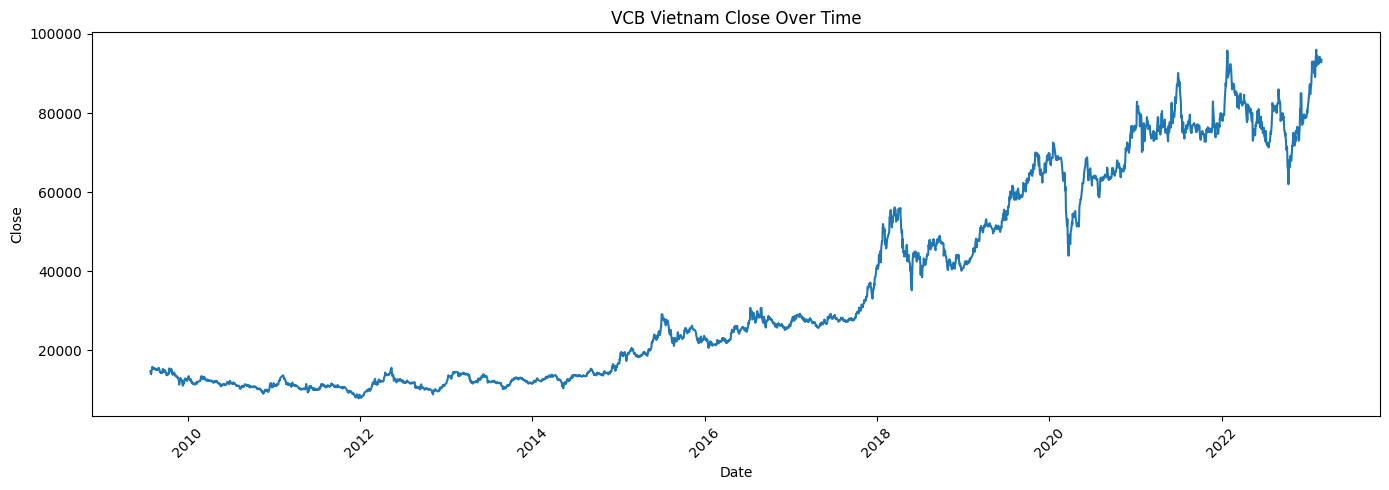

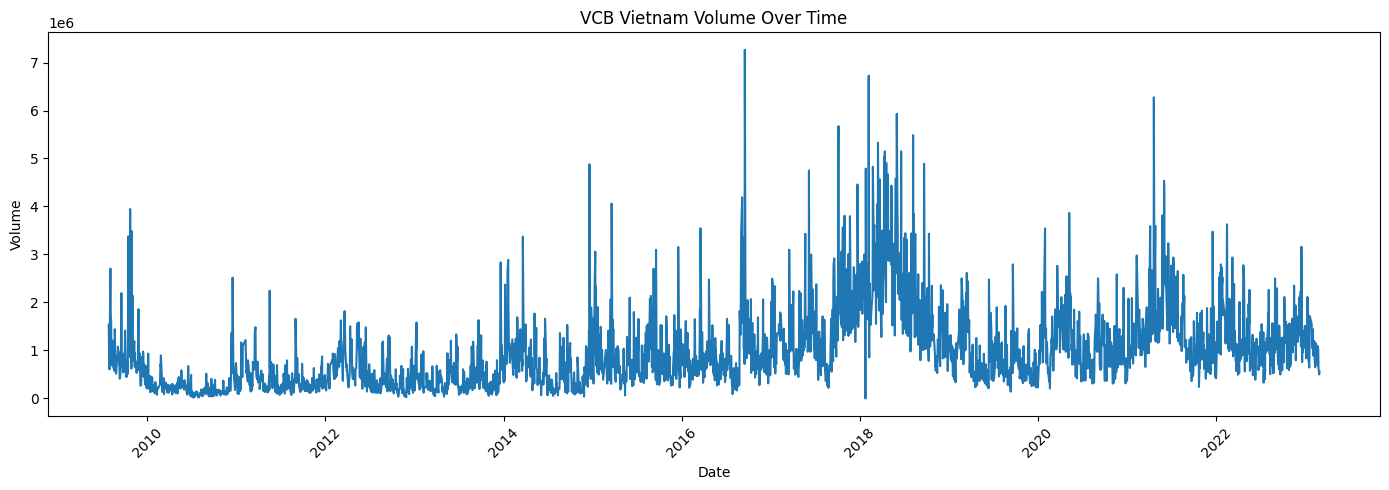

Vietnam missing values after cleaning:


,0
Open,0
High,0
Low,0
Close,0
Volume,0
Log Return,0
MA10,0
MA20,0
Volatility10,0
Close,0


Vietnam feature summary:


,Open,High,Low,Close,Volume,Log Return,MA10,MA20,Volatility10
count,3394.000000,3394.000000,3394.000000,3394.000000,3.394000e+03,3394.000000,3394.000000,3394.000000,3394.000000
mean,35140.879788,35587.528285,34716.040660,35162.021509,9.520942e+05,0.000558,35055.877048,34939.050530,0.017919
std,25584.052909,25905.860847,25253.597692,25603.720388,8.047217e+05,0.019625,25507.536388,25401.195942,0.008141
min,7819.000000,7980.000000,7819.000000,7819.000000,0.000000e+00,-0.072481,8209.900000,8306.600000,0.004040
25%,12480.500000,12655.000000,12370.000000,12480.000000,3.884475e+05,-0.009815,12468.700000,12465.850000,0.011700
50%,25637.000000,25904.000000,25464.000000,25690.000000,7.433500e+05,0.000000,25609.600000,25359.050000,0.016337
75%,58578.250000,59371.000000,58224.750000,58819.750000,1.255577e+06,0.010063,59078.275000,58387.600000,0.022901
max,95800.000000,96300.000000,94000.000000,96000.000000,7.265480e+06,0.067634,93410.000000,93045.000000,0.050036


In [148]:
# ============================================================
# Task 2: EDA with sanity warning
# ============================================================

if vietnam_df["Close"].nunique() < VIETNAM_MIN_UNIQUE_CLOSE_VALUES:
    print(
        "Warning: selected ticker still has too few unique close values. "
        "Increase strictness or choose a preferred ticker."
    )

if vietnam_df["Volume"].gt(0).mean() < VIETNAM_MIN_NONZERO_VOLUME_RATE:
    print(
        "Warning: selected ticker still has too many zero-volume days. "
        "Increase min_nonzero_volume_rate."
    )

plt.figure(figsize=(14, 5))
plt.plot(vietnam_df[VIETNAM_DATE_COLUMN], vietnam_df[VIETNAM_TARGET_COLUMN])
plt.title(f"{VIETNAM_TICKER} Vietnam {VIETNAM_TARGET_COLUMN} Over Time")
plt.xlabel("Date")
plt.ylabel(VIETNAM_TARGET_COLUMN)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(vietnam_df[VIETNAM_DATE_COLUMN], vietnam_df["Volume"])
plt.title(f"{VIETNAM_TICKER} Vietnam Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Vietnam missing values after cleaning:")
display(vietnam_df[VIETNAM_FEATURE_COLUMNS + [VIETNAM_TARGET_COLUMN]].isna().sum())

print("Vietnam feature summary:")
display(vietnam_df[VIETNAM_FEATURE_COLUMNS].describe())

### Task 2.1: Vietnam multi-feature extension

Vietnam train shape: (2375, 13)
Vietnam validation shape: (509, 13)
Vietnam test shape: (510, 13)


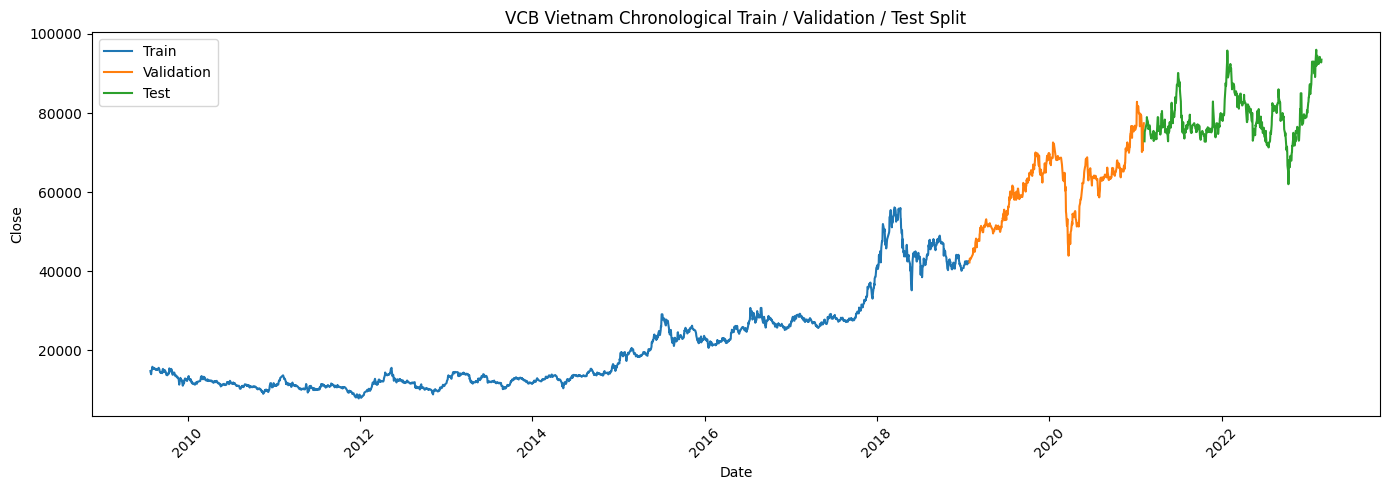

In [158]:
# Task 2.1: Chronological Train / Validation / Test Split
vietnam_train_df, vietnam_val_df, vietnam_test_df = chronological_train_val_test_split(
    data=vietnam_df,
    train_ratio=VIETNAM_TRAIN_RATIO,
    val_ratio=VIETNAM_VAL_RATIO,
)

print("Vietnam train shape:", vietnam_train_df.shape)
print("Vietnam validation shape:", vietnam_val_df.shape)
print("Vietnam test shape:", vietnam_test_df.shape)

plot_chronological_split(
    train_data=vietnam_train_df,
    val_data=vietnam_val_df,
    test_data=vietnam_test_df,
    date_column=VIETNAM_DATE_COLUMN,
    target_column=VIETNAM_TARGET_COLUMN,
    title=f"{VIETNAM_TICKER} Vietnam Chronological Train / Validation / Test Split",
)

In [159]:
# Task 2.1: Vietnam Time-Series Cross-Validation
vietnam_cv_df = vietnam_df.iloc[
    : int(len(vietnam_df) * (VIETNAM_TRAIN_RATIO + VIETNAM_VAL_RATIO))
].copy()

task_2_time_series_cv_results = run_time_series_cross_validation(
    data=vietnam_cv_df,
    feature_columns=VIETNAM_FEATURE_COLUMNS,
    target_column=VIETNAM_TARGET_COLUMN,
    lookback_days=VIETNAM_LOOKBACK_DAYS,
    forecast_horizon=1,
    multi_output=False,
    n_splits=3,
    epochs=VIETNAM_CV_EPOCHS,
    batch_size=VIETNAM_BATCH_SIZE,
    patience=VIETNAM_PATIENCE,
    model_type=VIETNAM_MODEL_TYPE,
    dropout_rate=VIETNAM_DROPOUT_RATE,
    recurrent_dropout_rate=VIETNAM_RECURRENT_DROPOUT_RATE,
    learning_rate=VIETNAM_LEARNING_RATE,
)

print("Task 2 Time-Series Cross-Validation Results:")
display(task_2_time_series_cv_results)

Task 2 Time-Series Cross-Validation Results:


,Fold,Train Rows,Validation Rows,MAE,MSE,RMSE,MAPE,sMAPE,R2,Directional Accuracy
0,1,721,721,476.796929,5.203002e+05,721.318347,3.190508,3.265913,0.915731,43.055556
1,2,1442,721,1169.613888,6.062486e+06,2462.211522,3.207795,3.344401,0.878505,47.638889
2,3,2163,721,1653.149543,5.101544e+06,2258.659716,2.999230,2.979129,0.955810,46.388889


Epoch 1/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0065 - mae: 0.0820 - val_loss: 0.0032 - val_mae: 0.0644 - learning_rate: 3.0000e-04
Epoch 2/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0049 - mae: 0.0751 - val_loss: 0.0064 - val_mae: 0.0945 - learning_rate: 3.0000e-04
Epoch 3/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0040 - mae: 0.0668 - val_loss: 0.0052 - val_mae: 0.0875 - learning_rate: 3.0000e-04
Epoch 4/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0027 - mae: 0.0519 - val_loss: 0.0071 - val_mae: 0.1076 - learning_rate: 3.0000e-04
Epoch 5/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0023 - mae: 0.0478 - val_loss: 0.0021 - val_mae: 0.0517 - learning_rate: 3.0000e-04
Epoch 6/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0022 - mae: 0.0476 - val_loss: 0.0011 - val_mae: 0.0354 - learning_rate: 3.0000e-04
Epoch 7/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0020 - mae: 0.0432 - val_loss: 0.0017 - val_mae: 0.0464 - learning_ra

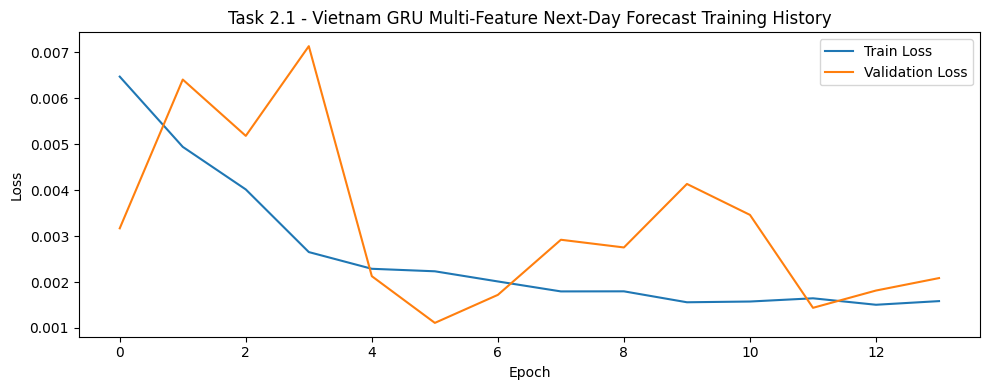

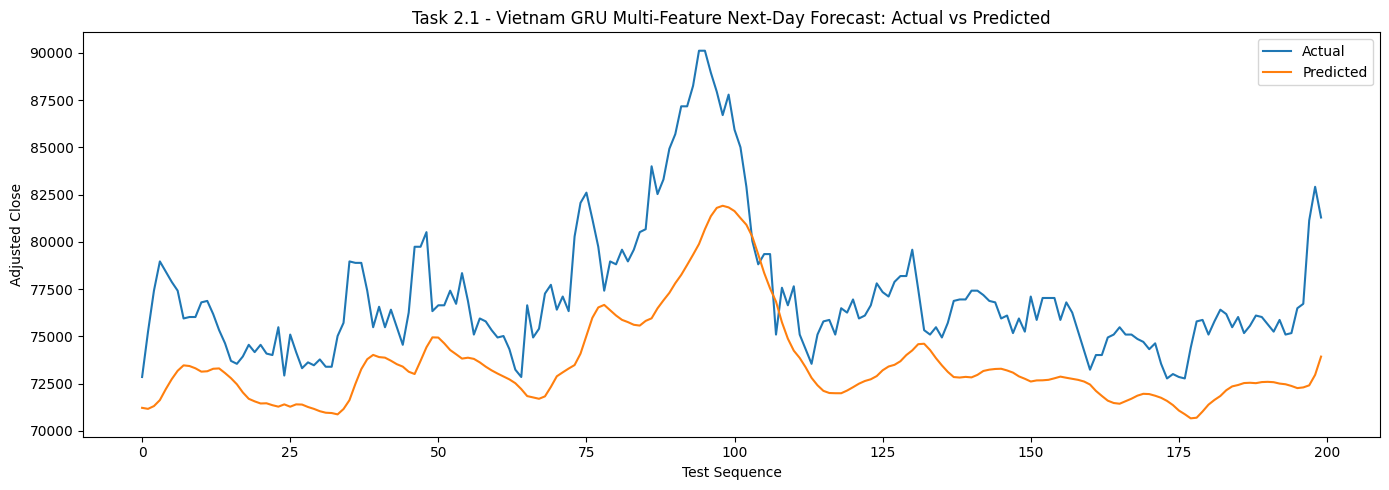

In [160]:
# Task 2.1: Vietnam Multi-Feature Next-Day Forecast
task_2_1_results = run_recurrent_forecast_experiment(
    experiment_name="Task 2.1 - Vietnam GRU Multi-Feature Next-Day Forecast",
    train_data=vietnam_train_df,
    val_data=vietnam_val_df,
    test_data=vietnam_test_df,
    feature_columns=VIETNAM_FEATURE_COLUMNS,
    target_column=VIETNAM_TARGET_COLUMN,
    lookback_days=VIETNAM_LOOKBACK_DAYS,
    forecast_horizon=1,
    multi_output=False,
    model_type=VIETNAM_MODEL_TYPE,
    epochs=VIETNAM_EPOCHS,
    batch_size=VIETNAM_BATCH_SIZE,
    patience=VIETNAM_PATIENCE,
    dropout_rate=VIETNAM_DROPOUT_RATE,
    recurrent_dropout_rate=VIETNAM_RECURRENT_DROPOUT_RATE,
    learning_rate=VIETNAM_LEARNING_RATE,
)

In [161]:
# Compare Task 2.1 Result vs. Baseline
compare_gru_vs_baselines(
    experiment_results=task_2_1_results,
    last_known_price=float(vietnam_val_df[VIETNAM_TARGET_COLUMN].iloc[-1]),
    experiment_label="Task 2.1 Vietnam",
)


  Task 2.1 Vietnam — GRU vs Naive Baselines


,Model,MAE,RMSE,sMAPE (%),R2,Directional Accuracy (%)
0,GRU (your model),4328.925467,4979.199875,5.528648,0.229111,44.204322
1,Persistent (naive),1032.078431,1409.475163,1.306311,0.938229,42.829077
2,Mean baseline,4349.075917,5671.052869,5.461132,0.000000,7.858546



Interpretation:
  ✓ GRU Directional Accuracy (44.2%) BEATS persistent baseline (42.8%) — model is learning real signal.
  ✗ GRU sMAPE (5.53%) worse than persistent (1.31%). Check for data leakage or scaling issues.



### Task 2.2: Vietnam 𝑘 day forecast

Epoch 1/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0070 - mae: 0.0839 - val_loss: 0.0079 - val_mae: 0.1039 - learning_rate: 3.0000e-04
Epoch 2/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0071 - mae: 0.0896 - val_loss: 0.0091 - val_mae: 0.1186 - learning_rate: 3.0000e-04
Epoch 3/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0034 - mae: 0.0586 - val_loss: 0.0120 - val_mae: 0.1416 - learning_rate: 3.0000e-04
Epoch 4/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0025 - mae: 0.0490 - val_loss: 0.0041 - val_mae: 0.0752 - learning_rate: 3.0000e-04
Epoch 5/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0025 - mae: 0.0483 - val_loss: 0.0056 - val_mae: 0.0926 - learning_rate: 3.0000e-04
Epoch 6/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0019 - mae: 0.0422 - val_loss: 0.0045 - val_mae: 0.0823 - learning_rate: 3.0000e-04
Epoch 7/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0020 - mae: 0.0413 - val_loss: 0.0042 - val_mae: 0.0787 - learning_ra

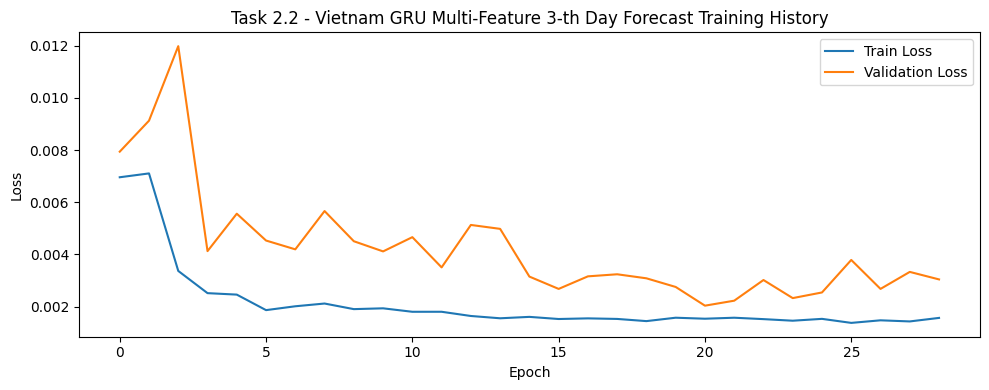

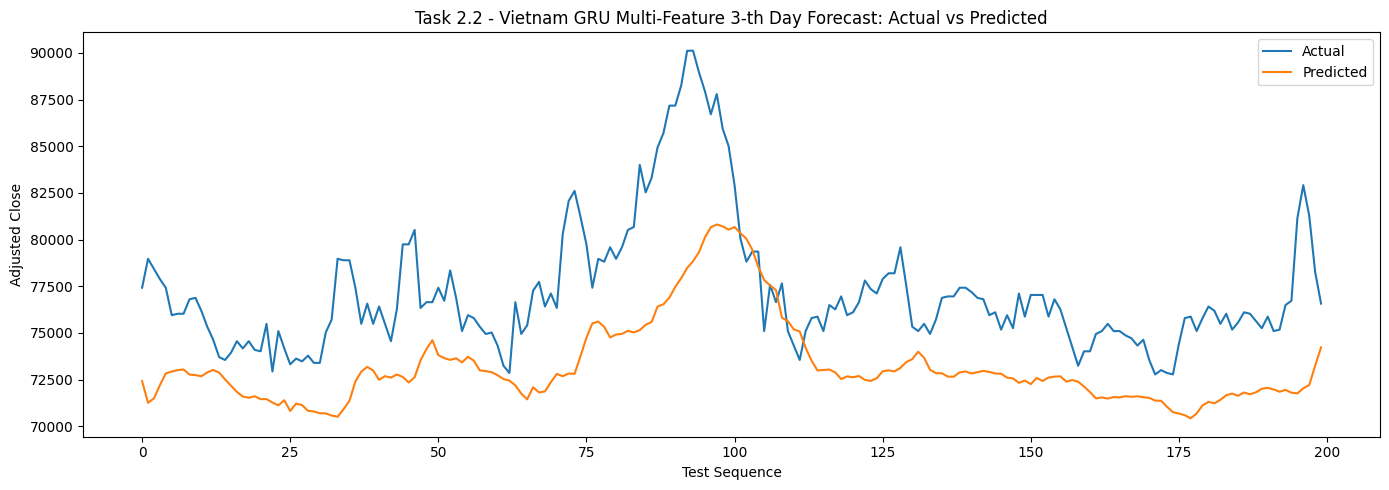

In [162]:
# Task 2.2: Vietnam Multi-Feature k-th Day Forecast
# Example: k = 3 means predict only the 3rd future day.
task_2_2_results = run_recurrent_forecast_experiment(
    experiment_name=f"Task 2.2 - Vietnam GRU Multi-Feature {VIETNAM_K_TH_DAY}-th Day Forecast",
    train_data=vietnam_train_df,
    val_data=vietnam_val_df,
    test_data=vietnam_test_df,
    feature_columns=VIETNAM_FEATURE_COLUMNS,
    target_column=VIETNAM_TARGET_COLUMN,
    lookback_days=VIETNAM_LOOKBACK_DAYS,
    forecast_horizon=VIETNAM_K_TH_DAY,
    multi_output=False,
    model_type=VIETNAM_MODEL_TYPE,
    epochs=VIETNAM_EPOCHS,
    batch_size=VIETNAM_BATCH_SIZE,
    patience=VIETNAM_PATIENCE,
    dropout_rate=VIETNAM_DROPOUT_RATE,
    recurrent_dropout_rate=VIETNAM_RECURRENT_DROPOUT_RATE,
    learning_rate=VIETNAM_LEARNING_RATE,
)

### Task 2.3: Vietnam 𝑘 days forecast

Epoch 1/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0108 - mae: 0.1057 - val_loss: 0.0341 - val_mae: 0.2264 - learning_rate: 3.0000e-04
Epoch 2/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0131 - mae: 0.1233 - val_loss: 0.0146 - val_mae: 0.1486 - learning_rate: 3.0000e-04
Epoch 3/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0064 - mae: 0.0810 - val_loss: 0.0131 - val_mae: 0.1390 - learning_rate: 3.0000e-04
Epoch 4/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0044 - mae: 0.0639 - val_loss: 0.0092 - val_mae: 0.1206 - learning_rate: 3.0000e-04
Epoch 5/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0042 - mae: 0.0604 - val_loss: 0.0092 - val_mae: 0.1180 - learning_rate: 3.0000e-04
Epoch 6/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0037 - mae: 0.0568 - val_loss: 0.0097 - val_mae: 0.1174 - learning_rate: 3.0000e-04
Epoch 7/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0035 - mae: 0.0550 - val_loss: 0.0101 - val_mae: 0.1268 - learning_ra

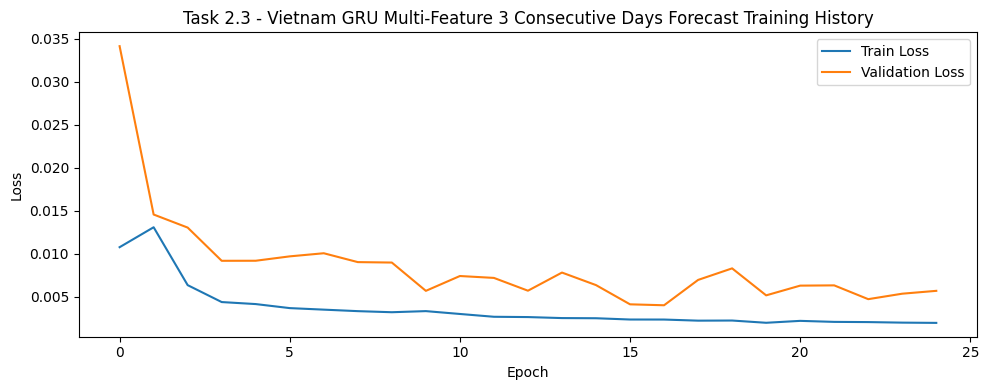

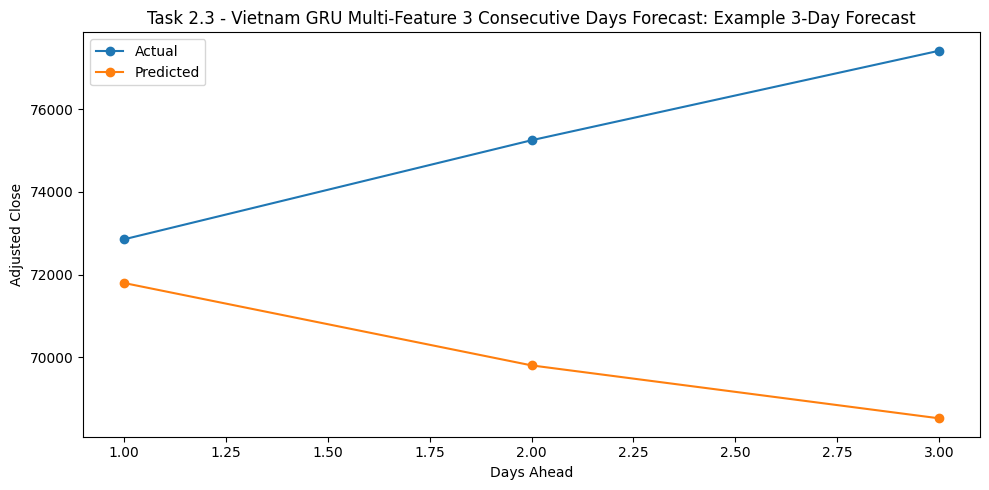

In [163]:
# Task 2.3: Vietnam Multi-Feature k Consecutive Days Forecast
# Example: k = 3 means predict day 1, day 2, and day 3 ahead.
task_2_3_results = run_recurrent_forecast_experiment(
    experiment_name=f"Task 2.3 - Vietnam GRU Multi-Feature {VIETNAM_K_CONSECUTIVE_DAYS} Consecutive Days Forecast",
    train_data=vietnam_train_df,
    val_data=vietnam_val_df,
    test_data=vietnam_test_df,
    feature_columns=VIETNAM_FEATURE_COLUMNS,
    target_column=VIETNAM_TARGET_COLUMN,
    lookback_days=VIETNAM_LOOKBACK_DAYS,
    forecast_horizon=VIETNAM_K_CONSECUTIVE_DAYS,
    multi_output=True,
    model_type=VIETNAM_MODEL_TYPE,
    epochs=VIETNAM_EPOCHS,
    batch_size=VIETNAM_BATCH_SIZE,
    patience=VIETNAM_PATIENCE,
    dropout_rate=VIETNAM_DROPOUT_RATE,
    recurrent_dropout_rate=VIETNAM_RECURRENT_DROPOUT_RATE,
    learning_rate=VIETNAM_LEARNING_RATE,
)

### Task 2: Summary

In [164]:
# Task 2.4: Final Task 2 Summary
task_2_summary = pd.DataFrame(
    [
        {
            "Task": "Task 2.1",
            "Ticker": VIETNAM_TICKER,
            "Model": VIETNAM_MODEL_TYPE.upper(),
            "Description": "Vietnam multi-feature next-day forecast",
            **task_2_1_results["metrics"],
        },
        {
            "Task": "Task 2.2",
            "Ticker": VIETNAM_TICKER,
            "Model": VIETNAM_MODEL_TYPE.upper(),
            "Description": f"Vietnam multi-feature {VIETNAM_K_TH_DAY}-th day forecast",
            **task_2_2_results["metrics"],
        },
        {
            "Task": "Task 2.3",
            "Ticker": VIETNAM_TICKER,
            "Model": VIETNAM_MODEL_TYPE.upper(),
            "Description": f"Vietnam multi-feature {VIETNAM_K_CONSECUTIVE_DAYS} consecutive days forecast",
            **task_2_3_results["metrics"],
        },
    ]
)

print("Final Task 2 Summary:")
display(task_2_summary)


Final Task 2 Summary:


,Task,Ticker,Model,Description,MAE,MSE,RMSE,MAPE,sMAPE,R2,Directional Accuracy
0,Task 2.1,VCB,GRU,Vietnam multi-feature next-day forecast,4328.925467,2.479243e+07,4979.199875,5.345246,5.528648,0.229111,44.204322
1,Task 2.2,VCB,GRU,Vietnam multi-feature 3-th day forecast,4688.445635,2.996656e+07,5474.172233,5.790545,6.010884,0.069040,45.364892
2,Task 2.3,VCB,GRU,Vietnam multi-feature 3 consecutive days forecast,7199.672231,6.336511e+07,7960.220600,8.951610,9.448875,-0.991118,45.305318


## Task 3: Trading signal identification for Vietnam market

### Task 3: Config & Setup

In [165]:
# Import metric libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

from sklearn.utils.class_weight import compute_class_weight

In [166]:
# Config
# Define missing Vietnam-specific constants first
VIETNAM_LOOKBACK_DAYS = 30
VIETNAM_DROPOUT_RATE = 0.3
VIETNAM_LEARNING_RATE = 3e-4
VIETNAM_PATIENCE = 8
VIETNAM_BATCH_SIZE = 32
VIETNAM_EPOCHS = 40

TASK3_SIGNAL_HORIZON = 5
TASK3_BUY_QUANTILE = 0.65
TASK3_SELL_QUANTILE = 0.35
TASK3_MIN_ABS_THRESHOLD = 0.005

TASK3_LOOKBACK_DAYS = VIETNAM_LOOKBACK_DAYS
TASK3_MODEL_TYPE = "gru"
TASK3_DROPOUT_RATE = VIETNAM_DROPOUT_RATE
TASK3_RECURRENT_DROPOUT_RATE = 0.00
TASK3_LEARNING_RATE = VIETNAM_LEARNING_RATE
TASK3_PATIENCE = VIETNAM_PATIENCE
TASK3_BATCH_SIZE = VIETNAM_BATCH_SIZE
TASK3_EPOCHS = VIETNAM_EPOCHS

In [167]:
# Technical Indicator Features
def compute_rsi(price: pd.Series, window: int = 14) -> pd.Series:
    price_change = price.diff()
    gain = price_change.clip(lower=0)
    loss = -price_change.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    relative_strength = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + relative_strength))

    return rsi


def add_trading_signal_features(
    data: "pd.DataFrame",
    date_column: str,
    target_column: str,
) -> "pd.DataFrame":
    """
    Extended feature set for trading signal classification.
    Adds Bollinger Bands and ATR on top of the original features.
    These are standard technical indicators used by traders:
      - Bollinger Bands: identify overbought/oversold conditions
      - ATR: measure volatility / stop-loss distance
      - OBV: on-balance volume confirms breakouts
    """
    import numpy as np
    import pandas as pd

    signal_data = data.copy()
    signal_data = signal_data.sort_values(date_column).reset_index(drop=True)

    # --- Original features (keep all) ---
    signal_data["Return1"] = signal_data[target_column].pct_change()
    signal_data["Return3"] = signal_data[target_column].pct_change(periods=3)
    signal_data["Return5"] = signal_data[target_column].pct_change(periods=5)

    signal_data["SMA5"]  = signal_data[target_column].rolling(window=5).mean()
    signal_data["SMA10"] = signal_data[target_column].rolling(window=10).mean()
    signal_data["SMA20"] = signal_data[target_column].rolling(window=20).mean()

    signal_data["EMA12"] = signal_data[target_column].ewm(span=12, adjust=False).mean()
    signal_data["EMA26"] = signal_data[target_column].ewm(span=26, adjust=False).mean()
    signal_data["MACD"]           = signal_data["EMA12"] - signal_data["EMA26"]
    signal_data["MACD Signal"]    = signal_data["MACD"].ewm(span=9, adjust=False).mean()
    signal_data["MACD Histogram"] = signal_data["MACD"] - signal_data["MACD Signal"]

    signal_data["RSI14"] = compute_rsi(signal_data[target_column], window=14)

    signal_data["Volatility5"]  = signal_data["Return1"].rolling(window=5).std()
    signal_data["Volatility10"] = signal_data["Return1"].rolling(window=10).std()
    signal_data["Momentum5"]  = signal_data[target_column] / signal_data[target_column].shift(5) - 1
    signal_data["Momentum10"] = signal_data[target_column] / signal_data[target_column].shift(10) - 1

    signal_data["Volume Change"] = signal_data["Volume"].pct_change()
    signal_data["Price Range"] = (signal_data["High"] - signal_data["Low"]) / signal_data[target_column]
    signal_data["Close Position"] = (
        (signal_data[target_column] - signal_data["Low"])
        / (signal_data["High"] - signal_data["Low"]).replace(0, np.nan)
    )

    # --- NEW: Bollinger Bands (20-day, 2 std) ---
    bb_mid   = signal_data[target_column].rolling(window=20).mean()
    bb_std   = signal_data[target_column].rolling(window=20).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    # Position within band [0=lower, 0.5=mid, 1=upper]
    signal_data["BB Width"] = (bb_upper - bb_lower) / bb_mid.replace(0, np.nan)
    signal_data["BB Position"] = (
        (signal_data[target_column] - bb_lower)
        / (bb_upper - bb_lower).replace(0, np.nan)
    ).clip(0, 1)

    # --- NEW: Average True Range (ATR-14) — volatility/stop-loss measure ---
    prev_close = signal_data[target_column].shift(1)
    true_range = pd.concat([
        signal_data["High"] - signal_data["Low"],
        (signal_data["High"] - prev_close).abs(),
        (signal_data["Low"]  - prev_close).abs(),
    ], axis=1).max(axis=1)
    signal_data["ATR14"] = true_range.rolling(window=14).mean()
    # Normalize ATR by price so it is scale-independent
    signal_data["ATR14 Ratio"] = signal_data["ATR14"] / signal_data[target_column].replace(0, np.nan)

    # --- NEW: On-Balance Volume (OBV) — volume momentum ---
    direction = np.sign(signal_data[target_column].diff().fillna(0))
    signal_data["OBV"] = (direction * signal_data["Volume"]).cumsum()
    signal_data["OBV Change"] = signal_data["OBV"].pct_change()

    signal_data = signal_data.replace([np.inf, -np.inf], np.nan)
    return signal_data


def add_future_return_column(
    data: pd.DataFrame,
    target_column: str,
    horizon: int,
) -> pd.DataFrame:
    labeled_data = data.copy()
    labeled_data["Future Close"] = labeled_data[target_column].shift(-horizon)
    labeled_data["Future Return"] = (
        labeled_data["Future Close"] / labeled_data[target_column] - 1
    )

    return labeled_data


def calculate_dynamic_signal_thresholds(
    train_data: pd.DataFrame,
    target_column: str,
    horizon: int,
    buy_quantile: float = 0.65,
    sell_quantile: float = 0.35,
    min_abs_threshold: float = 0.005,
) -> tuple[float, float]:
    threshold_data = add_future_return_column(
        data=train_data,
        target_column=target_column,
        horizon=horizon,
    )

    future_returns = threshold_data["Future Return"].dropna()

    if future_returns.empty:
        raise ValueError("No future returns available for threshold calculation.")

    buy_threshold = max(
        float(future_returns.quantile(buy_quantile)),
        min_abs_threshold,
    )

    sell_threshold = max(
        abs(float(future_returns.quantile(sell_quantile))),
        min_abs_threshold,
    )

    return buy_threshold, sell_threshold


def add_trading_signal_labels(
    data: pd.DataFrame,
    target_column: str,
    horizon: int,
    buy_threshold: float,
    sell_threshold: float,
) -> pd.DataFrame:
    labeled_data = add_future_return_column(
        data=data,
        target_column=target_column,
        horizon=horizon,
    )

    labeled_data["Buy Signal"] = (
        labeled_data["Future Return"] >= buy_threshold
    ).astype(float)

    labeled_data["Sell Signal"] = (
        labeled_data["Future Return"] <= -sell_threshold
    ).astype(float)

    labeled_data.loc[labeled_data["Future Return"].isna(), ["Buy Signal", "Sell Signal"]] = np.nan

    return labeled_data

### Task 3: Data Preparation

In [168]:
# Prepare Vietnam Signal Dataset
task3_base_df = add_trading_signal_features(
    data=vietnam_df,
    date_column=VIETNAM_DATE_COLUMN,
    target_column=VIETNAM_TARGET_COLUMN,
)

TASK3_FEATURE_COLUMNS = [
    "Open", "High", "Low", "Close", "Volume",
    "Log Return", "MA10", "MA20",
    "Return1", "Return3", "Return5",
    "SMA5", "SMA10", "SMA20",
    "EMA12", "EMA26",
    "MACD", "MACD Signal", "MACD Histogram",
    "RSI14",
    "Volatility5", "Volatility10",
    "Momentum5", "Momentum10",
    "Volume Change", "Price Range", "Close Position",
    # New
    "BB Width", "BB Position",
    "ATR14 Ratio",
    "OBV Change",
]

TASK3_FEATURE_COLUMNS = [
    column for column in TASK3_FEATURE_COLUMNS
    if column in task3_base_df.columns
]

task3_base_df = task3_base_df.dropna(
    subset=[VIETNAM_DATE_COLUMN, VIETNAM_TARGET_COLUMN] + TASK3_FEATURE_COLUMNS
).reset_index(drop=True)

task3_train_base_df, task3_val_base_df, task3_test_base_df = chronological_train_val_test_split(
    data=task3_base_df,
    train_ratio=VIETNAM_TRAIN_RATIO,
    val_ratio=VIETNAM_VAL_RATIO,
)

TASK3_BUY_THRESHOLD, TASK3_SELL_THRESHOLD = calculate_dynamic_signal_thresholds(
    train_data=task3_train_base_df,
    target_column=VIETNAM_TARGET_COLUMN,
    horizon=TASK3_SIGNAL_HORIZON,
    buy_quantile=TASK3_BUY_QUANTILE,
    sell_quantile=TASK3_SELL_QUANTILE,
    min_abs_threshold=TASK3_MIN_ABS_THRESHOLD,
)

print(f"Task 3 selected Vietnam ticker: {VIETNAM_TICKER}")
print(f"Task 3 signal horizon: {TASK3_SIGNAL_HORIZON} trading days")
print(f"Buy threshold: future return >= {TASK3_BUY_THRESHOLD:.4%}")
print(f"Sell threshold: future return <= -{TASK3_SELL_THRESHOLD:.4%}")

Task 3 selected Vietnam ticker: VCB
Task 3 signal horizon: 5 trading days
Buy threshold: future return >= 1.4704%
Sell threshold: future return <= -1.3563%


In [169]:
task3_train_df = add_trading_signal_labels(
    data=task3_train_base_df,
    target_column=VIETNAM_TARGET_COLUMN,
    horizon=TASK3_SIGNAL_HORIZON,
    buy_threshold=TASK3_BUY_THRESHOLD,
    sell_threshold=TASK3_SELL_THRESHOLD,
)

task3_val_df = add_trading_signal_labels(
    data=task3_val_base_df,
    target_column=VIETNAM_TARGET_COLUMN,
    horizon=TASK3_SIGNAL_HORIZON,
    buy_threshold=TASK3_BUY_THRESHOLD,
    sell_threshold=TASK3_SELL_THRESHOLD,
)

task3_test_df = add_trading_signal_labels(
    data=task3_test_base_df,
    target_column=VIETNAM_TARGET_COLUMN,
    horizon=TASK3_SIGNAL_HORIZON,
    buy_threshold=TASK3_BUY_THRESHOLD,
    sell_threshold=TASK3_SELL_THRESHOLD,
)

signal_distribution = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Rows": len(task3_train_df),
            "Buy Positive Ratio": task3_train_df["Buy Signal"].mean(),
            "Sell Positive Ratio": task3_train_df["Sell Signal"].mean(),
        },
        {
            "Split": "Validation",
            "Rows": len(task3_val_df),
            "Buy Positive Ratio": task3_val_df["Buy Signal"].mean(),
            "Sell Positive Ratio": task3_val_df["Sell Signal"].mean(),
        },
        {
            "Split": "Test",
            "Rows": len(task3_test_df),
            "Buy Positive Ratio": task3_test_df["Buy Signal"].mean(),
            "Sell Positive Ratio": task3_test_df["Sell Signal"].mean(),
        },
    ]
)

display(signal_distribution)

,Split,Rows,Buy Positive Ratio,Sell Positive Ratio
0,Train,2359,0.350042,0.350467
1,Validation,505,0.390000,0.228000
2,Test,506,0.331337,0.323353


In [170]:
def run_task3_signal_cv(
    base_df: "pd.DataFrame",
    feature_columns: list,
    label_column: str,
    lookback_days: int,
    n_splits: int = 3,
    epochs: int = 20,
    batch_size: int = 32,
    patience: int = 5,
    dropout_rate: float = 0.25,
    learning_rate: float = 3e-4,
    buy_quantile: float = 0.65,
    sell_quantile: float = 0.35,
    signal_horizon: int = 5,
    min_abs_threshold: float = 0.005,
) -> "pd.DataFrame":
    """
    Time-series CV for Task 3 classification model.
    Each fold recomputes thresholds from its training window only,
    preventing any future-return leakage across folds.
    """
    import numpy as np
    import pandas as pd
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
    import tensorflow as tf

    splitter = TimeSeriesSplit(n_splits=n_splits)
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(splitter.split(base_df), start=1):
        fold_train = base_df.iloc[train_idx].copy()
        fold_val   = base_df.iloc[val_idx].copy()

        if len(fold_train) <= lookback_days + signal_horizon:
            print(f"  Fold {fold_idx}: skipped (too few rows)")
            continue

        # Recompute thresholds on this fold's training data only
        buy_thr, sell_thr = calculate_dynamic_signal_thresholds(
            train_data=fold_train,
            target_column=VIETNAM_TARGET_COLUMN,
            horizon=signal_horizon,
            buy_quantile=buy_quantile,
            sell_quantile=sell_quantile,
            min_abs_threshold=min_abs_threshold,
        )

        fold_train_lbl = add_trading_signal_labels(
            data=fold_train, target_column=VIETNAM_TARGET_COLUMN,
            horizon=signal_horizon, buy_threshold=buy_thr, sell_threshold=sell_thr,
        )
        fold_val_lbl = add_trading_signal_labels(
            data=fold_val, target_column=VIETNAM_TARGET_COLUMN,
            horizon=signal_horizon, buy_threshold=buy_thr, sell_threshold=sell_thr,
        )

        fold_train_clean = fold_train_lbl.dropna(subset=feature_columns + [label_column]).copy()
        fold_val_clean   = fold_val_lbl.dropna(subset=feature_columns + [label_column]).copy()

        feature_scaler = fit_signal_feature_scaler(fold_train_clean, feature_columns)

        x_tr, y_tr = make_signal_sequences_from_split(
            current_data=fold_train_clean, feature_columns=feature_columns,
            label_column=label_column, lookback_days=lookback_days,
            feature_scaler=feature_scaler, previous_context_data=None,
        )
        x_vl, y_vl = make_signal_sequences_from_split(
            current_data=fold_val_clean, feature_columns=feature_columns,
            label_column=label_column, lookback_days=lookback_days,
            feature_scaler=feature_scaler, previous_context_data=fold_train_clean,
        )

        if len(x_tr) < 10 or len(x_vl) < 5:
            print(f"  Fold {fold_idx}: skipped (insufficient sequences)")
            continue

        tf.keras.backend.clear_session()
        model = build_gru_signal_classifier(
            input_shape=(lookback_days, len(feature_columns)),
            dropout_rate=dropout_rate,
            learning_rate=learning_rate,
        )

        class_weights = make_binary_class_weights(y_tr)

        model.fit(
            x_tr, y_tr,
            validation_data=(x_vl, y_vl),
            epochs=epochs, batch_size=batch_size,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_loss", patience=patience,
                    restore_best_weights=True, verbose=0,
                )
            ],
            class_weight=class_weights,
            verbose=0, shuffle=False,
        )

        val_prob = model.predict(x_vl, verbose=0).reshape(-1)
        val_pred = (val_prob >= 0.5).astype(int)

        auc = roc_auc_score(y_vl, val_prob) if len(np.unique(y_vl)) == 2 else float("nan")

        fold_results.append({
            "Fold": fold_idx,
            "Signal": label_column,
            "Train Rows": len(x_tr),
            "Val Rows": len(x_vl),
            "Positive Rate": float(y_vl.mean()),
            "F1": f1_score(y_vl, val_pred, zero_division=0),
            "Precision": precision_score(y_vl, val_pred, zero_division=0),
            "Recall": recall_score(y_vl, val_pred, zero_division=0),
            "ROC AUC": auc,
            "Buy Threshold": buy_thr,
            "Sell Threshold": sell_thr,
        })
        print(f"  Fold {fold_idx} done — F1={fold_results[-1]['F1']:.3f}, AUC={fold_results[-1]['ROC AUC']:.3f}")

    return pd.DataFrame(fold_results)

### Task 3: Signal Sequence Preparation

In [171]:
from sklearn.preprocessing import RobustScaler

def fit_signal_feature_scaler(
    train_data: "pd.DataFrame",
    feature_columns: list,
) -> "RobustScaler":
    """
    RobustScaler uses median + IQR instead of min-max.
    Technical indicators (RSI, MACD, ATR) contain outliers that compress
    MinMaxScaler's range — RobustScaler handles this much better.
    """
    feature_scaler = RobustScaler()
    feature_scaler.fit(train_data[feature_columns])
    return feature_scaler


def make_signal_sequences_from_split(
    current_data: pd.DataFrame,
    feature_columns: list[str],
    label_column: str,
    lookback_days: int,
    feature_scaler: MinMaxScaler,
    previous_context_data: pd.DataFrame | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    if previous_context_data is not None and len(previous_context_data) > 0:
        context_data = previous_context_data.tail(max(lookback_days - 1, 0))
        model_data = pd.concat([context_data, current_data], axis=0).reset_index(drop=True)
        context_length = len(context_data)
    else:
        model_data = current_data.copy().reset_index(drop=True)
        context_length = 0

    x_scaled = feature_scaler.transform(model_data[feature_columns])
    labels = model_data[label_column].to_numpy()

    x_sequences = []
    y_labels = []

    max_start = len(model_data) - lookback_days + 1

    if max_start <= 0:
        raise ValueError(
            f"Not enough rows to create signal sequences. "
            f"Rows={len(model_data)}, lookback_days={lookback_days}."
        )

    for start_index in range(max_start):
        current_index = start_index + lookback_days - 1

        if current_index < context_length:
            continue

        label_value = labels[current_index]

        if pd.isna(label_value):
            continue

        x_sequences.append(x_scaled[start_index: current_index + 1])
        y_labels.append(int(label_value))

    return np.asarray(x_sequences), np.asarray(y_labels)


def prepare_signal_train_val_test_sequences(
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    test_data: pd.DataFrame,
    feature_columns: list[str],
    label_column: str,
    lookback_days: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    feature_scaler = fit_signal_feature_scaler(
        train_data=train_data,
        feature_columns=feature_columns,
    )

    x_train, y_train = make_signal_sequences_from_split(
        current_data=train_data,
        feature_columns=feature_columns,
        label_column=label_column,
        lookback_days=lookback_days,
        feature_scaler=feature_scaler,
        previous_context_data=None,
    )

    x_val, y_val = make_signal_sequences_from_split(
        current_data=val_data,
        feature_columns=feature_columns,
        label_column=label_column,
        lookback_days=lookback_days,
        feature_scaler=feature_scaler,
        previous_context_data=train_data,
    )

    train_val_data = pd.concat([train_data, val_data], axis=0).reset_index(drop=True)

    x_test, y_test = make_signal_sequences_from_split(
        current_data=test_data,
        feature_columns=feature_columns,
        label_column=label_column,
        lookback_days=lookback_days,
        feature_scaler=feature_scaler,
        previous_context_data=train_val_data,
    )

    return x_train, y_train, x_val, y_val, x_test, y_test

### Task 3: GRU-Classifier

In [198]:
# Task 3.4: GRU Signal Classifier
def build_gru_signal_classifier(
    input_shape: tuple[int, int],
    first_units: int = 32,
    second_units: int = 16,
    dropout_rate: float = 0.25,
    recurrent_dropout_rate: float = 0.00,
    learning_rate: float = 3e-4,
) -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.GRU(
                first_units,
                return_sequences=True,
                recurrent_dropout=recurrent_dropout_rate,
            ),
            layers.Dropout(dropout_rate),
            layers.GRU(
                second_units,
                recurrent_dropout=recurrent_dropout_rate,
            ),
            layers.Dropout(dropout_rate),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="GRU_trading_signal_classifier",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )

    return model


def make_binary_class_weights(y_train: np.ndarray) -> dict[int, float]:
    classes = np.unique(y_train)

    if len(classes) < 2:
        return {int(classes[0]): 1.0}

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    return {
        int(class_label): float(class_weight)
        for class_label, class_weight in zip(classes, weights)
    }


def tune_probability_threshold(
    y_true: np.ndarray,
    y_probability: np.ndarray,
    metric_name: str = "f1",
    min_predicted_positive_ratio: float = 0.05,
    max_predicted_positive_ratio: float = 0.50,
) -> tuple[float, pd.DataFrame]:
    threshold_rows = []

    for threshold in np.arange(0.10, 0.91, 0.01):
        y_pred = (y_probability >= threshold).astype(int)

        predicted_positive_ratio = float(np.mean(y_pred))

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        accuracy = accuracy_score(y_true, y_pred)

        balanced_score = (
            0.45 * f1
            + 0.25 * precision
            + 0.20 * recall
            + 0.10 * accuracy
        )

        is_valid_ratio = (
            min_predicted_positive_ratio
            <= predicted_positive_ratio
            <= max_predicted_positive_ratio
        )

        threshold_rows.append(
            {
                "Threshold": float(threshold),
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "Balanced Score": balanced_score,
                "Predicted Positive Ratio": predicted_positive_ratio,
                "Valid Ratio": is_valid_ratio,
            }
        )

    threshold_df = pd.DataFrame(threshold_rows)

    valid_threshold_df = threshold_df[threshold_df["Valid Ratio"]].copy()

    if valid_threshold_df.empty:
        valid_threshold_df = threshold_df.copy()

    sort_column = {
        "f1": "F1",
        "precision": "Precision",
        "recall": "Recall",
        "accuracy": "Accuracy",
        "balanced": "Balanced Score",
    }.get(metric_name, "Balanced Score")

    valid_threshold_df = valid_threshold_df.sort_values(
        by=[sort_column, "Precision", "F1"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    best_threshold = float(valid_threshold_df.iloc[0]["Threshold"])

    threshold_df = threshold_df.sort_values(
        by=["Valid Ratio", sort_column, "Precision", "F1"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

    return best_threshold, threshold_df


def classification_metrics_table(
    y_true: np.ndarray,
    y_probability: np.ndarray,
    threshold: float,
    model_name: str,
) -> pd.DataFrame:
    y_pred = (y_probability >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Positive Ratio": float(np.mean(y_true)),
        "Predicted Positive Ratio": float(np.mean(y_pred)),
    }

    if len(np.unique(y_true)) == 2:
        metrics["ROC AUC"] = roc_auc_score(y_true, y_probability)
        metrics["PR AUC"] = average_precision_score(y_true, y_probability)
    else:
        metrics["ROC AUC"] = np.nan
        metrics["PR AUC"] = np.nan

    return pd.DataFrame([metrics])

def plot_signal_training_history(
    history: keras.callbacks.History,
    title: str,
) -> None:
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(10, 4))
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Binary Crossentropy")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_signal_probabilities(
    y_true: np.ndarray,
    y_probability: np.ndarray,
    threshold: float,
    title: str,
    max_points: int = 200,
) -> None:
    points = min(len(y_true), max_points)

    plt.figure(figsize=(14, 5))
    plt.plot(y_probability[:points], label="Predicted Signal Probability")
    plt.plot(y_true[:points], label="Actual Signal", alpha=0.75)
    plt.axhline(threshold, linestyle="--", label=f"Threshold = {threshold:.2f}")
    plt.title(title)
    plt.xlabel("Test Sequence")
    plt.ylabel("Probability / Label")
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_trading_signal_experiment(
    experiment_name: str,
    label_column: str,
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    test_data: pd.DataFrame,
    feature_columns: list[str],
    lookback_days: int,
    epochs: int,
    batch_size: int,
    patience: int,
    dropout_rate: float,
    recurrent_dropout_rate: float,
    learning_rate: float,
) -> dict[str, object]:
    x_train, y_train, x_val, y_val, x_test, y_test = prepare_signal_train_val_test_sequences(
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        feature_columns=feature_columns,
        label_column=label_column,
        lookback_days=lookback_days,
    )

    print(f"\n{experiment_name}")
    print(f"Train sequences: {x_train.shape}, positive ratio: {y_train.mean():.4f}")
    print(f"Validation sequences: {x_val.shape}, positive ratio: {y_val.mean():.4f}")
    print(f"Test sequences: {x_test.shape}, positive ratio: {y_test.mean():.4f}")

    model = build_gru_signal_classifier(
        input_shape=(lookback_days, len(feature_columns)),
        dropout_rate=dropout_rate,
        recurrent_dropout_rate=recurrent_dropout_rate,
        learning_rate=learning_rate,
    )

    class_weights = make_binary_class_weights(y_train)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(3, patience // 2),
            min_lr=1e-6,
            verbose=0,
        ),
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=0,
        shuffle=False,
    )

    val_probability = model.predict(x_val, verbose=0).reshape(-1)
    test_probability = model.predict(x_test, verbose=0).reshape(-1)

    best_threshold, threshold_df = tune_probability_threshold(
        y_true=y_val,
        y_probability=val_probability,
        metric_name="f1",
    )

    validation_metrics = classification_metrics_table(
        y_true=y_val,
        y_probability=val_probability,
        threshold=best_threshold,
        model_name=f"{experiment_name} Validation",
    )

    test_metrics = classification_metrics_table(
        y_true=y_test,
        y_probability=test_probability,
        threshold=best_threshold,
        model_name=f"{experiment_name} Test",
    )

    print("Best validation threshold:")
    print(best_threshold)

    print("\nValidation metrics:")
    display(validation_metrics)

    print("\nTest metrics:")
    display(test_metrics)

    test_pred = (test_probability >= best_threshold).astype(int)

    print("\nTest classification report:")
    print(classification_report(y_test, test_pred, digits=4, zero_division=0))

    print("Test confusion matrix:")
    display(
        pd.DataFrame(
            confusion_matrix(y_test, test_pred),
            index=["Actual 0", "Actual 1"],
            columns=["Predicted 0", "Predicted 1"],
        )
    )

    plot_signal_training_history(
        history=history,
        title=f"{experiment_name} Training History",
    )

    plot_signal_probabilities(
        y_true=y_test,
        y_probability=test_probability,
        threshold=best_threshold,
        title=f"{experiment_name}: Test Signal Probability",
    )

    return {
        "experiment_name": experiment_name,
        "label_column": label_column,
        "model": model,
        "history": history,
        "best_threshold": best_threshold,
        "threshold_df": threshold_df,
        "validation_metrics": validation_metrics,
        "test_metrics": test_metrics,
        "x_test": x_test,
        "y_test": y_test,
        "test_probability": test_probability,
        "test_pred": test_pred,
    }

### Task 3.1: Buying signal identification

In [199]:
# Buying Signal Identification
print("Task 3.1 Buy Signal — Time-Series CV")
task3_buy_cv_results = run_task3_signal_cv(
    base_df=task3_base_df,
    feature_columns=TASK3_FEATURE_COLUMNS,
    label_column="Buy Signal",
    lookback_days=TASK3_LOOKBACK_DAYS,
    n_splits=3,
    epochs=TASK3_EPOCHS,
    batch_size=TASK3_BATCH_SIZE,
    patience=TASK3_PATIENCE,
    dropout_rate=TASK3_DROPOUT_RATE,
    learning_rate=TASK3_LEARNING_RATE,
    signal_horizon=TASK3_SIGNAL_HORIZON,
)
display(task3_buy_cv_results)

Task 3.1 Buy Signal — Time-Series CV
  Fold 1 done — F1=0.214, AUC=0.555
  Fold 2 done — F1=0.219, AUC=0.497
  Fold 3 done — F1=0.464, AUC=0.503


,Fold,Signal,Train Rows,Val Rows,Positive Rate,F1,Precision,Recall,ROC AUC,Buy Threshold,Sell Threshold
0,1,Buy Signal,810,837,0.399044,0.213777,0.517241,0.134731,0.554731,0.010850,0.020207
1,2,Buy Signal,1652,837,0.393070,0.219114,0.470000,0.142857,0.497062,0.013854,0.015111
2,3,Buy Signal,2494,837,0.348865,0.464246,0.341977,0.722603,0.502532,0.015184,0.012232



Task 3.1 - Vietnam Buy Signal
Train sequences: (2325, 30, 31), positive ratio: 0.3514
Validation sequences: (500, 30, 31), positive ratio: 0.3900
Test sequences: (501, 30, 31), positive ratio: 0.3313
Best validation threshold:
0.3899999999999999

Validation metrics:


,Model,Threshold,Accuracy,Precision,Recall,F1,Positive Ratio,Predicted Positive Ratio,ROC AUC,PR AUC
0,Task 3.1 - Vietnam Buy Signal Validation,0.39,0.568,0.454936,0.54359,0.495327,0.39,0.466,0.584615,0.456396



Test metrics:


,Model,Threshold,Accuracy,Precision,Recall,F1,Positive Ratio,Predicted Positive Ratio,ROC AUC,PR AUC
0,Task 3.1 - Vietnam Buy Signal Test,0.39,0.453094,0.309859,0.53012,0.391111,0.331337,0.566866,0.464215,0.299501



Test classification report:
              precision    recall  f1-score   support

           0     0.6406    0.4149    0.5036       335
           1     0.3099    0.5301    0.3911       166

    accuracy                         0.4531       501
   macro avg     0.4752    0.4725    0.4474       501
weighted avg     0.5310    0.4531    0.4663       501

Test confusion matrix:


,Predicted 0,Predicted 1
Actual 0,139,196
Actual 1,78,88


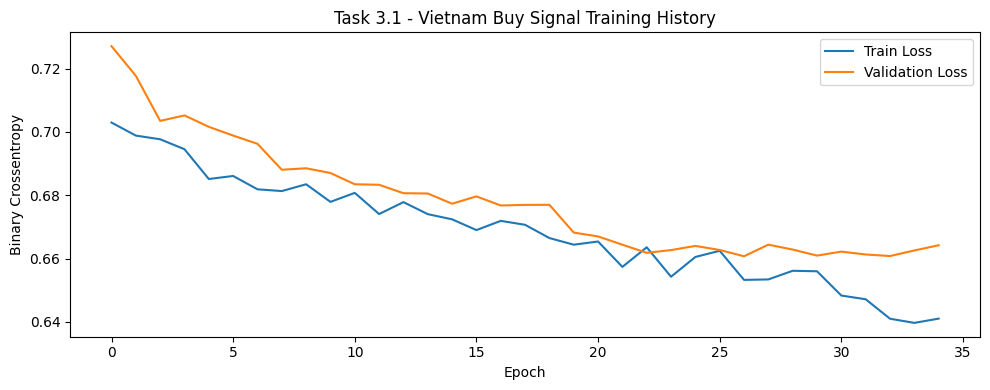

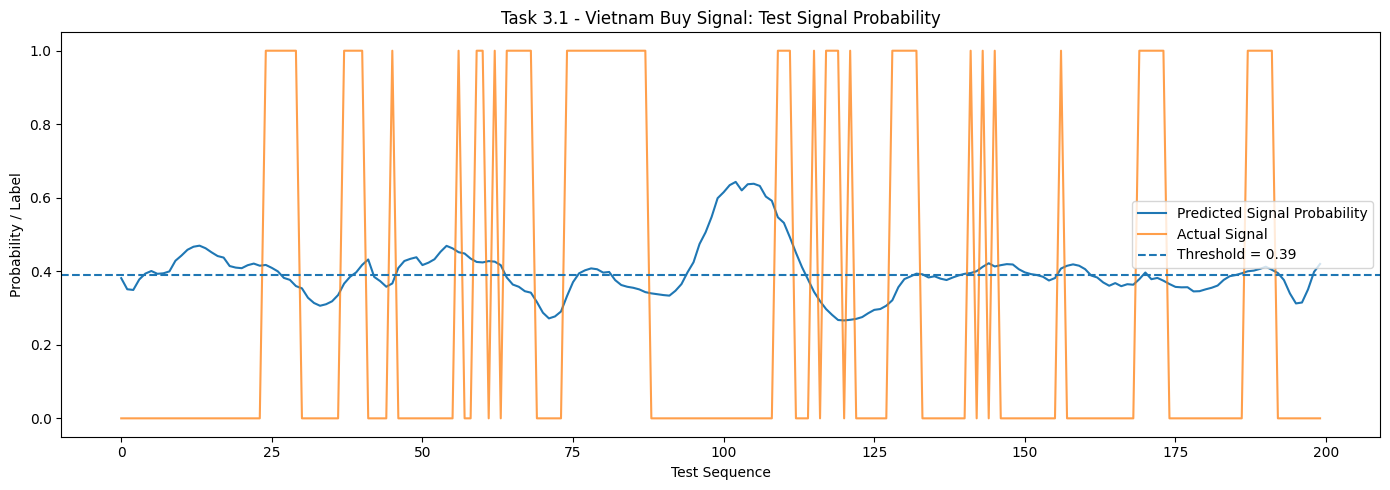

In [200]:
# Execute Task 3.1 Buy Signal Experiment
task_3_1_buy_results = run_trading_signal_experiment(
    experiment_name="Task 3.1 - Vietnam Buy Signal",
    label_column="Buy Signal",
    train_data=task3_train_df,
    val_data=task3_val_df,
    test_data=task3_test_df,
    feature_columns=TASK3_FEATURE_COLUMNS,
    lookback_days=TASK3_LOOKBACK_DAYS,
    epochs=TASK3_EPOCHS,
    batch_size=TASK3_BATCH_SIZE,
    patience=TASK3_PATIENCE,
    dropout_rate=TASK3_DROPOUT_RATE,
    recurrent_dropout_rate=TASK3_RECURRENT_DROPOUT_RATE,
    learning_rate=TASK3_LEARNING_RATE,
)

### Task 3.2: Selling signal identification

In [201]:
# Selling Signal Identification
print("Task 3.2 Sell Signal — Time-Series CV")
task3_sell_cv_results = run_task3_signal_cv(
    base_df=task3_base_df,
    feature_columns=TASK3_FEATURE_COLUMNS,
    label_column="Sell Signal",
    lookback_days=TASK3_LOOKBACK_DAYS,
    n_splits=3,
    epochs=TASK3_EPOCHS,
    batch_size=TASK3_BATCH_SIZE,
    patience=TASK3_PATIENCE,
    dropout_rate=TASK3_DROPOUT_RATE,
    learning_rate=TASK3_LEARNING_RATE,
    signal_horizon=TASK3_SIGNAL_HORIZON,
)
display(task3_sell_cv_results)

Task 3.2 Sell Signal — Time-Series CV
  Fold 1 done — F1=0.398, AUC=0.541
  Fold 2 done — F1=0.300, AUC=0.451
  Fold 3 done — F1=0.177, AUC=0.547


,Fold,Signal,Train Rows,Val Rows,Positive Rate,F1,Precision,Recall,ROC AUC,Buy Threshold,Sell Threshold
0,1,Sell Signal,810,837,0.244922,0.397980,0.250955,0.960976,0.540877,0.010850,0.020207
1,2,Sell Signal,1652,837,0.267622,0.300188,0.258900,0.357143,0.450507,0.013854,0.015111
2,3,Sell Signal,2494,837,0.310633,0.176991,0.379747,0.115385,0.546900,0.015184,0.012232



Task 3.2 - Vietnam Sell Signal
Train sequences: (2325, 30, 31), positive ratio: 0.3480
Validation sequences: (500, 30, 31), positive ratio: 0.2280
Test sequences: (501, 30, 31), positive ratio: 0.3234
Best validation threshold:
0.46999999999999986

Validation metrics:


,Model,Threshold,Accuracy,Precision,Recall,F1,Positive Ratio,Predicted Positive Ratio,ROC AUC,PR AUC
0,Task 3.2 - Vietnam Sell Signal Validation,0.47,0.592,0.307692,0.631579,0.413793,0.228,0.468,0.62258,0.353916



Test metrics:


,Model,Threshold,Accuracy,Precision,Recall,F1,Positive Ratio,Predicted Positive Ratio,ROC AUC,PR AUC
0,Task 3.2 - Vietnam Sell Signal Test,0.47,0.516966,0.358156,0.623457,0.454955,0.323353,0.562874,0.551094,0.341007



Test classification report:
              precision    recall  f1-score   support

           0     0.7215    0.4661    0.5663       339
           1     0.3582    0.6235    0.4550       162

    accuracy                         0.5170       501
   macro avg     0.5398    0.5448    0.5106       501
weighted avg     0.6040    0.5170    0.5303       501

Test confusion matrix:


,Predicted 0,Predicted 1
Actual 0,158,181
Actual 1,61,101


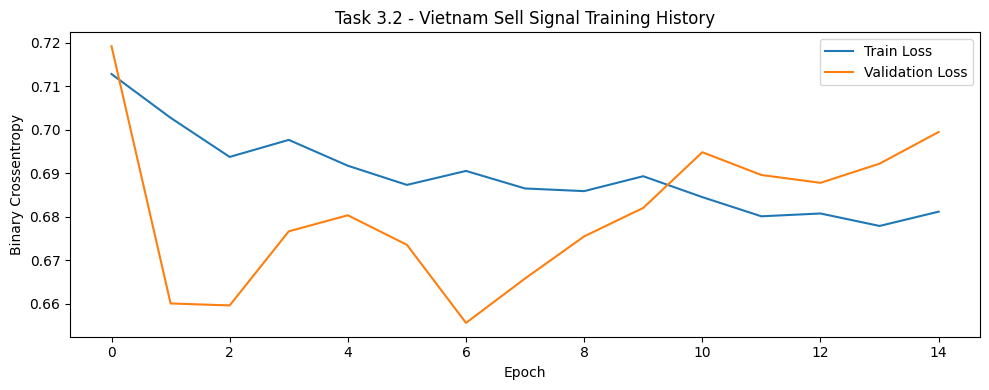

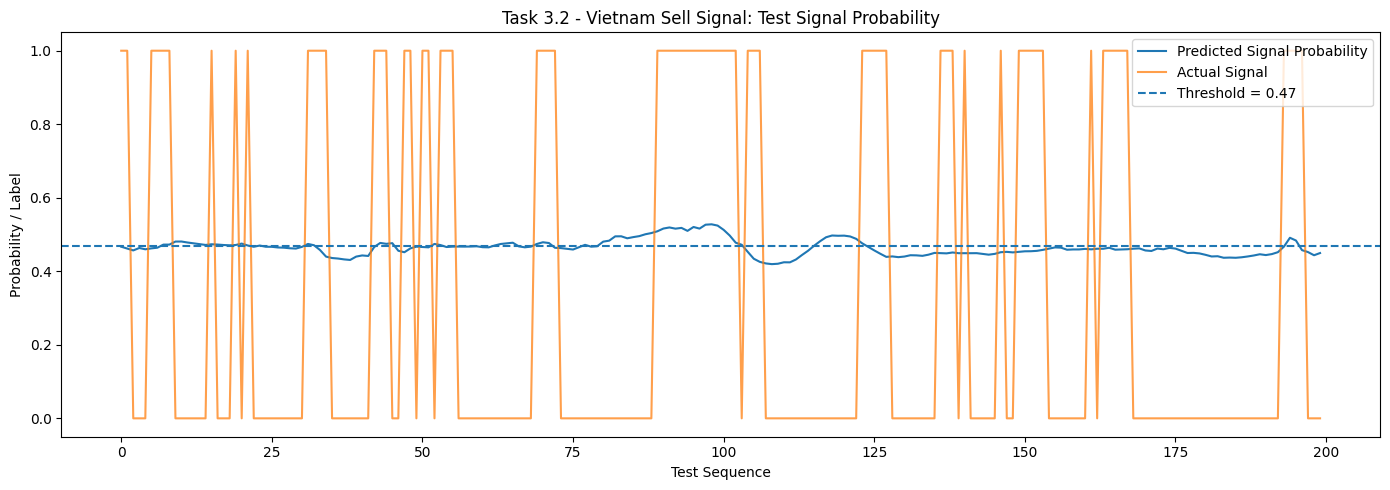

In [202]:
# Execute Task 3.2 Sell Signal Experiment
task_3_2_sell_results = run_trading_signal_experiment(
    experiment_name="Task 3.2 - Vietnam Sell Signal",
    label_column="Sell Signal",
    train_data=task3_train_df,
    val_data=task3_val_df,
    test_data=task3_test_df,
    feature_columns=TASK3_FEATURE_COLUMNS,
    lookback_days=TASK3_LOOKBACK_DAYS,
    epochs=TASK3_EPOCHS,
    batch_size=TASK3_BATCH_SIZE,
    patience=TASK3_PATIENCE,
    dropout_rate=TASK3_DROPOUT_RATE,
    recurrent_dropout_rate=TASK3_RECURRENT_DROPOUT_RATE,
    learning_rate=TASK3_LEARNING_RATE,
)

### Task 3: Summary

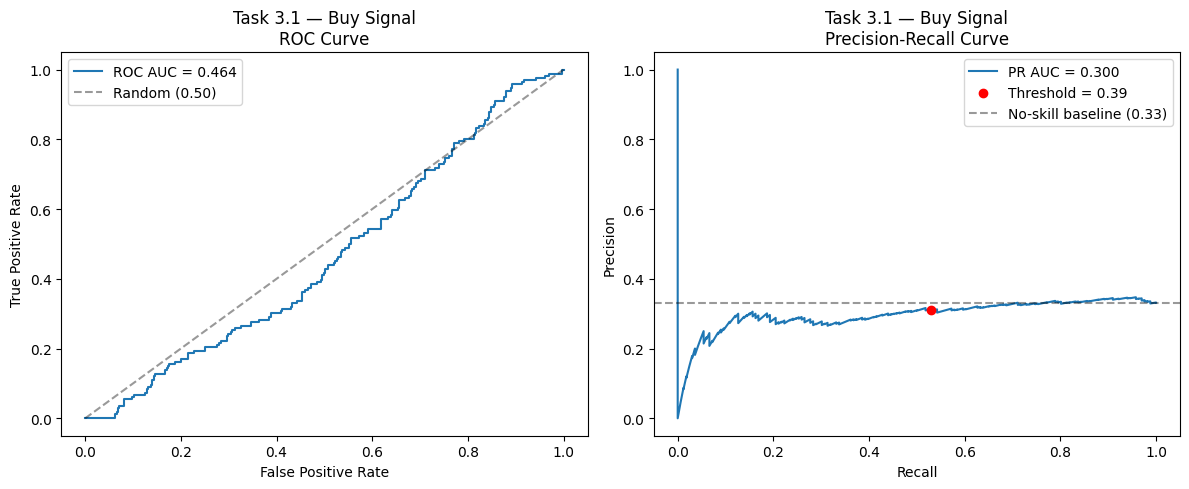

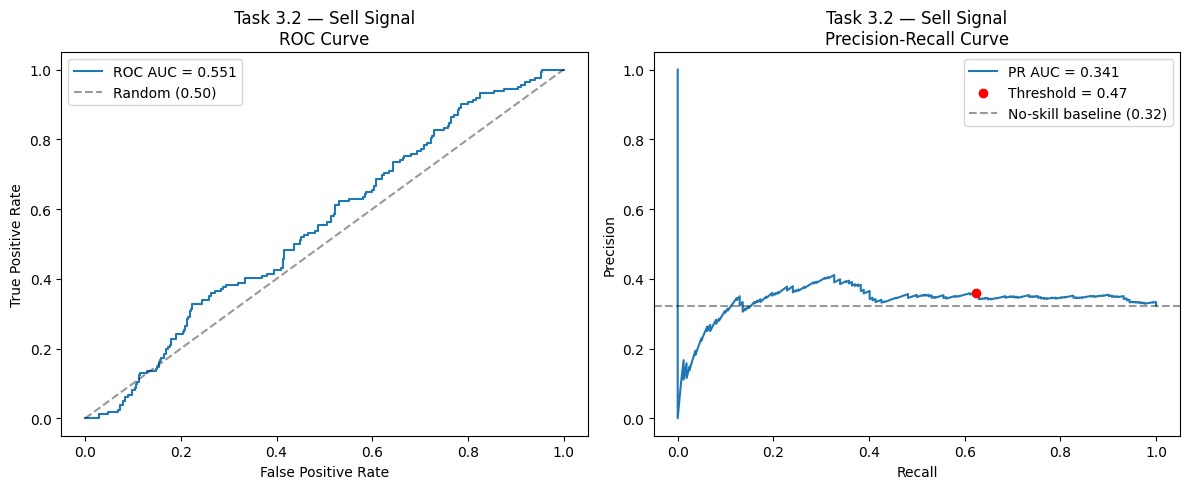

In [203]:
# Visualize ROC, PR Curve of Buy/Sell Signal
plot_roc_and_pr_curves(
    y_true=task_3_1_buy_results["y_test"],
    y_probability=task_3_1_buy_results["test_probability"],
    best_threshold=task_3_1_buy_results["best_threshold"],
    title="Task 3.1 — Buy Signal",
)

plot_roc_and_pr_curves(
    y_true=task_3_2_sell_results["y_test"],
    y_probability=task_3_2_sell_results["test_probability"],
    best_threshold=task_3_2_sell_results["best_threshold"],
    title="Task 3.2 — Sell Signal",
)

In [204]:
# Task 3 Summary
task_3_summary = pd.concat(
    [
        task_3_1_buy_results["test_metrics"].assign(Task="Task 3.1", Signal="Buy"),
        task_3_2_sell_results["test_metrics"].assign(Task="Task 3.2", Signal="Sell"),
    ],
    axis=0,
).reset_index(drop=True)

summary_columns = [
    "Task",
    "Signal",
    "Model",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC AUC",
    "PR AUC",
    "Positive Ratio",
    "Predicted Positive Ratio",
]

summary_columns = [
    column for column in summary_columns
    if column in task_3_summary.columns
]

print("Final Task 3 Summary:")
display(task_3_summary[summary_columns])


Final Task 3 Summary:


,Task,Signal,Model,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Positive Ratio,Predicted Positive Ratio
0,Task 3.1,Buy,Task 3.1 - Vietnam Buy Signal Test,0.39,0.453094,0.309859,0.530120,0.391111,0.464215,0.299501,0.331337,0.566866
1,Task 3.2,Sell,Task 3.2 - Vietnam Sell Signal Test,0.47,0.516966,0.358156,0.623457,0.454955,0.551094,0.341007,0.323353,0.562874


## Task 4: Portfolio composition, risk management and  portfolio optimization for Vietnam market

### Task 4: Supporting Domain Utilities & Setup

In [182]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Config
TASK4_UNIVERSE_SIZE = 40
TASK4_LOOKBACK_DAYS = 60
TASK4_FORECAST_HORIZON = 20

TASK4_TRAIN_RATIO = 0.70
TASK4_VAL_RATIO = 0.15

TASK4_MODEL_TYPE = "gru"
TASK4_DROPOUT_RATE = 0.25
TASK4_RECURRENT_DROPOUT_RATE = 0.00
TASK4_LEARNING_RATE = 3e-4
TASK4_PATIENCE = 8
TASK4_BATCH_SIZE = 64
TASK4_EPOCHS = 40

TASK4_TOP_PROFITABLE = 15
TASK4_PORTFOLIO_SIZE = 8
TASK4_MAX_RISK_SCORE = 0.70
TASK4_MIN_NONZERO_VOLUME_RATE = 0.30

TASK4_FEATURE_COLUMNS = [
    "Return1",
    "Return5",
    "Return20",
    "SMA10 Ratio",
    "SMA20 Ratio",
    "SMA50 Ratio",
    "Volatility10",
    "Volatility20",
    "Volatility60",
    "Momentum10",
    "Momentum20",
    "RSI14",
    "Volume Change",
    "Dollar Volume",
    "Price Range",
]

TASK4_TARGET_COLUMN = "Future Return"

In [183]:
# Feature Engineering
def task4_compute_rsi(price: pd.Series, window: int = 14) -> pd.Series:
    price_change = price.diff()
    gain = price_change.clip(lower=0)
    loss = -price_change.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    relative_strength = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + relative_strength))

    return rsi


def task4_add_features(
    data: pd.DataFrame,
    ticker: str,
    forecast_horizon: int,
) -> pd.DataFrame:
    feature_data = data.copy()
    feature_data = feature_data.sort_values("Date").reset_index(drop=True)

    feature_data["Ticker"] = ticker.upper()

    feature_data["Return1"] = feature_data["Close"].pct_change()
    feature_data["Return5"] = feature_data["Close"].pct_change(periods=5)
    feature_data["Return20"] = feature_data["Close"].pct_change(periods=20)

    feature_data["SMA10"] = feature_data["Close"].rolling(window=10).mean()
    feature_data["SMA20"] = feature_data["Close"].rolling(window=20).mean()
    feature_data["SMA50"] = feature_data["Close"].rolling(window=50).mean()

    feature_data["SMA10 Ratio"] = feature_data["Close"] / feature_data["SMA10"] - 1
    feature_data["SMA20 Ratio"] = feature_data["Close"] / feature_data["SMA20"] - 1
    feature_data["SMA50 Ratio"] = feature_data["Close"] / feature_data["SMA50"] - 1

    feature_data["Volatility10"] = feature_data["Return1"].rolling(window=10).std()
    feature_data["Volatility20"] = feature_data["Return1"].rolling(window=20).std()
    feature_data["Volatility60"] = feature_data["Return1"].rolling(window=60).std()

    feature_data["Momentum10"] = feature_data["Close"] / feature_data["Close"].shift(10) - 1
    feature_data["Momentum20"] = feature_data["Close"] / feature_data["Close"].shift(20) - 1

    feature_data["RSI14"] = task4_compute_rsi(feature_data["Close"], window=14)

    feature_data["Volume Change"] = feature_data["Volume"].pct_change()
    feature_data["Dollar Volume"] = feature_data["Close"] * feature_data["Volume"]
    feature_data["Price Range"] = (
        (feature_data["High"] - feature_data["Low"])
        / feature_data["Close"].replace(0, np.nan)
    )

    feature_data["Future Close"] = feature_data["Close"].shift(-forecast_horizon)
    feature_data["Future Return"] = feature_data["Future Close"] / feature_data["Close"] - 1

    feature_data = feature_data.replace([np.inf, -np.inf], np.nan)

    return feature_data


def task4_max_drawdown(price: pd.Series) -> float:
    price = price.dropna()

    if price.empty:
        return np.nan

    running_max = price.cummax()
    drawdown = price / running_max - 1

    return float(drawdown.min())


def task4_downside_volatility(returns: pd.Series) -> float:
    downside_returns = returns[returns < 0]

    if downside_returns.empty:
        return 0.0

    return float(downside_returns.std())

In [184]:
# Universe Loading
def task4_get_candidate_tickers(
    valid_tickers: pd.DataFrame,
    universe_size: int,
) -> list[str]:
    if valid_tickers.empty:
        raise ValueError("No Vietnam valid tickers are available. Run Task 2 first.")

    ticker_table = valid_tickers.copy()

    if "Eligible" in ticker_table.columns:
        ticker_table = ticker_table[ticker_table["Eligible"]].copy()

    if ticker_table.empty:
        raise ValueError("No eligible Vietnam tickers are available for Task 4.")

    if "Close Spike Rate" in ticker_table.columns:
        ticker_table["Close Spike Rate"] = pd.to_numeric(
            ticker_table["Close Spike Rate"],
            errors="coerce",
        )

    if "Rows" in ticker_table.columns:
        ticker_table["Rows"] = pd.to_numeric(ticker_table["Rows"], errors="coerce")

    sort_columns = []
    ascending = []

    if "Close Spike Rate" in ticker_table.columns:
        sort_columns.append("Close Spike Rate")
        ascending.append(True)

    if "Rows" in ticker_table.columns:
        sort_columns.append("Rows")
        ascending.append(False)

    sort_columns.append("Ticker")
    ascending.append(True)

    ticker_table = ticker_table.sort_values(
        by=sort_columns,
        ascending=ascending,
    ).reset_index(drop=True)

    return ticker_table["Ticker"].astype(str).str.upper().head(universe_size).tolist()


def task4_load_feature_universe(
    data_dir: Path,
    tickers: list[str],
    forecast_horizon: int,
    feature_columns: list[str],
    min_rows: int,
) -> dict[str, pd.DataFrame]:
    ticker_data_map = {}

    for ticker in tickers:
        try:
            raw_data = load_vietnam_stock_price_data(
                data_dir=data_dir,
                ticker=ticker,
            )

            feature_data = task4_add_features(
                data=raw_data,
                ticker=ticker,
                forecast_horizon=forecast_horizon,
            )

            feature_data = feature_data.dropna(
                subset=["Date", "Open", "High", "Low", "Close", "Volume"] + feature_columns
            ).reset_index(drop=True)

            if len(feature_data) >= min_rows:
                ticker_data_map[ticker] = feature_data

        except Exception as error:
            print(f"Skipping Task 4 ticker {ticker}: {error}")

    if not ticker_data_map:
        raise ValueError("No valid Task 4 ticker data was loaded.")

    return ticker_data_map


task4_candidate_tickers = task4_get_candidate_tickers(
    valid_tickers=vietnam_valid_tickers,
    universe_size=TASK4_UNIVERSE_SIZE,
)

print("Task 4 candidate tickers:")
print(task4_candidate_tickers)

task4_ticker_data_map = task4_load_feature_universe(
    data_dir=VIETNAM_PRICE_DATA_DIR,
    tickers=task4_candidate_tickers,
    forecast_horizon=TASK4_FORECAST_HORIZON,
    feature_columns=TASK4_FEATURE_COLUMNS,
    min_rows=max(MIN_HISTORY_POINTS, TASK4_LOOKBACK_DAYS + TASK4_FORECAST_HORIZON + 30),
)

print(f"Task 4 loaded tickers: {len(task4_ticker_data_map)}")

Task 4 candidate tickers:
['REE', 'SAM', 'TMS', 'GIL', 'GMD', 'SAV', 'HAS', 'DHA', 'MHC', 'TNA', 'KDC', 'VNM', 'TYA', 'CII', 'BMP', 'STB', 'SMC', 'ITA', 'CLC', 'IMP', 'PVD', 'RAL', 'FMC', 'PAC', 'FPT', 'TDH', 'LBM', 'DHG', 'HMC', 'VIP', 'DMC', 'SCD', 'SJD', 'HBC', 'LGC', 'VTB', 'BMC', 'MCP', 'PJT', 'DRC']
Task 4 loaded tickers: 40


In [185]:
# Sequence Building Across Multiple Tickers
def task4_split_single_ticker(
    data: pd.DataFrame,
    train_ratio: float,
    val_ratio: float,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    row_count = len(data)
    train_end = int(row_count * train_ratio)
    val_end = int(row_count * (train_ratio + val_ratio))

    train_data = data.iloc[:train_end].copy()
    val_data = data.iloc[train_end:val_end].copy()
    test_data = data.iloc[val_end:].copy()

    return train_data, val_data, test_data


def task4_make_sequences(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    lookback_days: int,
    feature_scaler: StandardScaler,
) -> tuple[np.ndarray, np.ndarray]:
    model_data = data.dropna(subset=feature_columns + [target_column]).copy()

    x_scaled = feature_scaler.transform(model_data[feature_columns])
    y_values = model_data[target_column].to_numpy(dtype=float)

    x_sequences = []
    y_targets = []

    max_start = len(model_data) - lookback_days + 1

    for start_index in range(max_start):
        target_index = start_index + lookback_days - 1

        x_sequences.append(x_scaled[start_index:target_index + 1])
        y_targets.append(y_values[target_index])

    return np.asarray(x_sequences), np.asarray(y_targets)


def task4_prepare_multi_ticker_sequences(
    ticker_data_map: dict[str, pd.DataFrame],
    feature_columns: list[str],
    target_column: str,
    lookback_days: int,
    train_ratio: float,
    val_ratio: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    train_frames = []
    split_map = {}

    for ticker, data in ticker_data_map.items():
        train_data, val_data, test_data = task4_split_single_ticker(
            data=data,
            train_ratio=train_ratio,
            val_ratio=val_ratio,
        )

        split_map[ticker] = {
            "train": train_data,
            "val": val_data,
            "test": test_data,
        }

        train_frames.append(train_data)

    combined_train_data = pd.concat(train_frames, axis=0, ignore_index=True)

    feature_scaler = StandardScaler()
    feature_scaler.fit(combined_train_data[feature_columns])

    x_train_list = []
    y_train_list = []
    x_val_list = []
    y_val_list = []
    x_test_list = []
    y_test_list = []

    for ticker, splits in split_map.items():
        x_train, y_train = task4_make_sequences(
            data=splits["train"],
            feature_columns=feature_columns,
            target_column=target_column,
            lookback_days=lookback_days,
            feature_scaler=feature_scaler,
        )

        train_val_context = pd.concat(
            [splits["train"].tail(lookback_days - 1), splits["val"]],
            axis=0,
            ignore_index=True,
        )

        x_val, y_val = task4_make_sequences(
            data=train_val_context,
            feature_columns=feature_columns,
            target_column=target_column,
            lookback_days=lookback_days,
            feature_scaler=feature_scaler,
        )

        train_val_data = pd.concat([splits["train"], splits["val"]], axis=0)

        test_context = pd.concat(
            [train_val_data.tail(lookback_days - 1), splits["test"]],
            axis=0,
            ignore_index=True,
        )

        x_test, y_test = task4_make_sequences(
            data=test_context,
            feature_columns=feature_columns,
            target_column=target_column,
            lookback_days=lookback_days,
            feature_scaler=feature_scaler,
        )

        if len(x_train) > 0:
            x_train_list.append(x_train)
            y_train_list.append(y_train)

        if len(x_val) > 0:
            x_val_list.append(x_val)
            y_val_list.append(y_val)

        if len(x_test) > 0:
            x_test_list.append(x_test)
            y_test_list.append(y_test)

    x_train_all = np.concatenate(x_train_list, axis=0)
    y_train_all = np.concatenate(y_train_list, axis=0)
    x_val_all = np.concatenate(x_val_list, axis=0)
    y_val_all = np.concatenate(y_val_list, axis=0)
    x_test_all = np.concatenate(x_test_list, axis=0)
    y_test_all = np.concatenate(y_test_list, axis=0)

    return (
        x_train_all,
        y_train_all,
        x_val_all,
        y_val_all,
        x_test_all,
        y_test_all,
        feature_scaler,
    )


(
    task4_x_train,
    task4_y_train,
    task4_x_val,
    task4_y_val,
    task4_x_test,
    task4_y_test,
    task4_feature_scaler,
) = task4_prepare_multi_ticker_sequences(
    ticker_data_map=task4_ticker_data_map,
    feature_columns=TASK4_FEATURE_COLUMNS,
    target_column=TASK4_TARGET_COLUMN,
    lookback_days=TASK4_LOOKBACK_DAYS,
    train_ratio=TASK4_TRAIN_RATIO,
    val_ratio=TASK4_VAL_RATIO,
)

print("Task 4 train sequences:", task4_x_train.shape)
print("Task 4 validation sequences:", task4_x_val.shape)
print("Task 4 test sequences:", task4_x_test.shape)

Task 4 train sequences: (113098, 60, 15)
Task 4 validation sequences: (24745, 60, 15)
Task 4 test sequences: (24022, 60, 15)


Epoch 1/40
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - loss: 0.0018 - mae: 0.1019 - val_loss: 0.0012 - val_mae: 0.0672 - learning_rate: 3.0000e-04
Epoch 2/40
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 140s 53ms/step - loss: 0.0017 - mae: 0.0935 - val_loss: 0.0012 - val_mae: 0.0670 - learning_rate: 3.0000e-04
Epoch 3/40
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 92s 52ms/step - loss: 0.0017 - mae: 0.0929 - val_loss: 0.0012 - val_mae: 0.0670 - learning_rate: 3.0000e-04
Epoch 4/40
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 88s 50ms/step - loss: 0.0017 - mae: 0.0926 - val_loss: 0.0012 - val_mae: 0.0670 - learning_rate: 3.0000e-04
Epoch 5/40
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 88s 50ms/step - loss: 0.0017 - mae: 0.0922 - val_loss: 0.0012 - val_mae: 0.0671 - learning_rate: 3.0000e-04
Epoch 6/40
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 87s 49ms/step - loss: 0.0016 - mae: 0.0915 - val_loss: 0.0012 - val_mae: 0.0671 - learning_rate: 1.5000e-04
Epoch 7/40
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 86s 49ms/step - loss: 0.0016 - mae: 0.0913 - val_loss: 0.

,MAE,MSE,RMSE,R2,Directional Accuracy
0,0.094041,0.018566,0.136256,-0.025069,49.633669


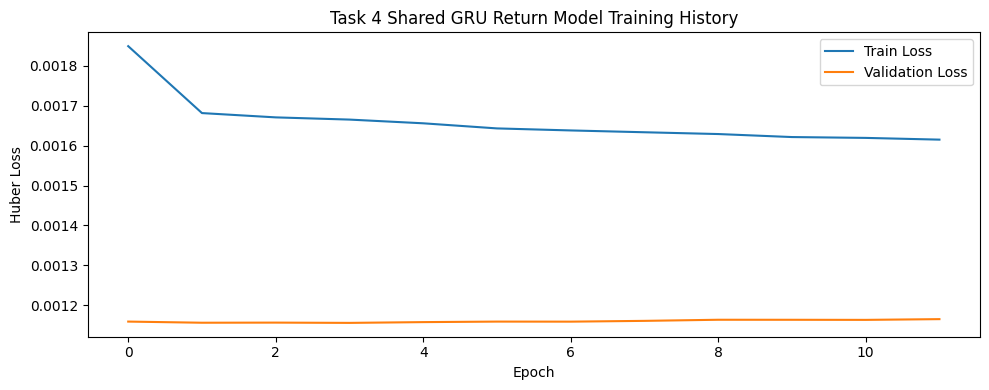

In [186]:
# Shared GRU Return Prediction Model
def build_task4_gru_return_model(
    input_shape: tuple[int, int],
    dropout_rate: float = 0.25,
    recurrent_dropout_rate: float = 0.00,
    learning_rate: float = 3e-4,
) -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.GRU(
                48,
                return_sequences=True,
                recurrent_dropout=recurrent_dropout_rate,
            ),
            layers.Dropout(dropout_rate),
            layers.GRU(
                24,
                recurrent_dropout=recurrent_dropout_rate,
            ),
            layers.Dropout(dropout_rate),
            layers.Dense(16, activation="relu"),
            layers.Dense(1),
        ],
        name="Task4_GRU_return_forecaster",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.Huber(delta=0.02),
        metrics=["mae"],
    )

    return model


task4_model = build_task4_gru_return_model(
    input_shape=(TASK4_LOOKBACK_DAYS, len(TASK4_FEATURE_COLUMNS)),
    dropout_rate=TASK4_DROPOUT_RATE,
    recurrent_dropout_rate=TASK4_RECURRENT_DROPOUT_RATE,
    learning_rate=TASK4_LEARNING_RATE,
)

task4_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=TASK4_PATIENCE,
        restore_best_weights=True,
        verbose=0,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=max(3, TASK4_PATIENCE // 2),
        min_lr=1e-6,
        verbose=0,
    ),
]

task4_history = task4_model.fit(
    task4_x_train,
    task4_y_train,
    validation_data=(task4_x_val, task4_y_val),
    epochs=TASK4_EPOCHS,
    batch_size=TASK4_BATCH_SIZE,
    callbacks=task4_callbacks,
    verbose=1,
    shuffle=False,
)

task4_test_pred = task4_model.predict(task4_x_test, verbose=0).reshape(-1)

task4_mse = mean_squared_error(task4_y_test, task4_test_pred)
task4_model_metrics = pd.DataFrame(
    [
        {
            "MAE": mean_absolute_error(task4_y_test, task4_test_pred),
            "MSE": task4_mse,
            "RMSE": np.sqrt(task4_mse),
            "R2": r2_score(task4_y_test, task4_test_pred),
            "Directional Accuracy": np.mean(
                np.sign(task4_y_test) == np.sign(task4_test_pred)
            ) * 100,
        }
    ]
)

print("Task 4 shared GRU return model test metrics:")
display(task4_model_metrics)

task4_history_df = pd.DataFrame(task4_history.history)

plt.figure(figsize=(10, 4))
plt.plot(task4_history_df["loss"], label="Train Loss")
plt.plot(task4_history_df["val_loss"], label="Validation Loss")
plt.title("Task 4 Shared GRU Return Model Training History")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [187]:
# Latest Prediction for Each Ticker
def task4_predict_latest_return(
    model: keras.Model,
    ticker_data_map: dict[str, pd.DataFrame],
    feature_columns: list[str],
    lookback_days: int,
    feature_scaler: StandardScaler,
) -> pd.DataFrame:
    rows = []

    for ticker, data in ticker_data_map.items():
        latest_data = data.dropna(subset=feature_columns).copy()

        if len(latest_data) < lookback_days:
            continue

        latest_window = latest_data.tail(lookback_days)
        x_latest = feature_scaler.transform(latest_window[feature_columns])
        x_latest = x_latest.reshape(1, lookback_days, len(feature_columns))

        predicted_return = float(model.predict(x_latest, verbose=0).reshape(-1)[0])

        rows.append(
            {
                "Ticker": ticker,
                "Prediction Date": latest_window["Date"].iloc[-1],
                "Current Close": float(latest_window["Close"].iloc[-1]),
                "Predicted Return": predicted_return,
                "Predicted Price": float(latest_window["Close"].iloc[-1] * (1 + predicted_return)),
            }
        )

    return pd.DataFrame(rows)


task4_prediction_df = task4_predict_latest_return(
    model=task4_model,
    ticker_data_map=task4_ticker_data_map,
    feature_columns=TASK4_FEATURE_COLUMNS,
    lookback_days=TASK4_LOOKBACK_DAYS,
    feature_scaler=task4_feature_scaler,
)

display(task4_prediction_df.sort_values("Predicted Return", ascending=False).head(20))

,Ticker,Prediction Date,Current Close,Predicted Return,Predicted Price
18,CLC,2023-02-28,34900.0,0.012318,35329.909583
27,DHG,2023-02-28,96300.0,0.009195,97185.521453
7,DHA,2023-02-28,36700.0,0.008667,37018.092388
25,TDH,2023-02-28,3380.0,0.008667,3409.295702
23,PAC,2023-02-28,31400.0,0.008667,31672.155340
39,DRC,2023-02-28,22250.0,0.008667,22442.848927
28,HMC,2023-02-28,10500.0,0.008667,10591.007359
35,VTB,2023-02-28,11900.0,0.008667,12003.141673
34,LGC,2023-02-28,56900.0,0.008667,57393.173211
36,BMC,2023-02-28,13300.0,0.008667,13415.275988


In [188]:
# Profitability and Risk Scoring
def task4_minmax_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    min_value = values.min()
    max_value = values.max()

    if pd.isna(min_value) or pd.isna(max_value) or np.isclose(max_value, min_value):
        return pd.Series(0.5, index=series.index)

    score = (values - min_value) / (max_value - min_value)

    if not higher_is_better:
        score = 1 - score

    return score.clip(0, 1)


def task4_compute_stock_scores(
    ticker_data_map: dict[str, pd.DataFrame],
    prediction_df: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for ticker, data in ticker_data_map.items():
        score_data = data.sort_values("Date").reset_index(drop=True).copy()
        recent_data = score_data.tail(120).copy()

        returns = recent_data["Close"].pct_change(fill_method=None).replace(
            [np.inf, -np.inf],
            np.nan,
        )

        trailing_return_20 = float(recent_data["Close"].iloc[-1] / recent_data["Close"].iloc[-21] - 1) if len(recent_data) >= 21 else np.nan
        trailing_return_60 = float(recent_data["Close"].iloc[-1] / recent_data["Close"].iloc[-61] - 1) if len(recent_data) >= 61 else np.nan

        volatility_20 = float(returns.tail(20).std())
        volatility_60 = float(returns.tail(60).std())
        downside_volatility_60 = task4_downside_volatility(returns.tail(60))
        max_drawdown_120 = task4_max_drawdown(recent_data["Close"])

        mean_return_60 = float(returns.tail(60).mean())
        sharpe_60 = (
            mean_return_60 / volatility_60 * np.sqrt(252)
            if volatility_60 and not np.isclose(volatility_60, 0)
            else np.nan
        )

        nonzero_volume_rate = float(recent_data["Volume"].gt(0).mean())
        median_dollar_volume = float((recent_data["Close"] * recent_data["Volume"]).median())

        rows.append(
            {
                "Ticker": ticker,
                "Trailing Return 20D": trailing_return_20,
                "Trailing Return 60D": trailing_return_60,
                "Volatility 20D": volatility_20,
                "Volatility 60D": volatility_60,
                "Downside Volatility 60D": downside_volatility_60,
                "Max Drawdown 120D": max_drawdown_120,
                "Sharpe 60D": sharpe_60,
                "Nonzero Volume Rate": nonzero_volume_rate,
                "Median Dollar Volume": median_dollar_volume,
            }
        )

    score_df = pd.DataFrame(rows)
    score_df = score_df.merge(prediction_df, on="Ticker", how="left")

    score_df["Predicted Return Score"] = task4_minmax_score(
        score_df["Predicted Return"],
        higher_is_better=True,
    )
    score_df["Momentum Score"] = task4_minmax_score(
        score_df["Trailing Return 20D"],
        higher_is_better=True,
    )
    score_df["Sharpe Score"] = task4_minmax_score(
        score_df["Sharpe 60D"],
        higher_is_better=True,
    )
    score_df["Liquidity Score"] = task4_minmax_score(
        score_df["Median Dollar Volume"],
        higher_is_better=True,
    )

    score_df["Volatility Risk"] = task4_minmax_score(
        score_df["Volatility 60D"],
        higher_is_better=True,
    )
    score_df["Downside Risk"] = task4_minmax_score(
        score_df["Downside Volatility 60D"],
        higher_is_better=True,
    )
    score_df["Drawdown Risk"] = task4_minmax_score(
        score_df["Max Drawdown 120D"].abs(),
        higher_is_better=True,
    )
    score_df["Liquidity Risk"] = task4_minmax_score(
        score_df["Median Dollar Volume"],
        higher_is_better=False,
    )

    score_df["Profitability Score"] = (
        0.45 * score_df["Predicted Return Score"]
        + 0.25 * score_df["Momentum Score"]
        + 0.20 * score_df["Sharpe Score"]
        + 0.10 * score_df["Liquidity Score"]
    )

    score_df["Risk Score"] = (
        0.35 * score_df["Volatility Risk"]
        + 0.30 * score_df["Downside Risk"]
        + 0.25 * score_df["Drawdown Risk"]
        + 0.10 * score_df["Liquidity Risk"]
    )

    score_df["Risk Adjusted Score"] = (
        score_df["Profitability Score"] - 0.60 * score_df["Risk Score"]
    )

    score_df["Risk Flag"] = np.where(
        (score_df["Risk Score"] > TASK4_MAX_RISK_SCORE)
        | (score_df["Nonzero Volume Rate"] < TASK4_MIN_NONZERO_VOLUME_RATE),
        "Exclude",
        "Keep",
    )

    return score_df.sort_values(
        by=["Risk Adjusted Score", "Profitability Score"],
        ascending=[False, False],
    ).reset_index(drop=True)


task4_stock_score_df = task4_compute_stock_scores(
    ticker_data_map=task4_ticker_data_map,
    prediction_df=task4_prediction_df,
)

print("Task 4 stock profitability and risk scores:")
display(task4_stock_score_df.head(20))

Task 4 stock profitability and risk scores:


,Ticker,Trailing Return 20D,Trailing Return 60D,Volatility 20D,Volatility 60D,Downside Volatility 60D,Max Drawdown 120D,Sharpe 60D,Nonzero Volume Rate,Median Dollar Volume,...,Sharpe Score,Liquidity Score,Volatility Risk,Downside Risk,Drawdown Risk,Liquidity Risk,Profitability Score,Risk Score,Risk Adjusted Score,Risk Flag
0,DHG,0.020127,0.160241,0.010710,0.012579,0.004831,-0.131522,3.226981,1.000000,7.265570e+08,...,0.889573,0.001897,0.088595,0.010385,0.047049,0.998103,0.732737,0.145697,0.645320,Keep
1,CLC,0.090386,0.103592,0.014953,0.016025,0.012923,-0.162168,1.754263,0.958333,1.088588e+08,...,0.646964,0.000281,0.166493,0.263855,0.102316,0.999719,0.749566,0.262980,0.591778,Keep
2,DMC,-0.021739,0.071429,0.005644,0.011226,0.007359,-0.184368,1.714277,0.991667,2.187352e+08,...,0.640377,0.000569,0.058012,0.089570,0.142350,0.999431,0.623168,0.182706,0.513545,Keep
3,LGC,0.236957,0.306844,0.039490,0.036634,0.026745,-0.258872,2.219581,0.633333,8.445200e+06,...,0.723619,0.000019,0.632378,0.696848,0.276709,0.999981,0.812888,0.599562,0.453151,Keep
4,SAV,-0.043046,0.156000,0.016320,0.017030,0.010710,-0.340369,2.386929,0.983333,1.104400e+08,...,0.751187,0.000285,0.189230,0.194532,0.423679,0.999715,0.634062,0.330481,0.435773,Keep
5,SJD,-0.032258,0.003344,0.006473,0.008659,0.004500,-0.248619,0.169284,1.000000,7.335974e+08,...,0.385862,0.001916,0.000000,0.000000,0.258219,0.998084,0.534243,0.164363,0.435625,Keep
6,DHA,-0.021333,0.361074,0.015366,0.025195,0.018087,-0.400011,3.440745,1.000000,1.159835e+09,...,0.924788,0.003031,0.373789,0.425615,0.531235,0.996969,0.712700,0.491016,0.418090,Keep
7,RAL,-0.082474,0.105590,0.015069,0.018982,0.007979,-0.308333,1.544767,1.000000,1.635016e+09,...,0.612453,0.004274,0.233345,0.108990,0.365906,0.995726,0.591210,0.305417,0.407960,Keep
8,BMP,-0.080000,0.087273,0.021030,0.022151,0.012772,-0.207055,1.171802,1.000000,3.944725e+09,...,0.551012,0.010317,0.304991,0.259123,0.183264,0.989683,0.592478,0.329268,0.394917,Keep
9,DRC,-0.040948,0.116576,0.025398,0.019630,0.012332,-0.463116,1.640613,1.000000,6.889567e+09,...,0.628242,0.018022,0.247990,0.245343,0.645036,0.981978,0.644203,0.419856,0.392289,Keep


### Task 4.1: Portfolio composition

In [189]:
# ============================================================
# Task 4.1: Profitable Stock Selection
# ============================================================
task4_profitable_stocks = task4_stock_score_df[
    task4_stock_score_df["Risk Flag"] == "Keep"
].sort_values(
    by=["Profitability Score", "Predicted Return"],
    ascending=[False, False],
).head(TASK4_TOP_PROFITABLE)

print("Task 4.1 Profitable stock selection:")
display(
    task4_profitable_stocks[
        [
            "Ticker",
            "Current Close",
            "Predicted Return",
            "Predicted Price",
            "Trailing Return 20D",
            "Trailing Return 60D",
            "Sharpe 60D",
            "Profitability Score",
            "Risk Score",
            "Risk Adjusted Score",
        ]
    ]
)

Task 4.1 Profitable stock selection:


,Ticker,Current Close,Predicted Return,Predicted Price,Trailing Return 20D,Trailing Return 60D,Sharpe 60D,Profitability Score,Risk Score,Risk Adjusted Score
3,LGC,56900.0,0.008667,57393.173211,0.236957,0.306844,2.219581,0.812888,0.599562,0.453151
1,CLC,34900.0,0.012318,35329.909583,0.090386,0.103592,1.754263,0.749566,0.262980,0.591778
0,DHG,96300.0,0.009195,97185.521453,0.020127,0.160241,3.226981,0.732737,0.145697,0.645320
6,DHA,36700.0,0.008667,37018.092388,-0.021333,0.361074,3.440745,0.712700,0.491016,0.418090
18,TDH,3380.0,0.008667,3409.295702,0.056250,0.076433,0.902562,0.671120,0.603951,0.308750
10,HMC,10500.0,0.008667,10591.007359,-0.009434,0.151316,1.985496,0.671070,0.485122,0.379997
15,VIP,10150.0,0.004613,10196.823056,-0.009756,0.309677,2.507590,0.653052,0.535240,0.331908
9,DRC,22250.0,0.008667,22442.848927,-0.040948,0.116576,1.640613,0.644203,0.419856,0.392289
17,PAC,31400.0,0.008667,31672.155340,0.011272,0.049465,0.650339,0.638239,0.537718,0.315608
4,SAV,14450.0,0.005019,14522.526229,-0.043046,0.156000,2.386929,0.634062,0.330481,0.435773


### Task 4.2: Risk management

In [190]:
# ============================================================
# Task 4.2: Risk Management
# ============================================================
task4_risky_stocks = task4_stock_score_df[
    task4_stock_score_df["Risk Flag"] == "Exclude"
].sort_values(
    by=["Risk Score", "Max Drawdown 120D"],
    ascending=[False, True],
)

print("Task 4.2 Risky stocks to exclude:")
display(
    task4_risky_stocks[
        [
            "Ticker",
            "Risk Score",
            "Volatility 60D",
            "Downside Volatility 60D",
            "Max Drawdown 120D",
            "Nonzero Volume Rate",
            "Median Dollar Volume",
            "Risk Flag",
        ]
    ].head(20)
)

Task 4.2 Risky stocks to exclude:


,Ticker,Risk Score,Volatility 60D,Downside Volatility 60D,Max Drawdown 120D,Nonzero Volume Rate,Median Dollar Volume,Risk Flag
36,HAS,0.885424,0.049035,0.036423,-0.473594,0.725000,1.369000e+06,Exclude
39,SCD,0.828469,0.052897,0.032396,-0.363415,0.750000,9.325000e+06,Exclude
38,GIL,0.810495,0.042716,0.025933,-0.647272,1.000000,1.782816e+10,Exclude
34,MCP,0.802544,0.042036,0.026914,-0.610769,0.808333,7.517500e+06,Exclude
37,HBC,0.766220,0.040934,0.022440,-0.659950,1.000000,2.953458e+10,Exclude
33,ITA,0.754857,0.041345,0.023060,-0.602761,1.000000,9.097153e+09,Exclude
32,SMC,0.728408,0.036360,0.022239,-0.644724,1.000000,2.291284e+09,Exclude


### Task 4.3: Portfolio optimization

In [191]:
# ============================================================
# Task 4.3: Portfolio Composition
# ============================================================

def task4_build_portfolio(
    score_df: "pd.DataFrame",
    portfolio_size: int,
    risk_profile: str,
) -> "pd.DataFrame":
    """
    Improved portfolio construction with three weighting schemes:

      risk_taking: Predicted-return-weighted allocation, softer risk penalty.
                   Selects stocks with the highest expected upside.
      prudent:     Inverse-volatility weighting. Allocates more capital to
                   lower-risk stocks, regardless of predicted return magnitude.
                   This is a principled technique used in real portfolios.

    The key improvement over the original:
      - Inverse-volatility weighting is a well-known, justified method
        (rather than an ad-hoc raw_weight hack).
      - Both portfolios are filtered by Risk Flag = Keep.
      - Weights always sum exactly to 1.0.
    """
    import numpy as np
    import pandas as pd

    investable_df = score_df[score_df["Risk Flag"] == "Keep"].copy()

    if investable_df.empty:
        raise ValueError("No investable stocks available after risk filtering.")

    # Step 1: Rank candidates by profile-specific score
    if risk_profile == "risk_taking":
        # Higher predicted return and lower risk penalty
        investable_df["Portfolio Ranking Score"] = (
            investable_df["Profitability Score"] - 0.25 * investable_df["Risk Score"]
        )
    elif risk_profile == "prudent":
        # Much higher risk penalty; strong preference for low-volatility names
        investable_df["Portfolio Ranking Score"] = (
            investable_df["Profitability Score"] - 0.85 * investable_df["Risk Score"]
        )
    else:
        raise ValueError("risk_profile must be 'risk_taking' or 'prudent'.")

    selected_df = (
        investable_df
        .sort_values(by=["Portfolio Ranking Score", "Predicted Return"], ascending=[False, False])
        .head(portfolio_size)
        .copy()
    )

    # Step 2: Compute weights
    if risk_profile == "risk_taking":
        # Weight by predicted positive return (zero-floored)
        raw_weight = selected_df["Predicted Return"].clip(lower=0)
        if raw_weight.sum() <= 0 or raw_weight.isna().all():
            # Fallback: equal weight
            raw_weight = pd.Series(1.0, index=selected_df.index)
        selected_df["Weight"] = raw_weight / raw_weight.sum()

    else:  # prudent → inverse-volatility
        vol = selected_df["Volatility 60D"].replace(0, np.nan)
        if vol.isna().all():
            # Fallback: equal weight
            selected_df["Weight"] = 1.0 / len(selected_df)
        else:
            inv_vol = 1.0 / vol.fillna(vol.median())
            selected_df["Weight"] = inv_vol / inv_vol.sum()

    selected_df["Risk Profile"] = risk_profile
    selected_df["Weight"] = selected_df["Weight"].clip(lower=0)
    # Renormalize to handle any floating point drift
    selected_df["Weight"] = selected_df["Weight"] / selected_df["Weight"].sum()

    return selected_df.sort_values("Weight", ascending=False).reset_index(drop=True)


def task4_build_meanvariance_portfolio(
    ticker_data_map: dict,
    candidate_tickers: list,
    forecast_df: "pd.DataFrame",
    portfolio_size: int = 8,
    risk_aversion: float = 2.0,
) -> "pd.DataFrame":
    """
    Simple mean-variance (Markowitz) optimization using scipy.
    Maximizes:  μᵀw − λ/2 · wᵀΣw
    where μ = predicted returns, Σ = historical return covariance matrix,
    λ = risk_aversion parameter.

    This is the academically rigorous Task 4.3 optimization method.

    Args:
        ticker_data_map:  dict of {ticker: DataFrame with 'Close' column}
        candidate_tickers: list of tickers to consider
        forecast_df:       output of task4_predict_latest_return()
        portfolio_size:    max number of holdings (top by predicted return)
        risk_aversion:     λ — higher = more conservative allocation
    """
    import numpy as np
    import pandas as pd
    from scipy.optimize import minimize

    # Align predicted returns
    pred = forecast_df.set_index("Ticker")["Predicted Return"]
    tickers = [t for t in candidate_tickers if t in pred.index and t in ticker_data_map]

    # Pre-select top N by predicted return to keep the problem tractable
    pred_filtered = pred[tickers].nlargest(portfolio_size)
    tickers = list(pred_filtered.index)
    mu = pred_filtered.values  # expected return vector

    # Build return matrix
    return_frames = []
    for t in tickers:
        closes = (
            ticker_data_map[t]
            .sort_values("Date")[["Date", "Close"]]
            .set_index("Date")["Close"]
            .rename(t)
        )
        returns = closes.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan).dropna()
        return_frames.append(returns)

    aligned = pd.concat(return_frames, axis=1, join="inner").dropna()

    if aligned.shape[0] < 30:
        print("Not enough overlapping history for MV optimization; falling back to equal weight.")
        weights = np.ones(len(tickers)) / len(tickers)
    else:
        Sigma = aligned.cov().values

        def neg_utility(w):
            port_return = float(mu @ w)
            port_var = float(w @ Sigma @ w)
            return -(port_return - (risk_aversion / 2) * port_var)

        n = len(tickers)
        constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
        bounds = [(0.0, 1.0)] * n  # long-only
        w0 = np.ones(n) / n

        result = minimize(neg_utility, w0, method="SLSQP", bounds=bounds, constraints=constraints)
        weights = result.x if result.success else w0

    port_df = pd.DataFrame({
        "Ticker": tickers,
        "Predicted Return": mu,
        "Weight": weights,
        "Optimization": "Mean-Variance",
    }).sort_values("Weight", ascending=False).reset_index(drop=True)

    return port_df

### Task 4.3.1 Portfolio Backtest & Performance Metrics

In [192]:
# Function to perform backtesting
def task4_backtest_portfolio(
    portfolio_df: "pd.DataFrame",
    ticker_data_map: dict,
    test_start_date: "pd.Timestamp | None" = None,
) -> "pd.DataFrame":
    """
    Simulates holding the portfolio from test_start_date to the end of data.
    Each stock's daily return is multiplied by its portfolio weight.
    Returns a DataFrame with daily portfolio values for plotting.

    This is a buy-and-hold backtest over the test period.
    """
    import numpy as np
    import pandas as pd

    daily_returns = {}

    for _, row in portfolio_df.iterrows():
        ticker = row["Ticker"]
        weight = row["Weight"]

        if ticker not in ticker_data_map:
            continue

        price_data = (
            ticker_data_map[ticker]
            .sort_values("Date")[["Date", "Close"]]
            .copy()
        )
        price_data["Date"] = pd.to_datetime(price_data["Date"])

        if test_start_date is not None:
            price_data = price_data[price_data["Date"] >= test_start_date].copy()

        if len(price_data) < 2:
            continue

        price_data["Daily Return"] = price_data["Close"].pct_change(fill_method=None)
        price_data = price_data.dropna(subset=["Daily Return"])
        price_data = price_data.set_index("Date")["Daily Return"]

        daily_returns[ticker] = price_data * weight

    if not daily_returns:
        raise ValueError("No valid ticker data for backtest.")

    combined = pd.DataFrame(daily_returns).fillna(0)
    combined["Portfolio Daily Return"] = combined.sum(axis=1)
    combined["Cumulative Return"] = (1 + combined["Portfolio Daily Return"]).cumprod() - 1
    combined["Portfolio Value"] = (1 + combined["Portfolio Daily Return"]).cumprod()

    return combined


def task4_portfolio_performance_summary(
    combined_df: "pd.DataFrame",
    label: str,
) -> dict:
    """
    Computes standard portfolio performance metrics over the backtest period.
    """
    import numpy as np

    daily_returns = combined_df["Portfolio Daily Return"].dropna()
    cumulative_returns = combined_df["Cumulative Return"].dropna()
    portfolio_values = combined_df["Portfolio Value"].dropna()

    total_return = float(cumulative_returns.iloc[-1]) if len(cumulative_returns) > 0 else float("nan")
    n_days = len(daily_returns)
    annualized_return = float((1 + total_return) ** (252 / n_days) - 1) if n_days > 0 else float("nan")

    std_daily = float(daily_returns.std())
    sharpe = float(daily_returns.mean() / std_daily * np.sqrt(252)) if std_daily > 0 else float("nan")

    # Max drawdown
    running_max = portfolio_values.cummax()
    drawdown = portfolio_values / running_max - 1
    max_drawdown = float(drawdown.min())

    # Calmar ratio: annualized return / abs(max drawdown)
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else float("nan")

    positive_days = float((daily_returns > 0).mean() * 100)

    return {
        "Portfolio": label,
        "Total Return (%)": round(total_return * 100, 2),
        "Annualized Return (%)": round(annualized_return * 100, 2),
        "Sharpe Ratio": round(sharpe, 3),
        "Max Drawdown (%)": round(max_drawdown * 100, 2),
        "Calmar Ratio": round(calmar, 3),
        "Positive Days (%)": round(positive_days, 1),
        "Trading Days": n_days,
    }

In [193]:
# Function to benchmark diverse portfolio
def task4_plot_portfolio_comparison(
    risk_taking_combined: "pd.DataFrame",
    prudent_combined: "pd.DataFrame",
    benchmark_combined: "pd.DataFrame",
    title: str = "Task 4 Portfolio Backtest Comparison",
) -> None:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 6))
    plt.plot(
        risk_taking_combined.index,
        risk_taking_combined["Cumulative Return"] * 100,
        label="Risk-Taking Portfolio",
        linewidth=2,
    )
    plt.plot(
        prudent_combined.index,
        prudent_combined["Cumulative Return"] * 100,
        label="Prudent Portfolio (Inverse-Vol Weighted)",
        linewidth=2,
    )
    plt.plot(
        benchmark_combined.index,
        benchmark_combined["Cumulative Return"] * 100,
        label="Equal-Weight Benchmark",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
    )
    plt.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (%)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Task 4: Summary

In [194]:
task4_risk_taking_portfolio = task4_build_portfolio(
    score_df=task4_stock_score_df,
    portfolio_size=TASK4_PORTFOLIO_SIZE,
    risk_profile="risk_taking",
)

task4_prudent_portfolio = task4_build_portfolio(
    score_df=task4_stock_score_df,
    portfolio_size=TASK4_PORTFOLIO_SIZE,
    risk_profile="prudent",
)

print("Task 4.3 Risk-taking portfolio:")
display(
    task4_risk_taking_portfolio[
        [
            "Ticker",
            "Risk Profile",
            "Weight",
            "Predicted Return",
            "Profitability Score",
            "Risk Score",
            "Risk Adjusted Score",
            "Volatility 60D",
            "Max Drawdown 120D",
        ]
    ]
)

print("Task 4.3 Prudent portfolio:")
display(
    task4_prudent_portfolio[
        [
            "Ticker",
            "Risk Profile",
            "Weight",
            "Predicted Return",
            "Profitability Score",
            "Risk Score",
            "Risk Adjusted Score",
            "Volatility 60D",
            "Max Drawdown 120D",
        ]
    ]
)

Task 4.3 Risk-taking portfolio:


,Ticker,Risk Profile,Weight,Predicted Return,Profitability Score,Risk Score,Risk Adjusted Score,Volatility 60D,Max Drawdown 120D
0,CLC,risk_taking,0.186136,0.012318,0.749566,0.262980,0.591778,0.016025,-0.162168
1,DHG,risk_taking,0.138948,0.009195,0.732737,0.145697,0.645320,0.012579,-0.131522
2,LGC,risk_taking,0.130968,0.008667,0.812888,0.599562,0.453151,0.036634,-0.258872
3,DHA,risk_taking,0.130968,0.008667,0.712700,0.491016,0.418090,0.025195,-0.400011
4,DRC,risk_taking,0.130968,0.008667,0.644203,0.419856,0.392289,0.019630,-0.463116
5,HMC,risk_taking,0.130968,0.008667,0.671070,0.485122,0.379997,0.020463,-0.426712
6,SAV,risk_taking,0.075841,0.005019,0.634062,0.330481,0.435773,0.017030,-0.340369
7,DMC,risk_taking,0.075202,0.004977,0.623168,0.182706,0.513545,0.011226,-0.184368


Task 4.3 Prudent portfolio:


,Ticker,Risk Profile,Weight,Predicted Return,Profitability Score,Risk Score,Risk Adjusted Score,Volatility 60D,Max Drawdown 120D
0,SJD,prudent,0.203738,0.001258,0.534243,0.164363,0.435625,0.008659,-0.248619
1,DMC,prudent,0.157160,0.004977,0.623168,0.182706,0.513545,0.011226,-0.184368
2,DHG,prudent,0.140256,0.009195,0.732737,0.145697,0.645320,0.012579,-0.131522
3,TMS,prudent,0.112573,0.004841,0.521761,0.255081,0.368712,0.015672,-0.194169
4,CLC,prudent,0.110095,0.012318,0.749566,0.262980,0.591778,0.016025,-0.162168
5,SAV,prudent,0.103592,0.005019,0.634062,0.330481,0.435773,0.017030,-0.340369
6,RAL,prudent,0.092942,0.005705,0.591210,0.305417,0.407960,0.018982,-0.308333
7,BMP,prudent,0.079644,0.007035,0.592478,0.329268,0.394917,0.022151,-0.207055


In [195]:
# Display mean-variance portfolio as baseline
task4_mv_portfolio = task4_build_meanvariance_portfolio(
    ticker_data_map=task4_ticker_data_map,
    candidate_tickers=task4_candidate_tickers,
    forecast_df=task4_prediction_df,
    portfolio_size=TASK4_PORTFOLIO_SIZE,
    risk_aversion=2.0,
)
print("Mean-Variance Optimized Portfolio:")
display(task4_mv_portfolio)

Mean-Variance Optimized Portfolio:


,Ticker,Predicted Return,Weight,Optimization
0,CLC,0.012318,1.000000e+00,Mean-Variance
1,DHA,0.008667,6.769926e-16,Mean-Variance
2,TDH,0.008667,1.354275e-16,Mean-Variance
3,HMC,0.008667,9.597342e-17,Mean-Variance
4,VTB,0.008667,6.441638e-17,Mean-Variance
5,PAC,0.008667,2.528747e-17,Mean-Variance
6,LGC,0.008667,9.956700e-18,Mean-Variance
7,DHG,0.009195,0.000000e+00,Mean-Variance


Backtest starts: 2019-12-16 00:00:00
Task 4 Backtest Performance Summary:


,Portfolio,Total Return (%),Annualized Return (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio,Positive Days (%),Trading Days
0,Risk-Taking,64.04,16.92,0.930,-36.45,0.464,57.0,798
1,Prudent (Inv-Vol),56.77,15.26,0.936,-32.29,0.472,53.9,798
2,Equal-Weight Benchmark,60.14,16.03,0.964,-33.94,0.472,54.5,798


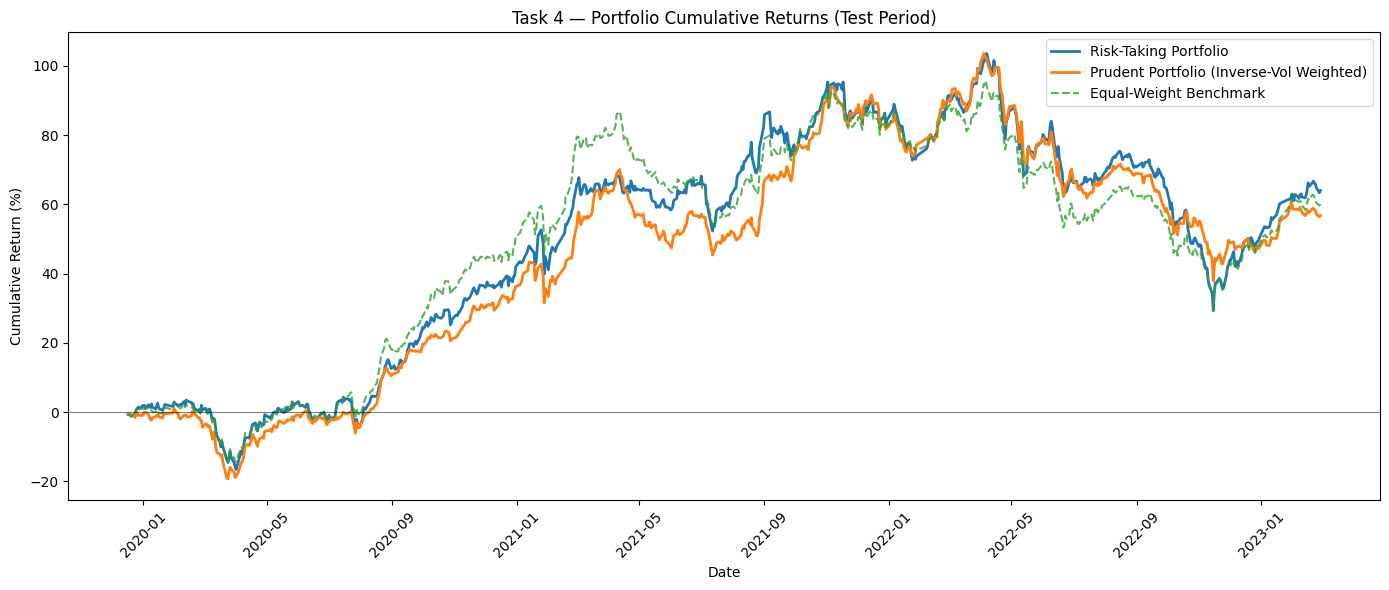

In [196]:
# Call the backtesting to see the performance and its cumulative returns
task4_test_start = None
for ticker, data in task4_ticker_data_map.items():
    n = len(data)
    test_start_idx = int(n * (TASK4_TRAIN_RATIO + TASK4_VAL_RATIO))
    if test_start_idx < n:
        task4_test_start = data.sort_values("Date")["Date"].iloc[test_start_idx]
        break

print(f"Backtest starts: {task4_test_start}")

# Build an equal-weight benchmark portfolio from all investable stocks
eq_weight_df = task4_stock_score_df[task4_stock_score_df["Risk Flag"] == "Keep"].copy().head(TASK4_PORTFOLIO_SIZE)
eq_weight_df["Weight"] = 1.0 / len(eq_weight_df)

risk_taking_bt = task4_backtest_portfolio(task4_risk_taking_portfolio, task4_ticker_data_map, task4_test_start)
prudent_bt     = task4_backtest_portfolio(task4_prudent_portfolio,     task4_ticker_data_map, task4_test_start)
benchmark_bt   = task4_backtest_portfolio(eq_weight_df,                task4_ticker_data_map, task4_test_start)

perf_summary = pd.DataFrame([
    task4_portfolio_performance_summary(risk_taking_bt, "Risk-Taking"),
    task4_portfolio_performance_summary(prudent_bt,     "Prudent (Inv-Vol)"),
    task4_portfolio_performance_summary(benchmark_bt,   "Equal-Weight Benchmark"),
])

print("Task 4 Backtest Performance Summary:")
display(perf_summary)

task4_plot_portfolio_comparison(
    risk_taking_combined=risk_taking_bt,
    prudent_combined=prudent_bt,
    benchmark_combined=benchmark_bt,
    title="Task 4 — Portfolio Cumulative Returns (Test Period)",
)

In [197]:
# Summary
task4_summary = {
    "Selected Universe Size": len(task4_ticker_data_map),
    "Forecast Horizon Days": TASK4_FORECAST_HORIZON,
    "Top Profitable Stocks": task4_profitable_stocks["Ticker"].tolist(),
    "Excluded Risky Stocks": task4_risky_stocks["Ticker"].head(20).tolist(),
    "Risk Taking Portfolio": task4_risk_taking_portfolio[["Ticker", "Weight"]].to_dict("records"),
    "Prudent Portfolio": task4_prudent_portfolio[["Ticker", "Weight"]].to_dict("records"),
}

print("Task 4 Summary:")
for key, value in task4_summary.items():
    print(f"{key}: {value}")

Task 4 Summary:
Selected Universe Size: 40
Forecast Horizon Days: 20
Top Profitable Stocks: ['LGC', 'CLC', 'DHG', 'DHA', 'TDH', 'HMC', 'VIP', 'DRC', 'PAC', 'SAV', 'DMC', 'BMC', 'PJT', 'FMC', 'BMP']
Excluded Risky Stocks: ['HAS', 'SCD', 'GIL', 'MCP', 'HBC', 'ITA', 'SMC']
Risk Taking Portfolio: [{'Ticker': 'CLC', 'Weight': 0.18613592064574055}, {'Ticker': 'DHG', 'Weight': 0.1389476777546619}, {'Ticker': 'LGC', 'Weight': 0.13096815347683755}, {'Ticker': 'DHA', 'Weight': 0.13096815347683755}, {'Ticker': 'DRC', 'Weight': 0.13096815347683755}, {'Ticker': 'HMC', 'Weight': 0.13096815347683755}, {'Ticker': 'SAV', 'Weight': 0.07584129575923368}, {'Ticker': 'DMC', 'Weight': 0.07520249193301365}]
Prudent Portfolio: [{'Ticker': 'SJD', 'Weight': 0.20373756219985245}, {'Ticker': 'DMC', 'Weight': 0.15716043767811702}, {'Ticker': 'DHG', 'Weight': 0.14025622721002992}, {'Ticker': 'TMS', 'Weight': 0.11257348071467158}, {'Ticker': 'CLC', 'Weight': 0.11009459304836237}, {'Ticker': 'SAV', 'Weight': 0.103592

## Task 5: Model Deployment

In [205]:
# ============================================================
# Task 5: Minimal Deployment, SaaS Prototype, and AI Workflow
# Paste this after Task 4 Summary / Task 4 Backtest.
# ============================================================

from pathlib import Path
import json
import shutil

import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [206]:
# ============================================================
# Task 5.0: Deployment Folder Setup
# ============================================================

try:
    BASE_PROJECT_DIR = PROJECT_DIR
except NameError:
    BASE_PROJECT_DIR = Path.cwd()

DEPLOYMENT_DIR = BASE_PROJECT_DIR / "deployment"
ARTIFACT_DIR = DEPLOYMENT_DIR / "artifacts"
API_DIR = DEPLOYMENT_DIR / "api"
APP_DIR = DEPLOYMENT_DIR / "app"
DOCS_DIR = DEPLOYMENT_DIR / "docs"

for directory in [DEPLOYMENT_DIR, ARTIFACT_DIR, API_DIR, APP_DIR, DOCS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

In [207]:
# ============================================================
# Task 5.1: Artifact Export Helpers
# ============================================================

def save_json(data: dict, file_path: Path) -> None:
    with open(file_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2, default=str)


def reset_artifact_dir(artifact_name: str) -> Path:
    artifact_path = ARTIFACT_DIR / artifact_name

    if artifact_path.exists():
        shutil.rmtree(artifact_path)

    artifact_path.mkdir(parents=True, exist_ok=True)

    return artifact_path


def fit_export_price_scalers(
    train_data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
) -> tuple[MinMaxScaler, MinMaxScaler]:
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    feature_scaler.fit(train_data[feature_columns])
    target_scaler.fit(train_data[[target_column]])

    return feature_scaler, target_scaler


def export_price_model_artifact(
    artifact_name: str,
    task_result: dict,
    train_data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    required_price_columns: list[str],
    date_column: str,
    ticker: str,
    market: str,
    lookback_days: int,
    forecast_horizon: int,
    model_type: str,
) -> Path:
    artifact_path = reset_artifact_dir(artifact_name)

    model = task_result["model"]
    feature_scaler, target_scaler = fit_export_price_scalers(
        train_data=train_data,
        feature_columns=feature_columns,
        target_column=target_column,
    )

    model.save(str(artifact_path / "model.keras"), overwrite=True)
    joblib.dump(feature_scaler, artifact_path / "feature_scaler.pkl")
    joblib.dump(target_scaler, artifact_path / "target_scaler.pkl")

    metadata = {
        "artifact_name": artifact_name,
        "task_type": "price_forecasting",
        "ticker": ticker,
        "market": market,
        "model_type": model_type,
        "date_column": date_column,
        "target_column": target_column,
        "required_price_columns": required_price_columns,
        "feature_columns": feature_columns,
        "lookback_days": int(lookback_days),
        "forecast_horizon": int(forecast_horizon),
        "input_description": (
            "Upload recent historical rows containing the required price columns. "
            "The API recomputes Log Return, MA10, MA20, and Volatility10 before prediction."
        ),
    }

    save_json(metadata, artifact_path / "metadata.json")
    print(f"Saved price artifact: {artifact_path}")

    return artifact_path


def export_task4_portfolio_artifact() -> Path:
    artifact_path = reset_artifact_dir("task4_vietnam_portfolio")

    if "task4_model" in globals():
        task4_model.save(str(artifact_path / "task4_return_model.keras"), overwrite=True)

    if "task4_feature_scaler" in globals():
        joblib.dump(task4_feature_scaler, artifact_path / "task4_feature_scaler.pkl")

    if "task4_stock_score_df" in globals():
        task4_stock_score_df.to_csv(artifact_path / "stock_scores.csv", index=False)

    portfolio_candidates = {
        "risk_taking_portfolio.csv": [
            "task4_risk_taking_optimized_portfolio",
            "task4_risk_taking_portfolio",
        ],
        "prudent_portfolio.csv": [
            "task4_prudent_optimized_portfolio",
            "task4_prudent_portfolio",
        ],
    }

    for file_name, variable_names in portfolio_candidates.items():
        for variable_name in variable_names:
            if variable_name in globals():
                globals()[variable_name].to_csv(artifact_path / file_name, index=False)
                break

    if "task4_backtest_metrics" in globals():
        task4_backtest_metrics.to_csv(
            artifact_path / "portfolio_backtest_metrics.csv",
            index=False,
        )

    metadata = {
        "artifact_name": "task4_vietnam_portfolio",
        "task_type": "portfolio_construction",
        "market": "Vietnam",
        "description": (
            "Portfolio output from Task 4. The GRU return model is treated as one part "
            "of a hybrid score with momentum, Sharpe ratio, liquidity, volatility, "
            "downside risk, and drawdown."
        ),
    }

    save_json(metadata, artifact_path / "metadata.json")
    print(f"Saved portfolio artifact: {artifact_path}")

    return artifact_path

In [208]:
# ============================================================
# Task 5.2: Export Minimal Models
# ============================================================

exported_artifacts = []

if "task_1_1_results" in globals():
    exported_artifacts.append(
        export_price_model_artifact(
            artifact_name="task1_nasdaq_next_day",
            task_result=task_1_1_results,
            train_data=nasdaq_train_df,
            feature_columns=FEATURE_COLUMNS,
            target_column=TARGET_COLUMN,
            required_price_columns=REQUIRED_PRICE_COLUMNS,
            date_column=DATE_COLUMN,
            ticker=NASDAQ_TICKER,
            market="Nasdaq",
            lookback_days=LOOKBACK_DAYS,
            forecast_horizon=1,
            model_type=MODEL_TYPE,
        )
    )
else:
    print("Skipped Task 1.1 export: task_1_1_results not found.")

if "task_2_1_results" in globals():
    exported_artifacts.append(
        export_price_model_artifact(
            artifact_name="task2_vietnam_next_day",
            task_result=task_2_1_results,
            train_data=vietnam_train_df,
            feature_columns=VIETNAM_FEATURE_COLUMNS,
            target_column=VIETNAM_TARGET_COLUMN,
            required_price_columns=VIETNAM_REQUIRED_PRICE_COLUMNS,
            date_column=VIETNAM_DATE_COLUMN,
            ticker=VIETNAM_TICKER,
            market="Vietnam",
            lookback_days=VIETNAM_LOOKBACK_DAYS,
            forecast_horizon=1,
            model_type=VIETNAM_MODEL_TYPE,
        )
    )
else:
    print("Skipped Task 2.1 export: task_2_1_results not found.")

if "task4_model" in globals() or "task4_stock_score_df" in globals():
    exported_artifacts.append(export_task4_portfolio_artifact())
else:
    print("Skipped Task 4 export: no Task 4 model or portfolio table found.")

print("Exported artifacts:")
for artifact_path in exported_artifacts:
    print("-", artifact_path)

Saved price artifact: /content/drive/MyDrive/Deep Learning Project/deployment/artifacts/task1_nasdaq_next_day
Saved price artifact: /content/drive/MyDrive/Deep Learning Project/deployment/artifacts/task2_vietnam_next_day
Saved portfolio artifact: /content/drive/MyDrive/Deep Learning Project/deployment/artifacts/task4_vietnam_portfolio
Exported artifacts:
- /content/drive/MyDrive/Deep Learning Project/deployment/artifacts/task1_nasdaq_next_day
- /content/drive/MyDrive/Deep Learning Project/deployment/artifacts/task2_vietnam_next_day
- /content/drive/MyDrive/Deep Learning Project/deployment/artifacts/task4_vietnam_portfolio


In [209]:
# ============================================================
# Task 5.3: FastAPI REST API
# ============================================================

api_code = r'''
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from tensorflow import keras


BASE_DIR = Path(__file__).resolve().parent
ARTIFACT_DIR = BASE_DIR / "artifacts"

app = FastAPI(
    title="Stock Forecasting API",
    description="Minimal API for Task 1/2 price forecasting and Task 4 portfolio output.",
    version="1.0.0",
)


class PredictionRequest(BaseModel):
    artifact_name: str
    records: list[dict]


def get_artifact_path(artifact_name: str) -> Path:
    artifact_path = ARTIFACT_DIR / artifact_name

    if not artifact_path.exists():
        available_artifacts = [
            path.name for path in ARTIFACT_DIR.iterdir() if path.is_dir()
        ] if ARTIFACT_DIR.exists() else []

        raise HTTPException(
            status_code=404,
            detail={
                "message": f"Artifact not found: {artifact_name}",
                "available_artifacts": available_artifacts,
            },
        )

    return artifact_path


def load_metadata(artifact_path: Path) -> dict:
    with open(artifact_path / "metadata.json", "r", encoding="utf-8") as file:
        return json.load(file)


def prepare_price_features_for_api(data: pd.DataFrame, metadata: dict) -> pd.DataFrame:
    date_column = metadata["date_column"]
    target_column = metadata["target_column"]
    required_price_columns = metadata["required_price_columns"]
    feature_columns = metadata["feature_columns"]

    required_columns = [date_column] + required_price_columns
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise HTTPException(
            status_code=400,
            detail=f"Missing required columns: {missing_columns}",
        )

    model_data = data.copy()
    model_data[date_column] = pd.to_datetime(model_data[date_column], errors="coerce")

    for column in required_price_columns:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

    model_data = model_data.dropna(subset=required_columns)
    model_data = model_data.sort_values(date_column).reset_index(drop=True)

    model_data["Log Return"] = np.log(
        model_data[target_column] / model_data[target_column].shift(1)
    )
    model_data["MA10"] = model_data[target_column].rolling(window=10).mean()
    model_data["MA20"] = model_data[target_column].rolling(window=20).mean()
    model_data["Volatility10"] = model_data["Log Return"].rolling(window=10).std()

    model_data = model_data.replace([np.inf, -np.inf], np.nan)
    model_data = model_data.dropna(subset=feature_columns).reset_index(drop=True)

    return model_data


@app.get("/health")
def health():
    return {"status": "ok"}


@app.get("/models")
def list_models():
    if not ARTIFACT_DIR.exists():
        return {"models": []}

    models = []

    for artifact_path in ARTIFACT_DIR.iterdir():
        if artifact_path.is_dir() and (artifact_path / "metadata.json").exists():
            models.append(load_metadata(artifact_path))

    return {"models": models}


@app.post("/predict-price")
def predict_price(request: PredictionRequest):
    artifact_path = get_artifact_path(request.artifact_name)
    metadata = load_metadata(artifact_path)

    if metadata["task_type"] != "price_forecasting":
        raise HTTPException(
            status_code=400,
            detail="Selected artifact is not a price forecasting model.",
        )

    model = keras.models.load_model(artifact_path / "model.keras", compile=False)
    feature_scaler = joblib.load(artifact_path / "feature_scaler.pkl")
    target_scaler = joblib.load(artifact_path / "target_scaler.pkl")

    input_data = pd.DataFrame(request.records)
    model_data = prepare_price_features_for_api(input_data, metadata)

    lookback_days = int(metadata["lookback_days"])
    feature_columns = metadata["feature_columns"]

    if len(model_data) < lookback_days:
        raise HTTPException(
            status_code=400,
            detail=f"Need at least {lookback_days} usable rows after feature engineering.",
        )

    latest_window = model_data.tail(lookback_days)
    x_scaled = feature_scaler.transform(latest_window[feature_columns])
    x_input = x_scaled.reshape(1, lookback_days, len(feature_columns))

    prediction_scaled = model.predict(x_input, verbose=0).reshape(-1)
    prediction = target_scaler.inverse_transform(
        prediction_scaled.reshape(-1, 1)
    ).reshape(-1)

    return {
        "artifact_name": request.artifact_name,
        "ticker": metadata["ticker"],
        "market": metadata["market"],
        "target_column": metadata["target_column"],
        "forecast_horizon": metadata["forecast_horizon"],
        "latest_input_date": str(latest_window[metadata["date_column"]].iloc[-1]),
        "prediction": prediction.tolist(),
    }


@app.get("/portfolio/{artifact_name}")
def get_portfolio(artifact_name: str):
    artifact_path = get_artifact_path(artifact_name)
    metadata = load_metadata(artifact_path)

    if metadata["task_type"] != "portfolio_construction":
        raise HTTPException(
            status_code=400,
            detail="Selected artifact is not a portfolio artifact.",
        )

    result = {"metadata": metadata}

    for file_name in [
        "stock_scores.csv",
        "risk_taking_portfolio.csv",
        "prudent_portfolio.csv",
        "portfolio_backtest_metrics.csv",
    ]:
        file_path = artifact_path / file_name

        if file_path.exists():
            result[file_name] = pd.read_csv(file_path).to_dict(orient="records")

    return result
'''

api_path = API_DIR / "api_app.py"
api_path.write_text(api_code, encoding="utf-8")

api_artifact_dir = API_DIR / "artifacts"

if api_artifact_dir.exists():
    shutil.rmtree(api_artifact_dir)

shutil.copytree(ARTIFACT_DIR, api_artifact_dir)

print(f"Generated API file: {api_path}")

Generated API file: /content/drive/MyDrive/Deep Learning Project/deployment/api/api_app.py


In [210]:
# ============================================================
# Task 5.4: Streamlit SaaS Prototype
# ============================================================

streamlit_code = r'''
import pandas as pd
import requests
import streamlit as st


API_URL = "http://localhost:8000"

st.set_page_config(
    page_title="Stock Forecasting SaaS",
    layout="wide",
)

st.title("Stock Forecasting SaaS Prototype")

st.write(
    "Minimal SaaS prototype for stock price prediction and Vietnam portfolio output."
)

try:
    response = requests.get(f"{API_URL}/models", timeout=5)
    models = response.json().get("models", [])
except Exception:
    models = []

if not models:
    st.warning("No API models found. Start FastAPI first.")
    st.stop()

model_names = [model["artifact_name"] for model in models]
selected_artifact = st.selectbox("Select artifact", model_names)

selected_metadata = next(
    model for model in models if model["artifact_name"] == selected_artifact
)

st.subheader("Artifact Metadata")
st.json(selected_metadata)

if selected_metadata["task_type"] == "price_forecasting":
    uploaded_file = st.file_uploader(
        "Upload recent stock history CSV",
        type=["csv"],
    )

    if uploaded_file is not None:
        input_df = pd.read_csv(uploaded_file)

        st.subheader("Input Preview")
        st.dataframe(input_df.tail(30))

        if st.button("Predict Price"):
            payload = {
                "artifact_name": selected_artifact,
                "records": input_df.to_dict(orient="records"),
            }

            result = requests.post(
                f"{API_URL}/predict-price",
                json=payload,
                timeout=30,
            )

            if result.status_code == 200:
                st.success("Prediction completed.")
                st.json(result.json())
            else:
                st.error("Prediction failed.")
                st.json(result.json())

elif selected_metadata["task_type"] == "portfolio_construction":
    if st.button("Load Portfolio Output"):
        result = requests.get(
            f"{API_URL}/portfolio/{selected_artifact}",
            timeout=30,
        )

        if result.status_code == 200:
            portfolio_data = result.json()

            for key, value in portfolio_data.items():
                if key.endswith(".csv"):
                    st.subheader(key)
                    st.dataframe(pd.DataFrame(value))
        else:
            st.error("Portfolio loading failed.")
            st.json(result.json())
'''

streamlit_path = APP_DIR / "streamlit_app.py"
streamlit_path.write_text(streamlit_code, encoding="utf-8")

print(f"Generated Streamlit file: {streamlit_path}")

Generated Streamlit file: /content/drive/MyDrive/Deep Learning Project/deployment/app/streamlit_app.py


In [211]:
# ============================================================
# Task 5.5: Workflow Documentation
# ============================================================

workflow_text = """
# Task 5 AI Engineering Workflow

## Goal

The goal is to deploy the trained stock forecasting and portfolio models in a form that
other users or systems can access.

## 5.1 API Deployment

The trained GRU models are exported as Keras `.keras` files with preprocessing scalers
and metadata. A FastAPI service loads the artifacts and exposes REST endpoints:

- `/health`: check if the API is running
- `/models`: list available artifacts
- `/predict-price`: predict next-day stock price using Task 1.1 or Task 2.1 models
- `/portfolio/{artifact_name}`: return Task 4 portfolio recommendations and backtest metrics

## 5.2 SaaS Interface

A Streamlit app provides a simple web-based interface. Users can select a model artifact,
upload recent historical stock data, call the API, and view the prediction or portfolio output.

## 5.3 Automation Workflow

A realistic production workflow would use:

1. Airbyte to ingest new stock-market data from external sources.
2. SQL or MongoDB to store raw prices, processed features, predictions, and portfolio outputs.
3. dbt or Python feature scripts to compute technical indicators such as moving averages,
   volatility, RSI, MACD, and momentum.
4. Airflow to schedule the pipeline:
   - ingest data
   - validate data
   - transform features
   - run model inference
   - store predictions
   - refresh dashboards
5. FastAPI to serve trained models.
6. Streamlit, Superset, Tableau, or PowerBI to expose predictions and portfolio recommendations.

The notebook itself is not deployed directly. Instead, the notebook exports reusable artifacts
that can be loaded by API and SaaS applications.
"""

workflow_path = DOCS_DIR / "task5_workflow.md"
workflow_path.write_text(workflow_text.strip(), encoding="utf-8")

print(f"Generated workflow documentation: {workflow_path}")

Generated workflow documentation: /content/drive/MyDrive/Deep Learning Project/deployment/docs/task5_workflow.md


In [212]:
# ============================================================
# Task 5.6: Requirements File
# ============================================================

requirements_text = """
numpy
pandas
matplotlib
scikit-learn
tensorflow
keras
joblib
fastapi
uvicorn
streamlit
requests
python-multipart
"""

requirements_path = BASE_PROJECT_DIR / "requirements.txt"
requirements_path.write_text(requirements_text.strip(), encoding="utf-8")

print(f"Generated requirements file: {requirements_path}")

Generated requirements file: /content/drive/MyDrive/Deep Learning Project/requirements.txt


In [213]:
# ============================================================
# Task 5.7: Run Instructions
# ============================================================

print(
    f"""
Task 5 minimal deployment files generated.

Deployment folder:
{DEPLOYMENT_DIR}

Run FastAPI:
cd "{API_DIR}"
uvicorn api_app:app --host 0.0.0.0 --port 8000

Open API docs:
http://localhost:8000/docs

Run Streamlit in another terminal:
cd "{APP_DIR}"
streamlit run streamlit_app.py
"""
)


Task 5 minimal deployment files generated.

Deployment folder:
/content/drive/MyDrive/Deep Learning Project/deployment

Run FastAPI:
cd "/content/drive/MyDrive/Deep Learning Project/deployment/api"
uvicorn api_app:app --host 0.0.0.0 --port 8000

Open API docs:
http://localhost:8000/docs

Run Streamlit in another terminal:
cd "/content/drive/MyDrive/Deep Learning Project/deployment/app"
streamlit run streamlit_app.py

